In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
from matplotlib.pyplot import xticks
sns.set()
plt.style.use("classic")
from tqdm import tqdm

In [2]:
df=pd.read_csv("CouponAccept.csv")

In [3]:
df.head(15)

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?)
0,No Urgent Place,Alone,Sunny,55,Restaurant(<20),1d,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,Carry out & Take away,2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,Coffee House,1d,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,0
5,No Urgent Place,Friend(s),Sunny,80,Restaurant(<20),2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,1
6,No Urgent Place,Friend(s),Sunny,55,Carry out & Take away,1d,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,1
7,No Urgent Place,Kid(s),Sunny,80,Restaurant(<20),2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,1
8,No Urgent Place,Kid(s),Sunny,80,Carry out & Take away,2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,1
9,No Urgent Place,Kid(s),Sunny,80,Bar,1d,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   coupon                12684 non-null  object
 5   expiration            12684 non-null  object
 6   gender                12684 non-null  object
 7   age                   12684 non-null  object
 8   maritalStatus         12684 non-null  object
 9   has_children          12684 non-null  int64 
 10  education             12684 non-null  object
 11  occupation            12684 non-null  object
 12  income                12684 non-null  object
 13  car                   108 non-null    object
 14  Bar                   12577 non-null  object
 15  CoffeeHouse           12467 non-null

In [5]:
obj=(df.dtypes =='object')
object_cols=list(obj[obj].index)
print("categorical variables:",len(object_cols))
int_1=(df.dtypes=='int64')
num_cols=list(int_1[int_1].index)
print("Integer varibales:",len(num_cols))

categorical variables: 17
Integer varibales: 8


<function matplotlib.pyplot.show(close=None, block=None)>

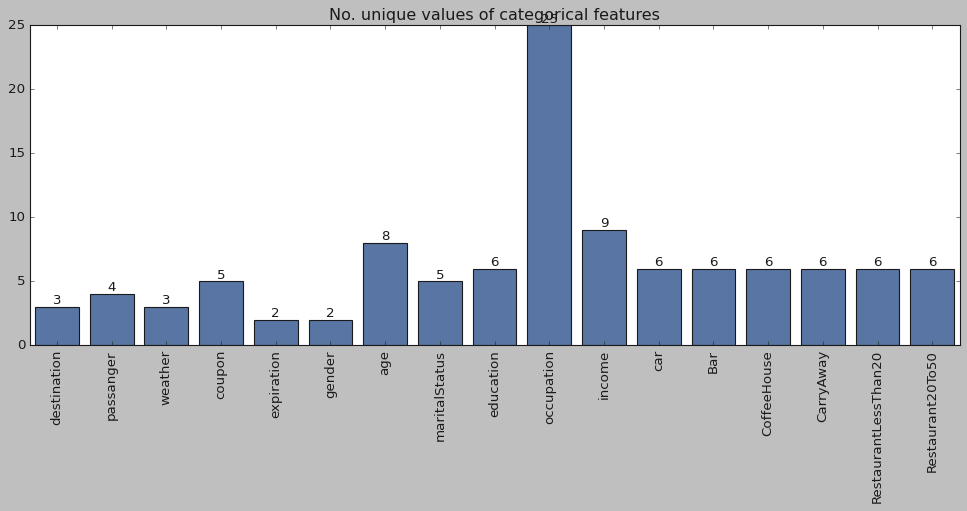

In [6]:
unique_values=[]
for col in object_cols:
    unique_values.append(df[col].unique().size)
plt.figure(figsize=(15,5))
plt.title("No. unique values of categorical features")
plt.xticks(rotation=90)
ax=sns.barplot(x=object_cols, y = unique_values)
ax.bar_label(ax.containers[0])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

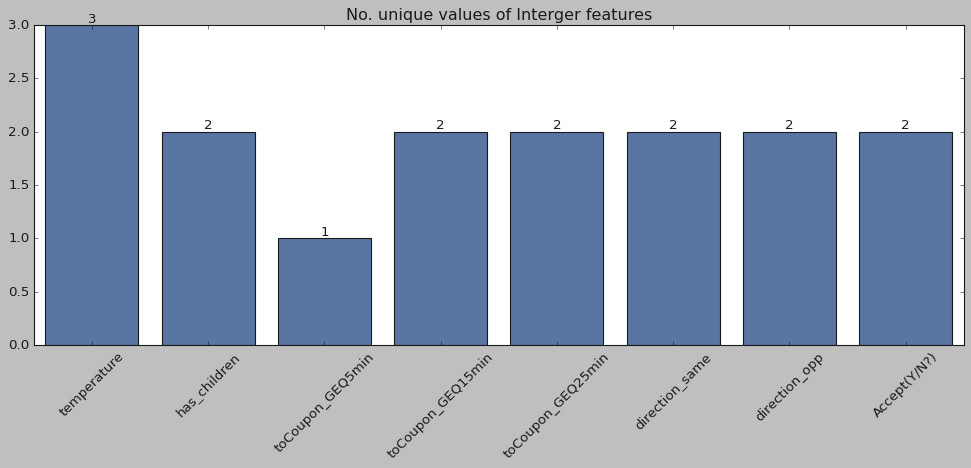

In [7]:
unique_values=[]
for col in num_cols:
    unique_values.append(df[col].unique().size)
plt.figure(figsize=(15,5))
plt.title("No. unique values of Interger features")
plt.xticks(rotation=45)
ax=sns.barplot(x=num_cols, y = unique_values)
ax.bar_label(ax.containers[0])
plt.show

In [8]:
df1=(df.isnull().sum()/len(df))*100
df1.sort_values(ascending=False)

car                     99.148534
CoffeeHouse              1.710817
Restaurant20To50         1.490066
CarryAway                1.190476
RestaurantLessThan20     1.024913
Bar                      0.843582
weather                  0.000000
passanger                0.000000
destination              0.000000
maritalStatus            0.000000
age                      0.000000
gender                   0.000000
expiration               0.000000
coupon                   0.000000
temperature              0.000000
income                   0.000000
occupation               0.000000
has_children             0.000000
education                0.000000
toCoupon_GEQ5min         0.000000
toCoupon_GEQ15min        0.000000
toCoupon_GEQ25min        0.000000
direction_same           0.000000
direction_opp            0.000000
Accept(Y/N?)             0.000000
dtype: float64

In [9]:
df=df.drop('car',axis=1)

In [10]:
df=df.dropna()

In [11]:
df1=(df.isnull().sum()/len(df))*100
df1.sort_values(ascending=False)

destination             0.0
passanger               0.0
weather                 0.0
temperature             0.0
coupon                  0.0
expiration              0.0
gender                  0.0
age                     0.0
maritalStatus           0.0
has_children            0.0
education               0.0
occupation              0.0
income                  0.0
Bar                     0.0
CoffeeHouse             0.0
CarryAway               0.0
RestaurantLessThan20    0.0
Restaurant20To50        0.0
toCoupon_GEQ5min        0.0
toCoupon_GEQ15min       0.0
toCoupon_GEQ25min       0.0
direction_same          0.0
direction_opp           0.0
Accept(Y/N?)            0.0
dtype: float64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12079 entries, 22 to 12683
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12079 non-null  object
 1   passanger             12079 non-null  object
 2   weather               12079 non-null  object
 3   temperature           12079 non-null  int64 
 4   coupon                12079 non-null  object
 5   expiration            12079 non-null  object
 6   gender                12079 non-null  object
 7   age                   12079 non-null  object
 8   maritalStatus         12079 non-null  object
 9   has_children          12079 non-null  int64 
 10  education             12079 non-null  object
 11  occupation            12079 non-null  object
 12  income                12079 non-null  object
 13  Bar                   12079 non-null  object
 14  CoffeeHouse           12079 non-null  object
 15  CarryAway             12079 non-null  ob

In [13]:
for i in df.select_dtypes("O").columns:
    print("################### \n")
    print(df[i].value_counts())
    print("\n")

################### 

destination
No Urgent Place    5970
Home               3085
Work               3024
Name: count, dtype: int64


################### 

passanger
Alone        6969
Friend(s)    3148
Partner      1024
Kid(s)        938
Name: count, dtype: int64


################### 

weather
Sunny    9601
Snowy    1331
Rainy    1147
Name: count, dtype: int64


################### 

coupon
Coffee House             3816
Restaurant(<20)          2653
Carry out & Take away    2280
Bar                      1913
Restaurant(20-50)        1417
Name: count, dtype: int64


################### 

expiration
1d    6760
2h    5319
Name: count, dtype: int64


################### 

gender
Female    6199
Male      5880
Name: count, dtype: int64


################### 

age
21         2537
26         2399
31         1925
50plus     1732
36         1253
41         1065
46          664
below21     504
Name: count, dtype: int64


################### 

maritalStatus
Married partner      4831
Single       

<Figure size 1280x480 with 0 Axes>

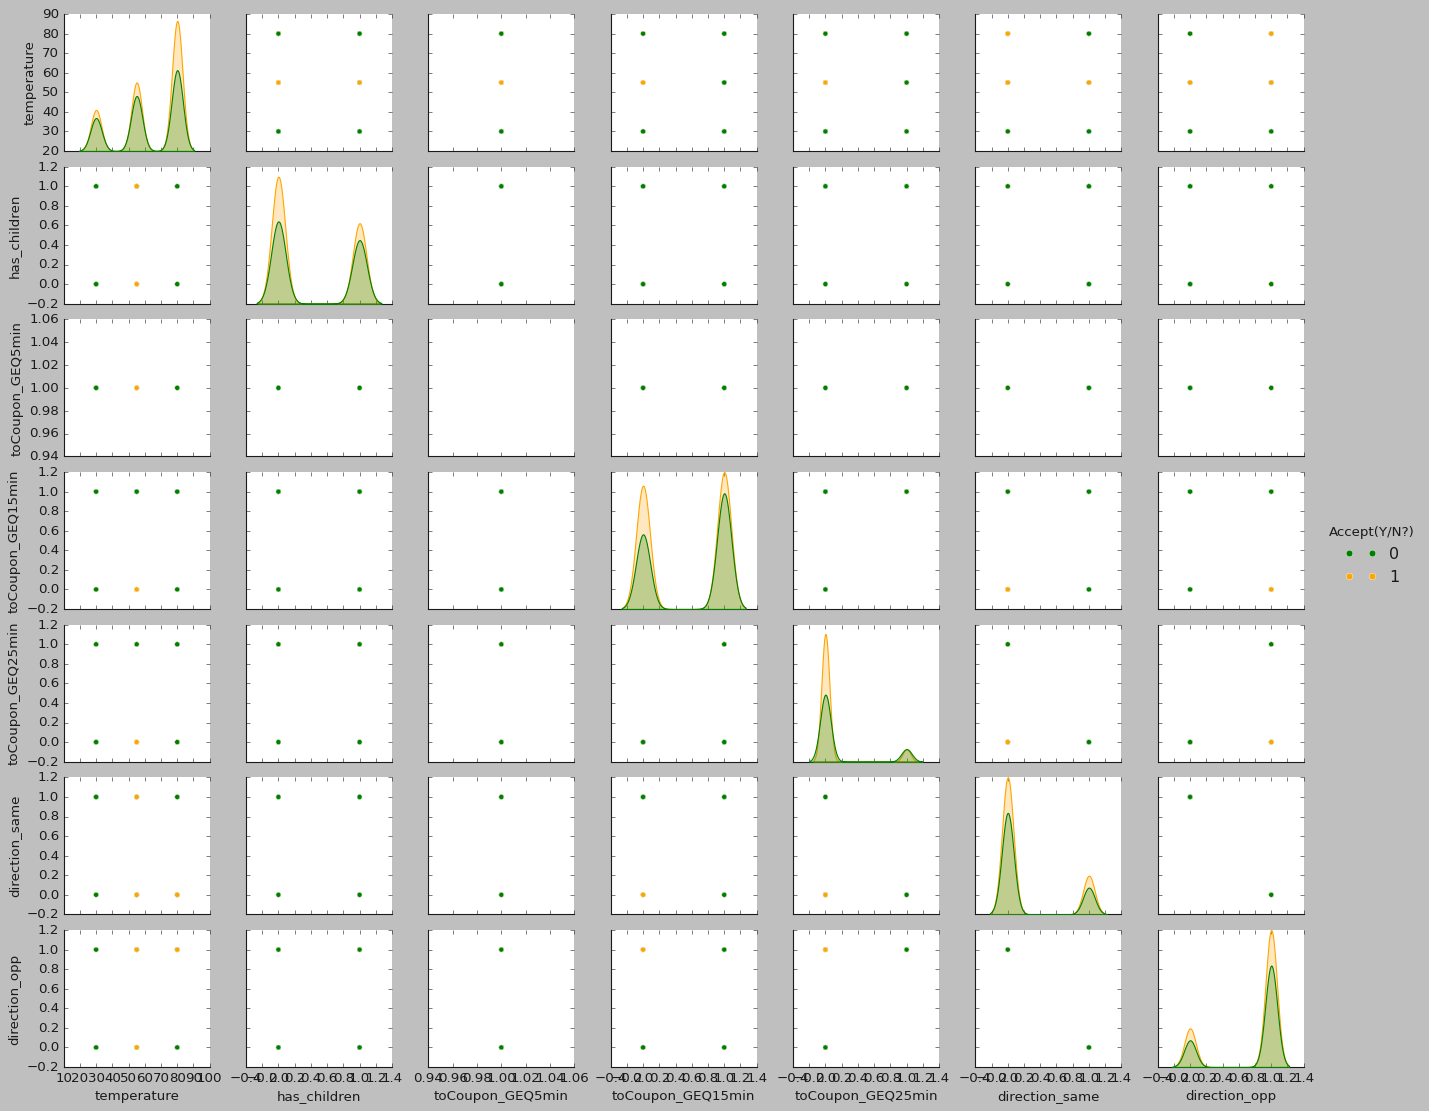

In [14]:
plt.figure(figsize=(16,6))
sns.set_palette(sns.color_palette(["green","orange"]))
sns.pairplot(df,hue='Accept(Y/N?)')
fig=plt.gcf()
fig.set_size_inches(18,14)
#plt.show()

In [15]:
df.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min',
       'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same',
       'direction_opp', 'Accept(Y/N?)'],
      dtype='object')

In [16]:
df.expiration.replace({'1d':'24h'},inplace=True)

In [17]:
df.expiration.value_counts()

expiration
24h    6760
2h     5319
Name: count, dtype: int64

In [18]:
df.Bar.value_counts()

Bar
never    4934
less1    3394
1~3      2370
4~8      1054
gt8       327
Name: count, dtype: int64

In [19]:
df.Bar.replace({"1~3" : "1 to 3"}, inplace=True)
df.Bar.replace({"4~8" : "4 to 8"}, inplace= True)
df.Bar.replace({"gt8" : "greater then 8"}, inplace= True)
df.Restaurant20To50.replace({"1~3" : "1 to 3"}, inplace=True)
df.Restaurant20To50.replace({"4~8" : "4 to 8"}, inplace= True)
df.Restaurant20To50.replace({"gt8" : "greater then 8"}, inplace= True)
df.RestaurantLessThan20.replace({"1~3" : "1 to 3"}, inplace=True)
df.RestaurantLessThan20.replace({"4~8" : "4 to 8"}, inplace= True)
df.RestaurantLessThan20.replace({"gt8" : "greater then 8"}, inplace= True)
df.CoffeeHouse.replace({"1~3" : "1 to 3"}, inplace=True)
df.CoffeeHouse.replace({"4~8" : "4 to 8"}, inplace= True)
df.CoffeeHouse.replace({"gt8" : "greater then 8"}, inplace= True)
df.CarryAway.replace({"1~3" : "1 to 3"}, inplace=True)
df.CarryAway.replace({"4~8" : "4 to 8"}, inplace= True)
df.CarryAway.replace({"gt8" : "greater then 8"}, inplace= True)

In [20]:
df.rename(columns={"Accept(Y/N?)":"Accept"},inplace=True)

In [21]:
def univariate_analysis(column_name):
    data_EDA=pd.DataFrame(sorted(list(df[column_name].unique())), columns=[column_name])
    data_EDA["Total_count"]= list(df.groupby(column_name).Accept.count())
    data_EDA["Accepted"] = list(df[df["Accept"]==1].groupby(column_name).Accept.count())
    data_EDA["Rejected"] = list(df[df["Accept"]==0].groupby(column_name).Accept.count())
    data_EDA["% of Accepted"] = round(data_EDA["Accepted"]/data_EDA["Total_count"]*100)
    data_EDA["% of Rejected"] = round(data_EDA["Rejected"]/data_EDA["Total_count"]*100)
    data_EDA=data_EDA.sort_values(by= '% of Accepted', ascending= False)
    return data_EDA

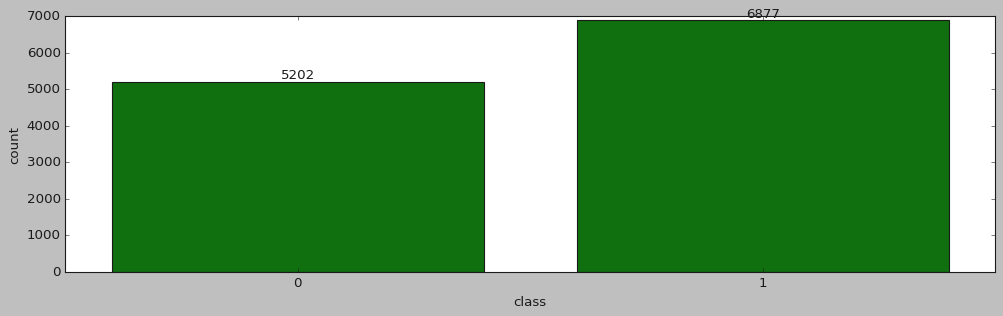

In [22]:
plt.figure(figsize=(15,4))
class_data = df["Accept"].value_counts().reset_index()
class_data.columns = ["class", "count"]
xticks(rotation=0)
ax = sns.barplot(x="class", y="count", data=class_data)
ax.bar_label(ax.containers[0])
plt.show()

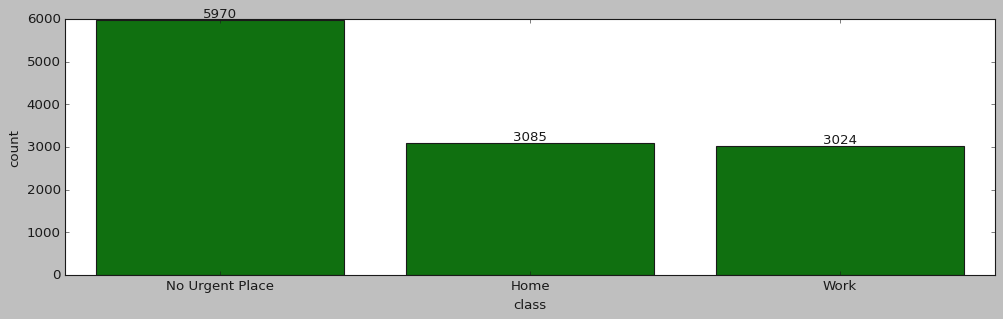

In [23]:
plt.figure(figsize=(15,4))
class_data = df["destination"].value_counts().reset_index()
class_data.columns = ["class", "count"]
xticks(rotation=0)
ax = sns.barplot(x="class", y="count", data=class_data)
ax.bar_label(ax.containers[0])
plt.show()

In [24]:
univariate_analysis('destination')

,destination,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
1,No Urgent Place,5970,3785,2185,63.0,37.0
0,Home,3085,1568,1517,51.0,49.0
2,Work,3024,1524,1500,50.0,50.0


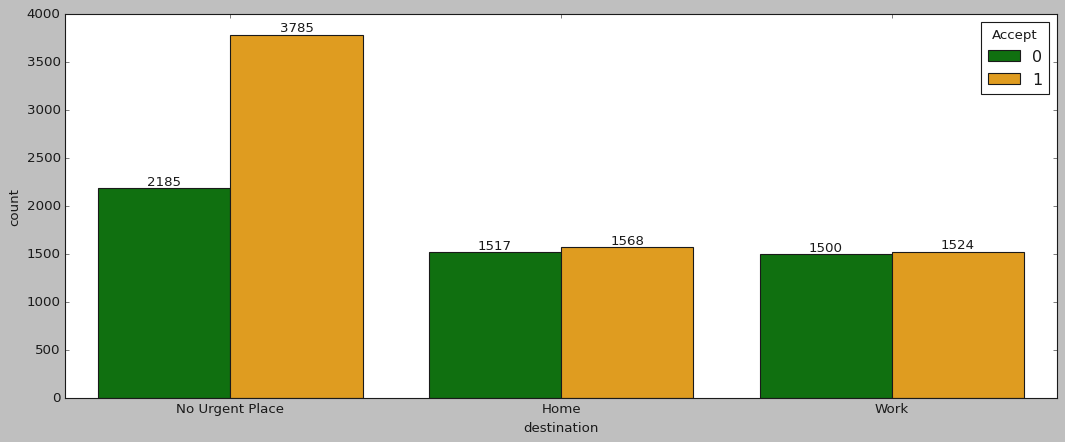

In [25]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x="destination", hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

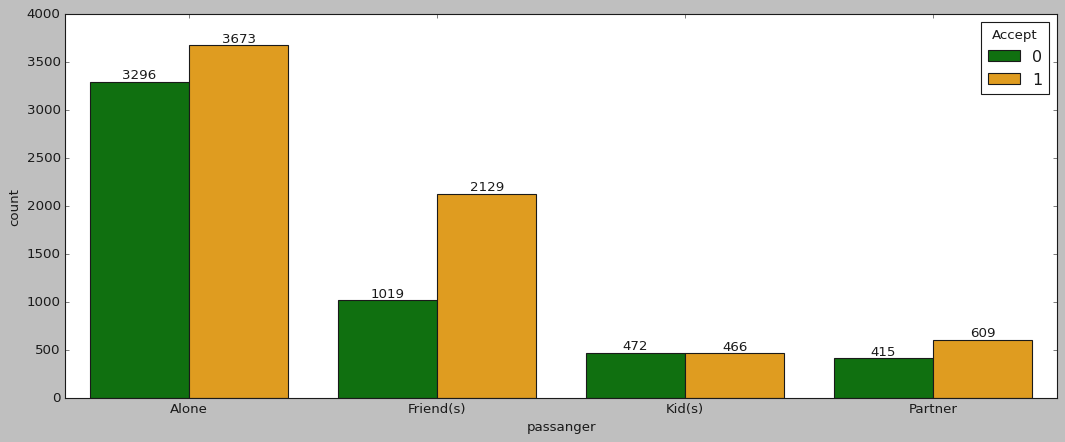

In [26]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x="passanger", hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

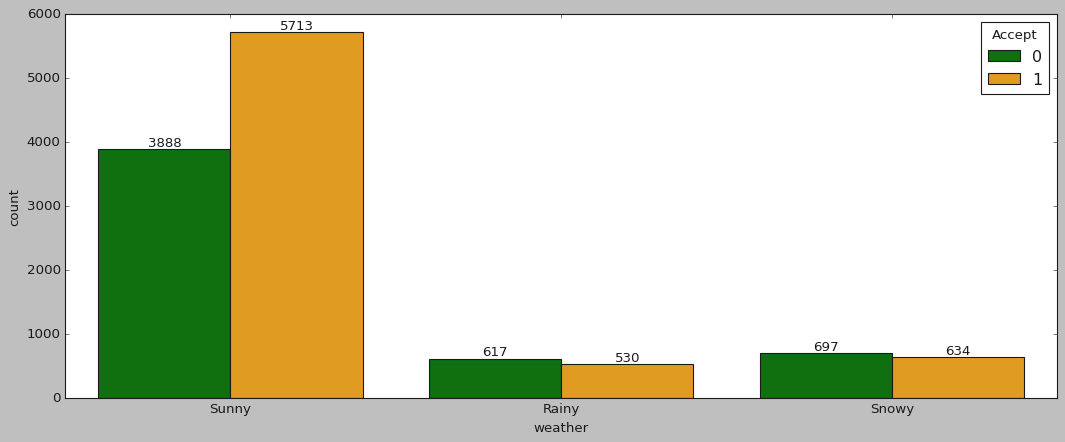

In [27]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x="weather", hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

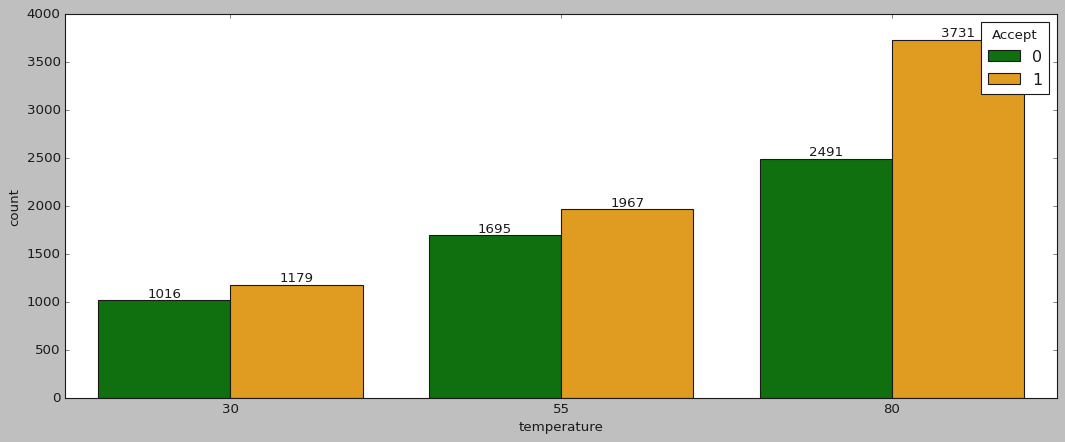

In [28]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x="temperature", hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [29]:
univariate_analysis('coupon')

,coupon,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
1,Carry out & Take away,2280,1682,598,74.0,26.0
4,Restaurant(<20),2653,1881,772,71.0,29.0
2,Coffee House,3816,1894,1922,50.0,50.0
3,Restaurant(20-50),1417,632,785,45.0,55.0
0,Bar,1913,788,1125,41.0,59.0


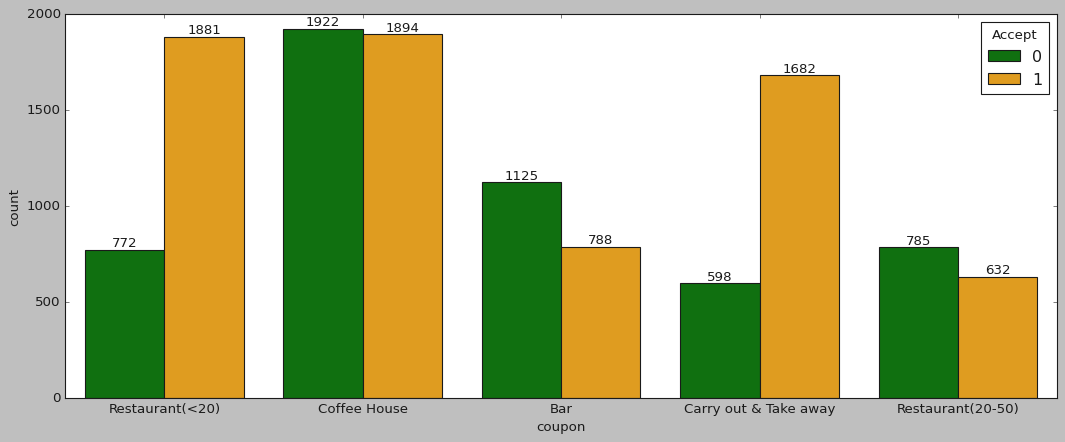

In [30]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x="coupon", hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [31]:
univariate_analysis('expiration')

,expiration,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
0,24h,6760,4244,2516,63.0,37.0
1,2h,5319,2633,2686,50.0,50.0


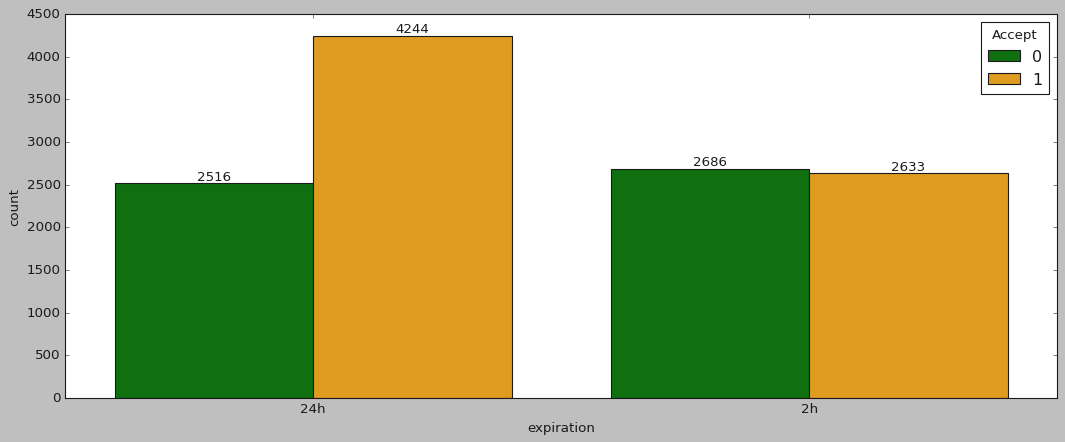

In [32]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x="expiration", hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [33]:
univariate_analysis('gender')

,gender,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
1,Male,5880,3483,2397,59.0,41.0
0,Female,6199,3394,2805,55.0,45.0


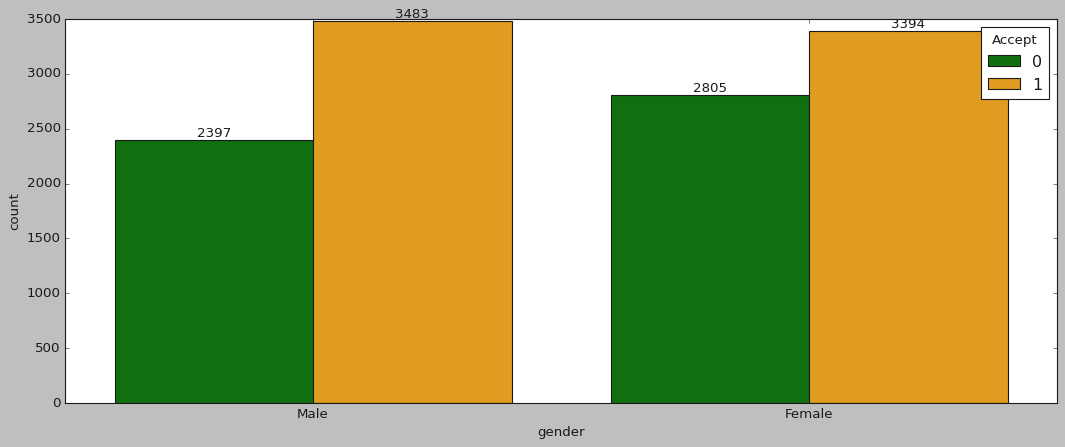

In [34]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x="gender", hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [35]:
univariate_analysis('age')

,age,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
7,below21,504,319,185,63.0,37.0
1,26,2399,1439,960,60.0,40.0
0,21,2537,1507,1030,59.0,41.0
5,46,664,383,281,58.0,42.0
4,41,1065,612,453,57.0,43.0
2,31,1925,1063,862,55.0,45.0
3,36,1253,675,578,54.0,46.0
6,50plus,1732,879,853,51.0,49.0


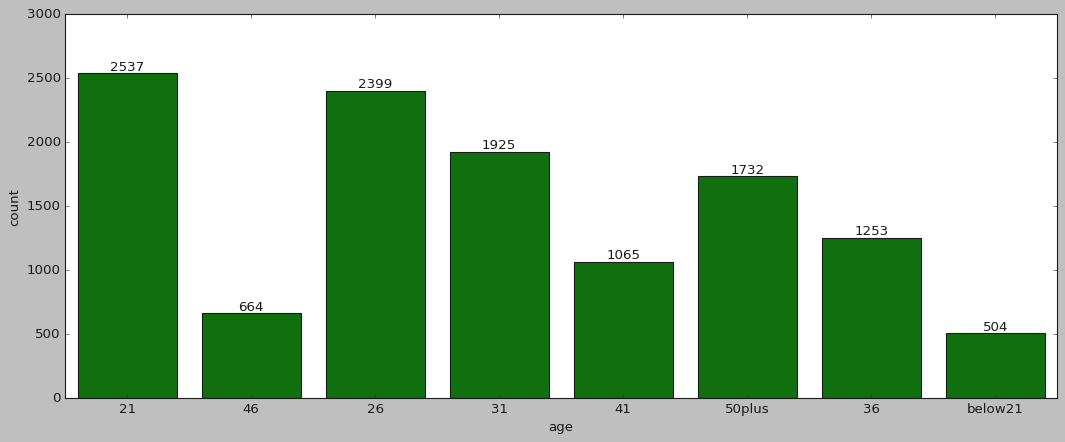

In [36]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x="age", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

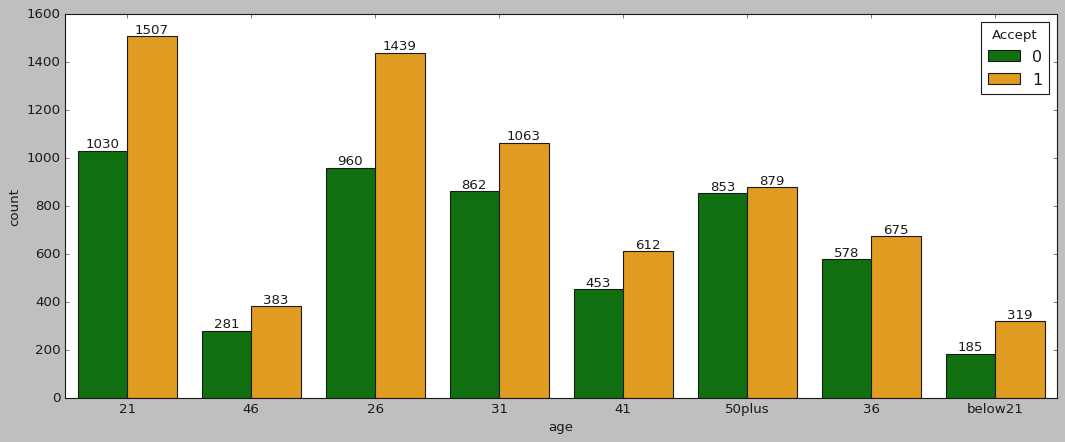

In [37]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x="age", hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [38]:
univariate_analysis('maritalStatus')

,maritalStatus,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
2,Single,4588,2800,1788,61.0,39.0
3,Unmarried partner,2048,1138,910,56.0,44.0
1,Married partner,4831,2623,2208,54.0,46.0
0,Divorced,504,265,239,53.0,47.0
4,Widowed,108,51,57,47.0,53.0


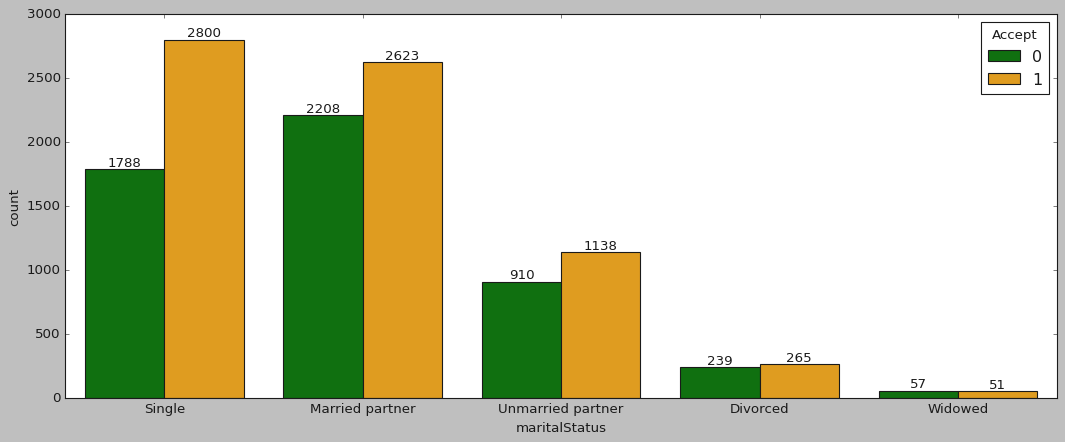

In [39]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x="maritalStatus", hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [40]:
univariate_analysis("has_children")

,has_children,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
0,0,7145,4210,2935,59.0,41.0
1,1,4934,2667,2267,54.0,46.0


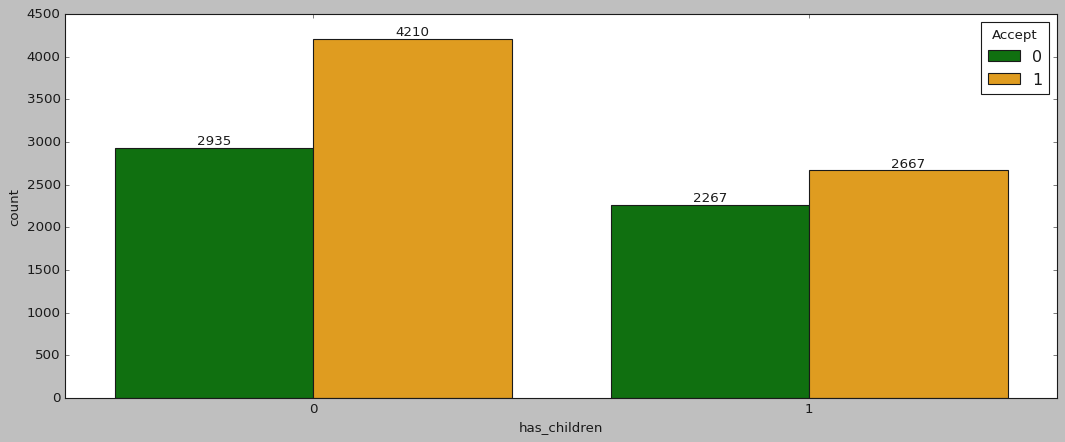

In [41]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x="has_children", hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [42]:
univariate_analysis('education')

,education,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
4,Some High School,88,63,25,72.0,28.0
3,High School Graduate,877,521,356,59.0,41.0
5,Some college - no degree,4219,2508,1711,59.0,41.0
0,Associates degree,1066,596,470,56.0,44.0
1,Bachelors degree,4021,2237,1784,56.0,44.0
2,Graduate degree (Masters or Doctorate),1808,952,856,53.0,47.0


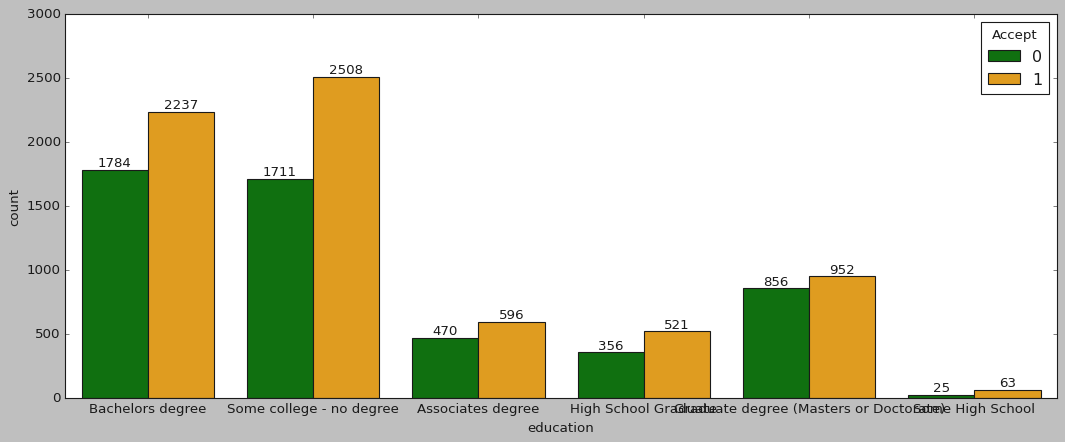

In [43]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x="education", hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [44]:
univariate_analysis('occupation')

,occupation,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
10,Healthcare Practitioners & Technical,222,159,63,72.0,28.0
11,Healthcare Support,242,169,73,70.0,30.0
18,Production Occupations,88,62,26,70.0,30.0
6,Construction & Extraction,154,106,48,69.0,31.0
19,Protective Service,175,113,62,65.0,35.0
0,Architecture & Engineering,175,111,64,63.0,37.0
22,Student,1497,911,586,61.0,39.0
23,Transportation & Material Moving,218,130,88,60.0,40.0
16,Office & Administrative Support,617,372,245,60.0,40.0
2,Building & Grounds Cleaning & Maintenance,44,26,18,59.0,41.0


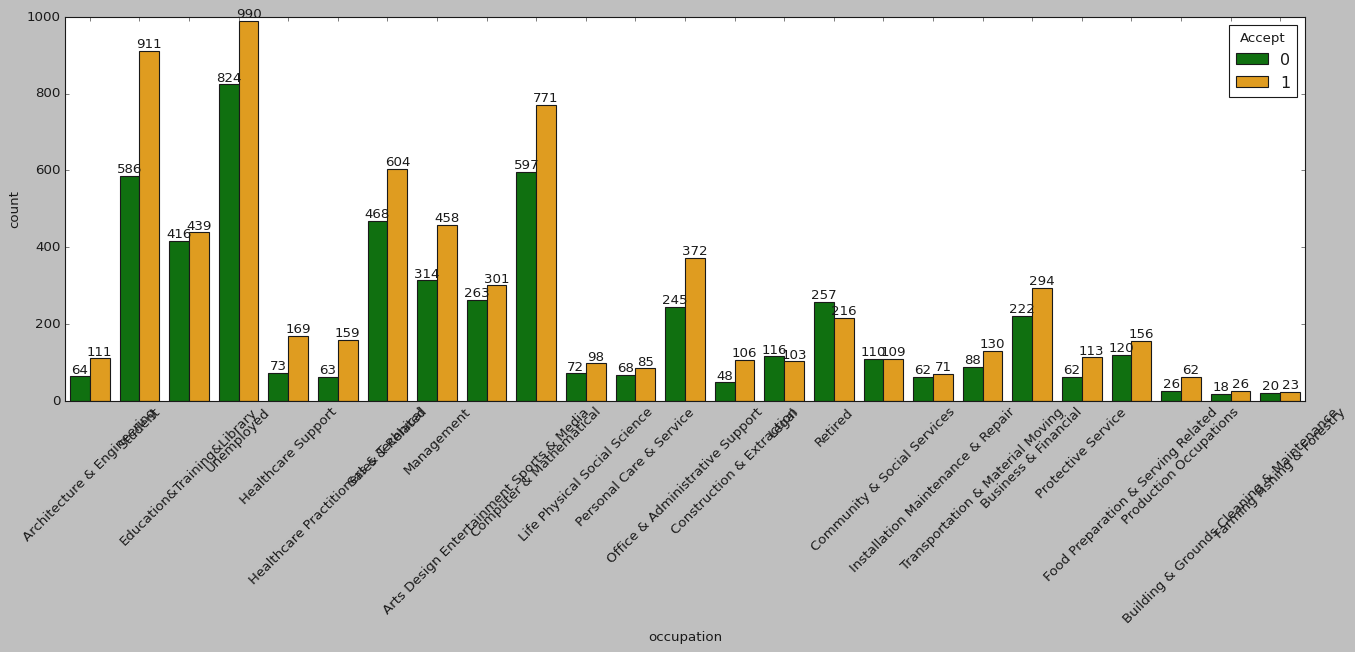

In [45]:
plt.figure(figsize=(20,6))
ax = sns.countplot(x="occupation", hue="Accept", data=df)
xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [46]:
univariate_analysis('income')

,income,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
2,$25000 - $37499,1919,1146,773,60.0,40.0
8,Less than $12500,1014,596,418,59.0,41.0
4,$50000 - $62499,1565,923,642,59.0,41.0
0,$100000 or More,1692,978,714,58.0,42.0
1,$12500 - $24999,1728,998,730,58.0,42.0
3,$37500 - $49999,1689,964,725,57.0,43.0
5,$62500 - $74999,840,443,397,53.0,47.0
7,$87500 - $99999,818,428,390,52.0,48.0
6,$75000 - $87499,814,401,413,49.0,51.0


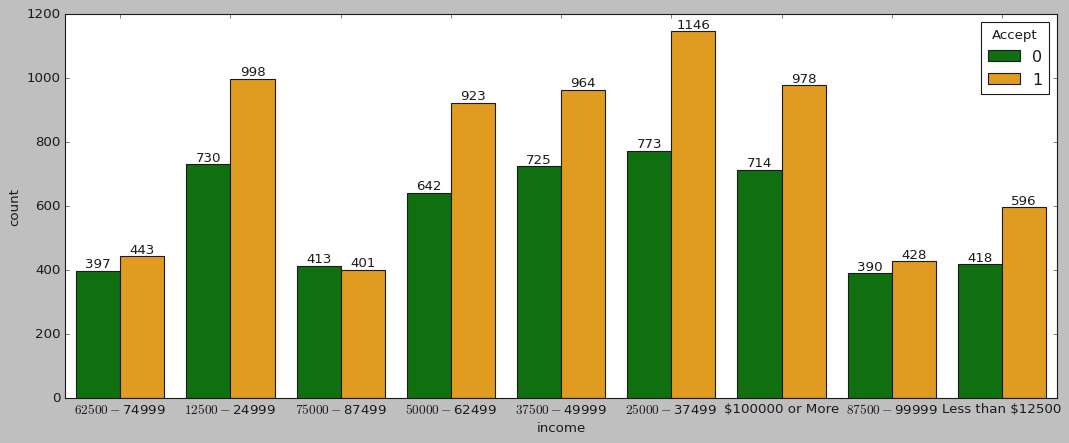

In [47]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x="income", hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [48]:
univariate_analysis('direction_opp')

,direction_opp,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
0,0,2599,1515,1084,58.0,42.0
1,1,9480,5362,4118,57.0,43.0


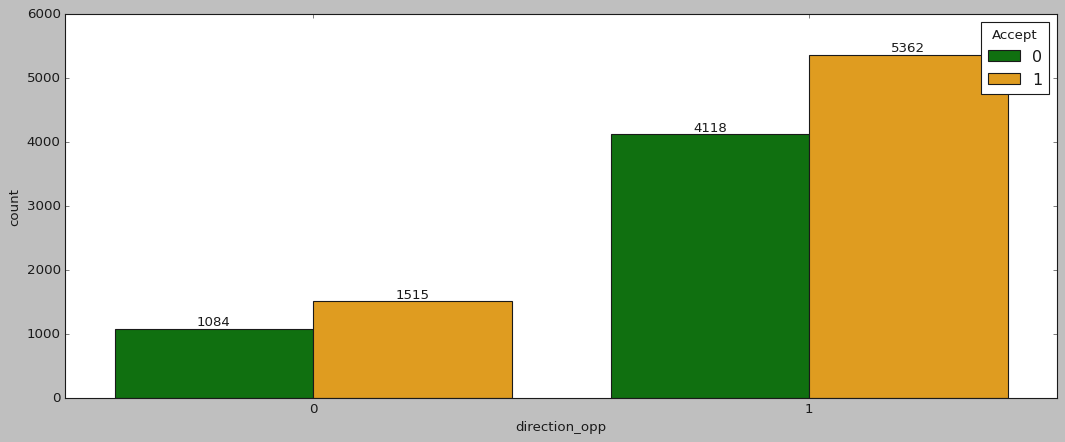

In [49]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x='direction_opp', hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [50]:
univariate_analysis('direction_same')

,direction_same,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
1,1,2599,1515,1084,58.0,42.0
0,0,9480,5362,4118,57.0,43.0


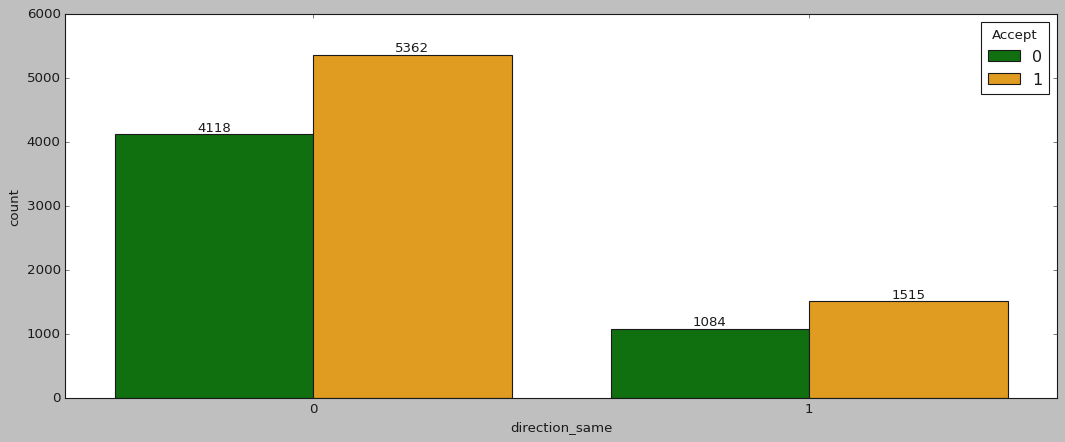

In [51]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x='direction_same', hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [52]:
df.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min',
       'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same',
       'direction_opp', 'Accept'],
      dtype='object')

In [53]:
univariate_analysis('toCoupon_GEQ25min')

,toCoupon_GEQ25min,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
0,0,10637,6251,4386,59.0,41.0
1,1,1442,626,816,43.0,57.0


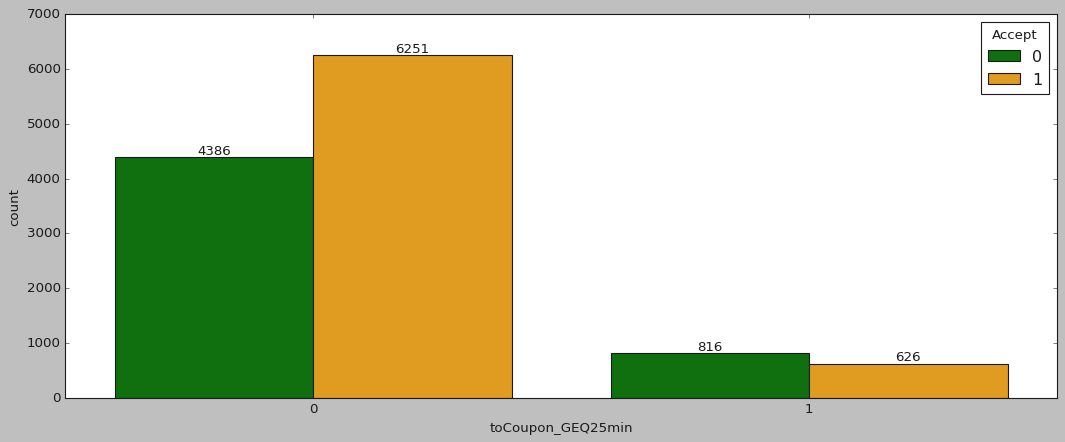

In [54]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x='toCoupon_GEQ25min', hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [55]:
univariate_analysis('toCoupon_GEQ15min')

,toCoupon_GEQ15min,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
0,0,5300,3260,2040,62.0,38.0
1,1,6779,3617,3162,53.0,47.0


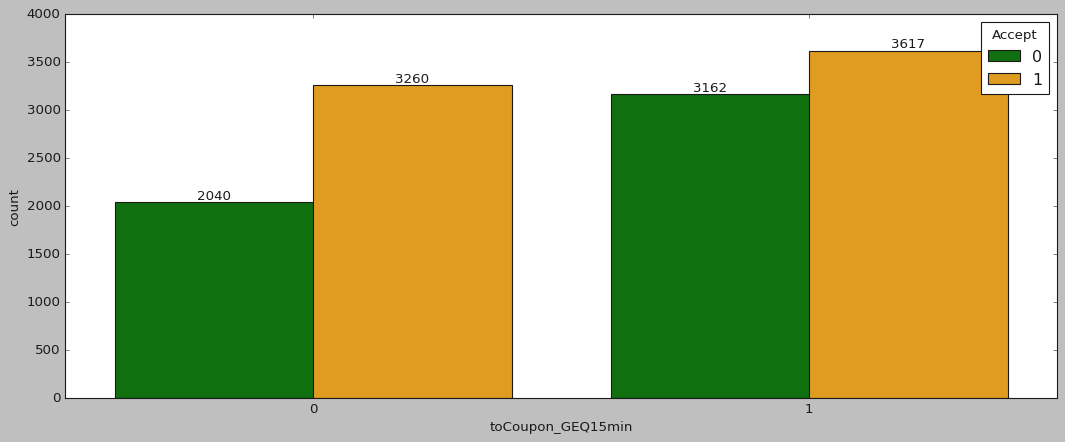

In [56]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x='toCoupon_GEQ15min', hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [57]:
univariate_analysis('toCoupon_GEQ5min')

,toCoupon_GEQ5min,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
0,1,12079,6877,5202,57.0,43.0


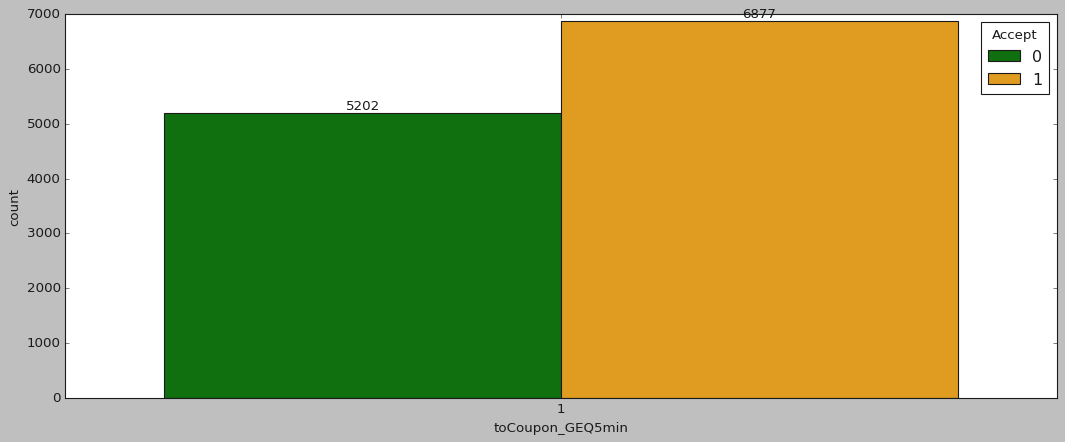

In [58]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x='toCoupon_GEQ5min', hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [59]:
univariate_analysis('Restaurant20To50')

,Restaurant20To50,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
2,greater then 8,264,175,89,66.0,34.0
1,4 to 8,684,447,237,65.0,35.0
0,1 to 3,3202,1913,1289,60.0,40.0
3,less1,5859,3272,2587,56.0,44.0
4,never,2070,1070,1000,52.0,48.0


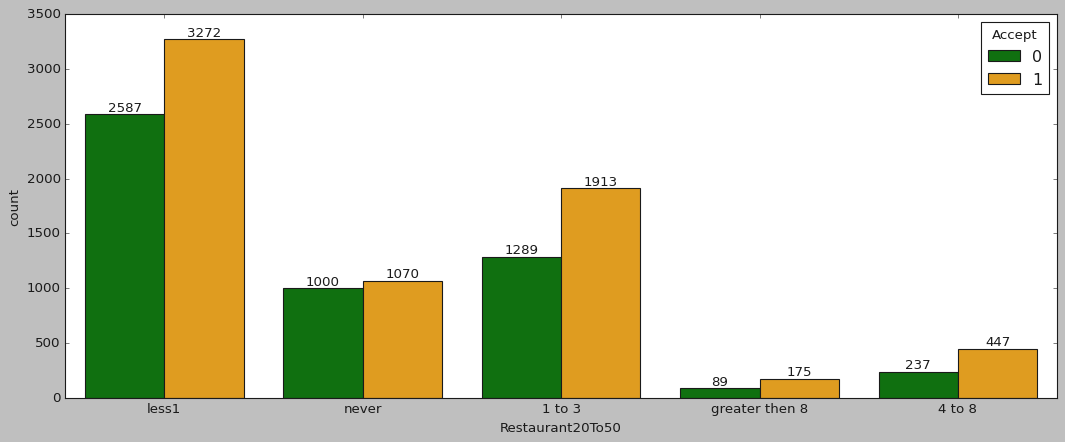

In [60]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x='Restaurant20To50', hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [61]:
univariate_analysis('RestaurantLessThan20')

,RestaurantLessThan20,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
2,greater then 8,1285,781,504,61.0,39.0
4,never,176,103,73,59.0,41.0
1,4 to 8,3450,2012,1438,58.0,42.0
0,1 to 3,5163,2902,2261,56.0,44.0
3,less1,2005,1079,926,54.0,46.0


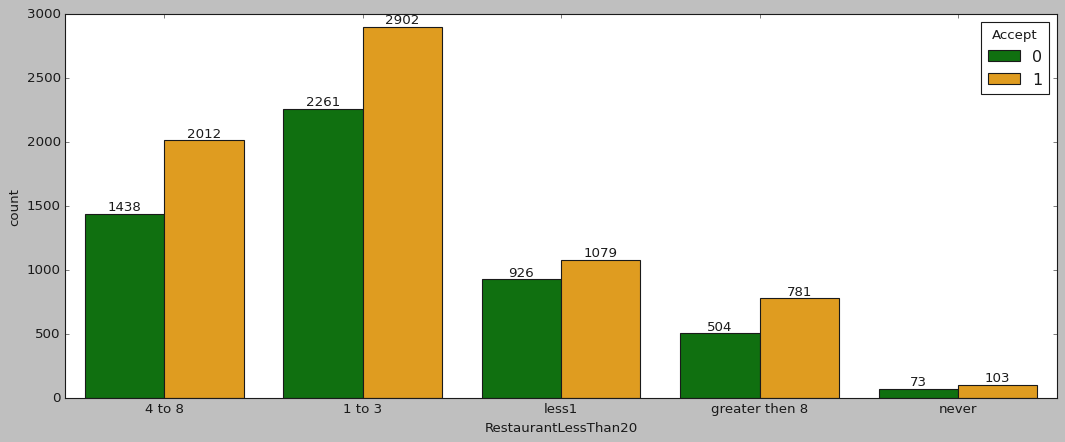

In [62]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x='RestaurantLessThan20', hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [63]:
univariate_analysis('CarryAway')

,CarryAway,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
0,1 to 3,4502,2623,1879,58.0,42.0
1,4 to 8,4083,2370,1713,58.0,42.0
2,greater then 8,1573,913,660,58.0,42.0
4,never,131,72,59,55.0,45.0
3,less1,1790,899,891,50.0,50.0


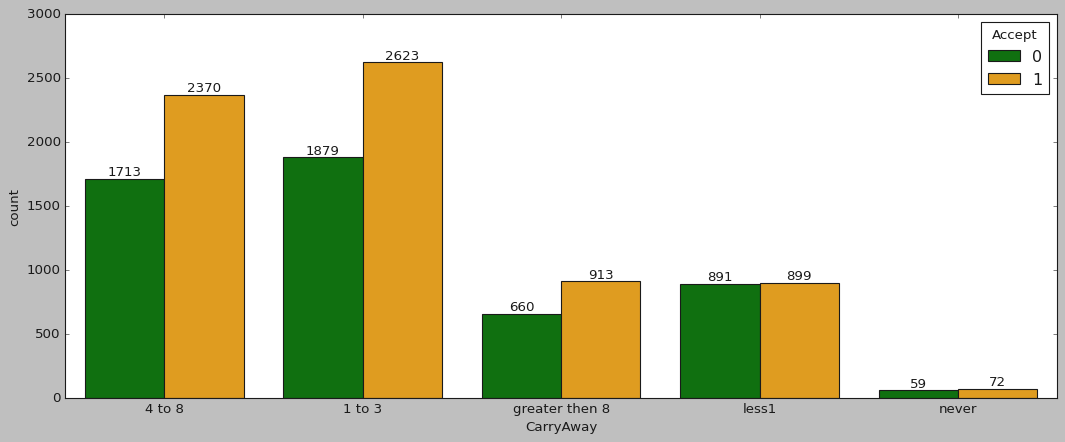

In [64]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x='CarryAway', hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [65]:
univariate_analysis('CoffeeHouse')

,CoffeeHouse,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
0,1 to 3,3159,2060,1099,65.0,35.0
1,4 to 8,1659,1047,612,63.0,37.0
2,greater then 8,1111,648,463,58.0,42.0
3,less1,3298,1824,1474,55.0,45.0
4,never,2852,1298,1554,46.0,54.0


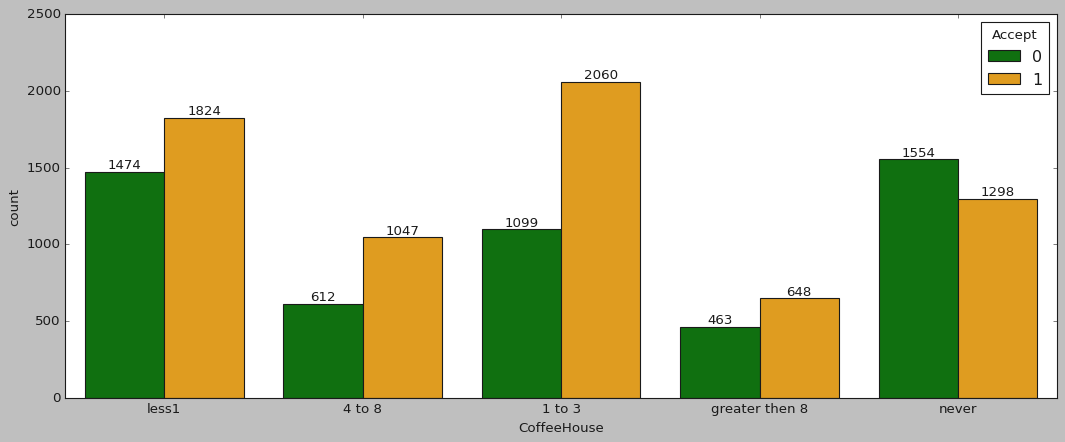

In [66]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x='CoffeeHouse', hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [67]:
univariate_analysis('Bar')

,Bar,Total_count,Accepted,Rejected,% of Accepted,% of Rejected
1,4 to 8,1054,672,382,64.0,36.0
0,1 to 3,2370,1481,889,62.0,38.0
2,greater then 8,327,186,141,57.0,43.0
3,less1,3394,1929,1465,57.0,43.0
4,never,4934,2609,2325,53.0,47.0


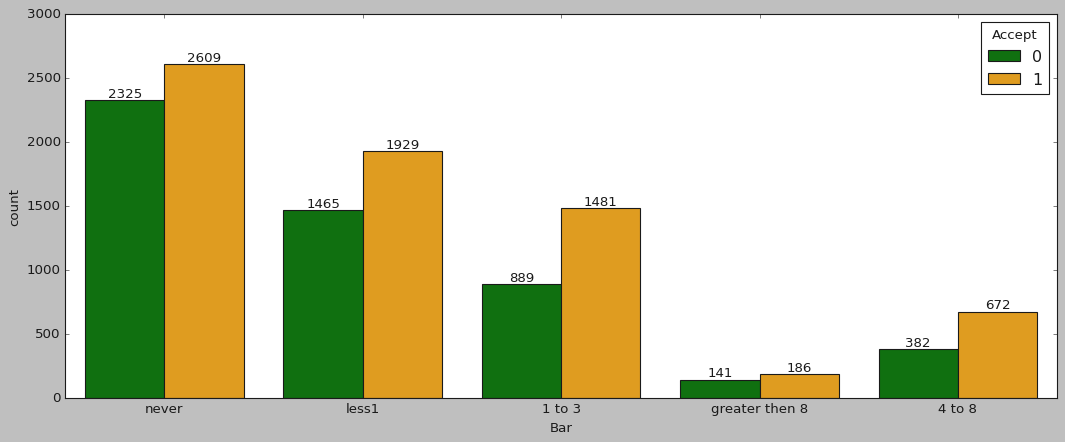

In [68]:
plt.figure(figsize=(16,6))
ax = sns.countplot(x='Bar', hue="Accept", data=df)
xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [69]:
df.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min',
       'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same',
       'direction_opp', 'Accept'],
      dtype='object')

In [70]:
def bivariate_analysis(col1, col2, c1, c2, no_row):
    a = list(df[col1].unique())
    b = list(df[col2].unique())
    data = pd.DataFrame([(i, j) for i in a for j in b], columns=[col1, col2])
    Total_Count = []
    Accepted = []
    Rejected = []
    for i in range(data.shape[0]):
        Total_Count.append(df[(df[col1] == data[col1][i]) & (df[col2] == data[col2][i])].shape[0])
        Accepted.append(df[(df[col1] == data[col1][i]) &(df[col2] == data[col2][i]) &(df.Accept == c1)].shape[0])
        Rejected.append(df[(df[col1] == data[col1][i]) &(df[col2] == data[col2][i]) &(df.Accept == c2)].shape[0])
    data['Total_Count'] = Total_Count
    data['Accepted'] = Accepted
    data['Rejected'] = Rejected
    data['%Accepted'] = round(data['Accepted'] / data['Total_Count'] * 100, 3)
    data['%Rejected'] = round(data['Rejected'] / data['Total_Count'] * 100, 3)

    data = data.dropna()
    data = data.sort_values(by='%Accepted', ascending=False)
    d = pd.concat([data.head(no_row), data.tail(no_row)], axis=0)
    return d

In [71]:
bivariate_analysis('destination', 'passanger', 1, 0, 4)

,destination,passanger,Total_Count,Accepted,Rejected,%Accepted,%Rejected
1,No Urgent Place,Friend(s),3148,2129,1019,67.630,32.370
0,No Urgent Place,Alone,1234,777,457,62.966,37.034
3,No Urgent Place,Partner,774,464,310,59.948,40.052
7,Home,Partner,250,145,105,58.000,42.000
2,No Urgent Place,Kid(s),814,415,399,50.983,49.017
4,Home,Alone,2711,1372,1339,50.609,49.391
8,Work,Alone,3024,1524,1500,50.397,49.603
6,Home,Kid(s),124,51,73,41.129,58.871


In [72]:
bivariate_analysis('destination','weather',1,0,4)

,destination,weather,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,No Urgent Place,Sunny,4986,3231,1755,64.801,35.199
2,No Urgent Place,Snowy,483,291,192,60.248,39.752
3,Home,Sunny,2458,1344,1114,54.679,45.321
6,Work,Sunny,2157,1138,1019,52.758,47.242
8,Work,Snowy,464,226,238,48.707,51.293
4,Home,Rainy,243,107,136,44.033,55.967
7,Work,Rainy,403,160,243,39.702,60.298
5,Home,Snowy,384,117,267,30.469,69.531


In [73]:
bivariate_analysis('destination','temperature',1,0,4)

,destination,temperature,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,No Urgent Place,55,1629,1035,594,63.536,36.464
1,No Urgent Place,80,3479,2208,1271,63.467,36.533
2,No Urgent Place,30,862,542,320,62.877,37.123
7,Work,80,1198,715,483,59.683,40.317
5,Home,30,739,367,372,49.662,50.338
3,Home,55,801,393,408,49.064,50.936
8,Work,30,594,270,324,45.455,54.545
6,Work,55,1232,539,693,43.750,56.250


In [74]:
bivariate_analysis('destination','coupon',1,0,4)

,destination,coupon,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,No Urgent Place,Restaurant(<20),1628,1293,335,79.423,20.577
8,Home,Carry out & Take away,620,491,129,79.194,20.806
3,No Urgent Place,Carry out & Take away,931,709,222,76.155,23.845
13,Work,Carry out & Take away,729,482,247,66.118,33.882
2,No Urgent Place,Bar,969,400,569,41.280,58.720
14,Work,Restaurant(20-50),410,165,245,40.244,59.756
12,Work,Bar,462,170,292,36.797,63.203
6,Home,Coffee House,888,322,566,36.261,63.739


In [75]:
bivariate_analysis('destination','expiration',1,0,4)

,destination,expiration,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,No Urgent Place,24h,3166,2133,1033,67.372,32.628
1,No Urgent Place,2h,2804,1652,1152,58.916,41.084
2,Home,24h,1746,1028,718,58.877,41.123
4,Work,24h,1848,1083,765,58.604,41.396
2,Home,24h,1746,1028,718,58.877,41.123
4,Work,24h,1848,1083,765,58.604,41.396
3,Home,2h,1339,540,799,40.329,59.671
5,Work,2h,1176,441,735,37.500,62.500


In [76]:
bivariate_analysis('destination','gender',1,0,4)

,destination,gender,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,No Urgent Place,Male,2920,1892,1028,64.795,35.205
1,No Urgent Place,Female,3050,1893,1157,62.066,37.934
2,Home,Male,1479,806,673,54.496,45.504
4,Work,Male,1481,785,696,53.005,46.995
2,Home,Male,1479,806,673,54.496,45.504
4,Work,Male,1481,785,696,53.005,46.995
5,Work,Female,1543,739,804,47.894,52.106
3,Home,Female,1606,762,844,47.447,52.553


In [77]:
bivariate_analysis('destination','age',1,0,4)

,destination,age,Total_Count,Accepted,Rejected,%Accepted,%Rejected
7,No Urgent Place,below21,228,158,70,69.298,30.702
2,No Urgent Place,26,1175,796,379,67.745,32.255
0,No Urgent Place,21,1214,817,397,67.298,32.702
1,No Urgent Place,46,350,235,115,67.143,32.857
19,Work,31,466,222,244,47.639,52.361
14,Home,36,319,150,169,47.022,52.978
17,Work,46,166,76,90,45.783,54.217
13,Home,50plus,433,197,236,45.497,54.503


In [78]:
bivariate_analysis('destination','maritalStatus',1,0,4)

,destination,maritalStatus,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,No Urgent Place,Single,2144,1488,656,69.403,30.597
2,No Urgent Place,Unmarried partner,1034,634,400,61.315,38.685
3,No Urgent Place,Divorced,224,137,87,61.161,38.839
1,No Urgent Place,Married partner,2512,1500,1012,59.713,40.287
8,Home,Divorced,138,66,72,47.826,52.174
6,Home,Married partner,1203,574,629,47.714,52.286
4,No Urgent Place,Widowed,56,26,30,46.429,53.571
13,Work,Divorced,142,62,80,43.662,56.338


In [79]:
bivariate_analysis('destination','has_children',1,0,4)

,destination,has_children,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,No Urgent Place,0,3455,2305,1150,66.715,33.285
1,No Urgent Place,1,2515,1480,1035,58.847,41.153
2,Home,0,1850,968,882,52.324,47.676
4,Work,0,1840,937,903,50.924,49.076
2,Home,0,1850,968,882,52.324,47.676
4,Work,0,1840,937,903,50.924,49.076
5,Work,1,1184,587,597,49.578,50.422
3,Home,1,1235,600,635,48.583,51.417


In [80]:
bivariate_analysis('destination','education',1,0,4)

,destination,education,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,No Urgent Place,Some High School,38,31,7,81.579,18.421
17,Work,Some High School,23,16,7,69.565,30.435
3,No Urgent Place,High School Graduate,389,268,121,68.895,31.105
1,No Urgent Place,Some college - no degree,2123,1404,719,66.133,33.867
8,Home,Associates degree,278,137,141,49.281,50.719
15,Work,High School Graduate,238,115,123,48.319,51.681
10,Home,Graduate degree (Masters or Doctorate),473,221,252,46.723,53.277
16,Work,Graduate degree (Masters or Doctorate),442,206,236,46.606,53.394


In [81]:
bivariate_analysis('destination','occupation',1,0,4)

,destination,occupation,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,No Urgent Place,Healthcare Practitioners & Technical,125,95,30,76.000,24.000
22,No Urgent Place,Production Occupations,33,25,8,75.758,24.242
55,Work,Healthcare Practitioners & Technical,49,36,13,73.469,26.531
4,No Urgent Place,Healthcare Support,120,87,33,72.500,27.500
35,Home,Life Physical Social Science,32,13,19,40.625,59.375
73,Work,Building & Grounds Cleaning & Maintenance,8,3,5,37.500,62.500
64,Work,Legal,57,20,37,35.088,64.912
40,Home,Retired,110,36,74,32.727,67.273


In [82]:
bivariate_analysis('destination','Bar',1,0,4)

,destination,Bar,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,No Urgent Place,4 to 8,514,356,158,69.261,30.739
2,No Urgent Place,1 to 3,1178,813,365,69.015,30.985
1,No Urgent Place,less1,1651,1072,579,64.930,35.070
3,No Urgent Place,greater then 8,169,102,67,60.355,39.645
8,Home,greater then 8,73,36,37,49.315,50.685
11,Work,less1,846,408,438,48.227,51.773
10,Work,never,1225,581,644,47.429,52.571
5,Home,never,1251,586,665,46.843,53.157


In [83]:
bivariate_analysis('destination','CoffeeHouse',1,0,4)

,destination,CoffeeHouse,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,No Urgent Place,1 to 3,1611,1183,428,73.433,26.567
1,No Urgent Place,4 to 8,794,533,261,67.128,32.872
3,No Urgent Place,greater then 8,534,340,194,63.670,36.330
0,No Urgent Place,less1,1657,1050,607,63.368,36.632
10,Work,less1,821,390,431,47.503,52.497
5,Home,less1,820,384,436,46.829,53.171
14,Work,never,716,301,415,42.039,57.961
9,Home,never,762,318,444,41.732,58.268


In [84]:
bivariate_analysis('destination','CarryAway',1,0,4)

,destination,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
1,No Urgent Place,1 to 3,2253,1471,782,65.291,34.709
2,No Urgent Place,greater then 8,792,511,281,64.520,35.480
0,No Urgent Place,4 to 8,1993,1262,731,63.322,36.678
9,Home,never,36,21,15,58.333,41.667
11,Work,1 to 3,1133,561,572,49.515,50.485
14,Work,never,31,15,16,48.387,51.613
13,Work,less1,445,200,245,44.944,55.056
8,Home,less1,477,194,283,40.671,59.329


In [85]:
bivariate_analysis('destination','Accept',1,0,4)

,destination,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,No Urgent Place,1,3785,3785,0,100.0,0.0
2,Home,1,1568,1568,0,100.0,0.0
4,Work,1,1524,1524,0,100.0,0.0
1,No Urgent Place,0,2185,0,2185,0.0,100.0
4,Work,1,1524,1524,0,100.0,0.0
1,No Urgent Place,0,2185,0,2185,0.0,100.0
3,Home,0,1517,0,1517,0.0,100.0
5,Work,0,1500,0,1500,0.0,100.0


In [86]:
bivariate_analysis('destination','direction_opp',1,0,4)

,destination,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,No Urgent Place,1,5970,3785,2185,63.400,36.600
3,Home,0,1455,870,585,59.794,40.206
5,Work,0,1144,645,499,56.381,43.619
4,Work,1,1880,879,1001,46.755,53.245
3,Home,0,1455,870,585,59.794,40.206
5,Work,0,1144,645,499,56.381,43.619
4,Work,1,1880,879,1001,46.755,53.245
2,Home,1,1630,698,932,42.822,57.178


In [87]:
bivariate_analysis('destination','direction_same',1,0,4)

,destination,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,No Urgent Place,0,5970,3785,2185,63.400,36.600
3,Home,1,1455,870,585,59.794,40.206
5,Work,1,1144,645,499,56.381,43.619
4,Work,0,1880,879,1001,46.755,53.245
3,Home,1,1455,870,585,59.794,40.206
5,Work,1,1144,645,499,56.381,43.619
4,Work,0,1880,879,1001,46.755,53.245
2,Home,0,1630,698,932,42.822,57.178


In [88]:
bivariate_analysis('destination','toCoupon_GEQ5min',1,0,4)

,destination,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,No Urgent Place,1,5970,3785,2185,63.400,36.600
1,Home,1,3085,1568,1517,50.827,49.173
2,Work,1,3024,1524,1500,50.397,49.603
0,No Urgent Place,1,5970,3785,2185,63.400,36.600
1,Home,1,3085,1568,1517,50.827,49.173
2,Work,1,3024,1524,1500,50.397,49.603


In [89]:
bivariate_analysis('destination','toCoupon_GEQ15min',1,0,4)

,destination,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,Work,0,1079,701,378,64.968,35.032
0,No Urgent Place,0,2506,1612,894,64.326,35.674
1,No Urgent Place,1,3464,2173,1291,62.731,37.269
2,Home,0,1715,947,768,55.219,44.781
1,No Urgent Place,1,3464,2173,1291,62.731,37.269
2,Home,0,1715,947,768,55.219,44.781
3,Home,1,1370,621,749,45.328,54.672
5,Work,1,1945,823,1122,42.314,57.686


In [90]:
bivariate_analysis('destination','toCoupon_GEQ25min',1,0,4)

,destination,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,No Urgent Place,0,5970,3785,2185,63.400,36.600
4,Work,0,2031,1078,953,53.077,46.923
2,Home,0,2636,1388,1248,52.656,47.344
5,Work,1,993,446,547,44.914,55.086
4,Work,0,2031,1078,953,53.077,46.923
2,Home,0,2636,1388,1248,52.656,47.344
5,Work,1,993,446,547,44.914,55.086
3,Home,1,449,180,269,40.089,59.911


In [91]:
bivariate_analysis('destination','RestaurantLessThan20',1,0,4)

,destination,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,No Urgent Place,never,84,57,27,67.857,32.143
3,No Urgent Place,greater then 8,660,432,228,65.455,34.545
0,No Urgent Place,4 to 8,1730,1128,602,65.202,34.798
1,No Urgent Place,1 to 3,2518,1587,931,63.026,36.974
7,Home,less1,519,256,263,49.326,50.674
11,Work,1 to 3,1300,638,662,49.077,50.923
12,Work,less1,508,242,266,47.638,52.362
9,Home,never,47,22,25,46.809,53.191


In [92]:
bivariate_analysis('destination','Restaurant20To50',1,0,4)

,destination,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,No Urgent Place,greater then 8,137,95,42,69.343,30.657
4,No Urgent Place,4 to 8,337,233,104,69.139,30.861
13,Work,greater then 8,67,45,22,67.164,32.836
2,No Urgent Place,1 to 3,1602,1073,529,66.979,33.021
5,Home,less1,1485,740,745,49.832,50.168
10,Work,less1,1454,723,731,49.725,50.275
11,Work,never,543,248,295,45.672,54.328
6,Home,never,553,247,306,44.665,55.335


In [93]:
bivariate_analysis('passanger','weather',1,0,4)

,passanger,weather,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,Friend(s),Snowy,246,188,58,76.423,23.577
3,Friend(s),Sunny,2764,1875,889,67.836,32.164
9,Partner,Sunny,816,493,323,60.417,39.583
11,Partner,Snowy,60,34,26,56.667,43.333
4,Friend(s),Rainy,138,66,72,47.826,52.174
1,Alone,Rainy,787,343,444,43.583,56.417
2,Alone,Snowy,963,398,565,41.329,58.671
8,Kid(s),Snowy,62,14,48,22.581,77.419


In [94]:
bivariate_analysis('passanger','temperature',1,0,4)

,passanger,temperature,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,Friend(s),30,508,375,133,73.819,26.181
3,Friend(s),55,660,441,219,66.818,33.182
4,Friend(s),80,1980,1313,667,66.313,33.687
10,Partner,80,572,361,211,63.112,36.888
0,Alone,55,2451,1245,1206,50.796,49.204
9,Partner,55,201,101,100,50.249,49.751
2,Alone,30,1327,629,698,47.400,52.600
8,Kid(s),30,109,28,81,25.688,74.312


In [95]:
bivariate_analysis('passanger','coupon',1,0,4)

,passanger,coupon,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,Friend(s),Restaurant(<20),789,634,155,80.355,19.645
15,Partner,Restaurant(<20),245,192,53,78.367,21.633
8,Friend(s),Carry out & Take away,707,537,170,75.955,24.045
3,Alone,Carry out & Take away,1339,980,359,73.189,26.811
2,Alone,Bar,1141,467,674,40.929,59.071
17,Partner,Bar,260,101,159,38.846,61.154
14,Kid(s),Restaurant(20-50),160,59,101,36.875,63.125
12,Kid(s),Bar,194,40,154,20.619,79.381


In [96]:
bivariate_analysis('passanger','expiration',1,0,4)

,passanger,expiration,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,Friend(s),24h,1493,1102,391,73.811,26.189
6,Partner,24h,539,346,193,64.193,35.807
3,Friend(s),2h,1655,1027,628,62.054,37.946
0,Alone,24h,4221,2530,1691,59.938,40.062
7,Partner,2h,485,263,222,54.227,45.773
4,Kid(s),24h,507,266,241,52.465,47.535
5,Kid(s),2h,431,200,231,46.404,53.596
1,Alone,2h,2748,1143,1605,41.594,58.406


In [97]:
bivariate_analysis('passanger','gender',1,0,4)

,passanger,gender,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,Friend(s),Male,1586,1079,507,68.033,31.967
3,Friend(s),Female,1562,1050,512,67.222,32.778
7,Partner,Female,533,318,215,59.662,40.338
6,Partner,Male,491,291,200,59.267,40.733
0,Alone,Male,3429,1919,1510,55.964,44.036
4,Kid(s),Male,374,194,180,51.872,48.128
1,Alone,Female,3540,1754,1786,49.548,50.452
5,Kid(s),Female,564,272,292,48.227,51.773


In [98]:
bivariate_analysis('passanger','age',1,0,4)

,passanger,age,Total_Count,Accepted,Rejected,%Accepted,%Rejected
25,Partner,46,38,29,9,76.316,23.684
28,Partner,41,66,50,16,75.758,24.242
10,Friend(s),26,646,472,174,73.065,26.935
15,Friend(s),below21,123,88,35,71.545,28.455
20,Kid(s),41,164,76,88,46.341,53.659
21,Kid(s),50plus,152,70,82,46.053,53.947
29,Partner,50plus,132,59,73,44.697,55.303
19,Kid(s),31,203,85,118,41.872,58.128


In [99]:
bivariate_analysis('passanger','maritalStatus',1,0,4)

,passanger,maritalStatus,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,Friend(s),Single,1477,1033,444,69.939,30.061
8,Friend(s),Divorced,122,83,39,68.033,31.967
18,Partner,Divorced,6,4,2,66.667,33.333
7,Friend(s),Unmarried partner,448,295,153,65.848,34.152
12,Kid(s),Unmarried partner,77,37,40,48.052,51.948
3,Alone,Divorced,341,161,180,47.214,52.786
4,Alone,Widowed,63,29,34,46.032,53.968
19,Partner,Widowed,6,2,4,33.333,66.667


In [100]:
bivariate_analysis('passanger','has_children',1,0,4)

,passanger,has_children,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,Kid(s),0,17,12,5,70.588,29.412
2,Friend(s),0,1987,1375,612,69.200,30.800
3,Friend(s),1,1161,754,407,64.944,35.056
6,Partner,0,851,514,337,60.400,39.600
7,Partner,1,173,95,78,54.913,45.087
0,Alone,0,4290,2309,1981,53.823,46.177
1,Alone,1,2679,1364,1315,50.915,49.085
5,Kid(s),1,921,454,467,49.294,50.706


In [101]:
bivariate_analysis('passanger','education',1,0,4)

,passanger,education,Total_Count,Accepted,Rejected,%Accepted,%Rejected
23,Partner,Some High School,6,5,1,83.333,16.667
11,Friend(s),Some High School,17,14,3,82.353,17.647
9,Friend(s),High School Graduate,224,167,57,74.554,25.446
7,Friend(s),Some college - no degree,1129,783,346,69.353,30.647
16,Kid(s),Graduate degree (Masters or Doctorate),202,100,102,49.505,50.495
14,Kid(s),Associates degree,96,47,49,48.958,51.042
4,Alone,Graduate degree (Masters or Doctorate),1028,496,532,48.249,51.751
12,Kid(s),Bachelors degree,333,152,181,45.646,54.354


In [102]:
bivariate_analysis('passanger','occupation',1,0,4)

,passanger,occupation,Total_Count,Accepted,Rejected,%Accepted,%Rejected
99,Partner,Farming Fishing & Forestry,1,1,0,100.000,0.000
30,Friend(s),Healthcare Practitioners & Technical,66,58,8,87.879,12.121
98,Partner,Building & Grounds Cleaning & Maintenance,7,6,1,85.714,14.286
88,Partner,Construction & Extraction,19,16,3,84.211,15.789
58,Kid(s),Arts Design Entertainment Sports & Media,62,20,42,32.258,67.742
67,Kid(s),Installation Maintenance & Repair,5,1,4,20.000,80.000
64,Kid(s),Legal,6,0,6,0.000,100.000
92,Partner,Installation Maintenance & Repair,2,0,2,0.000,100.000


In [103]:
bivariate_analysis('passanger','income',1,0,4)

,passanger,income,Total_Count,Accepted,Rejected,%Accepted,%Rejected
17,Friend(s),Less than $12500,256,185,71,72.266,27.734
14,Friend(s),$25000 - $37499,514,362,152,70.428,29.572
12,Friend(s),$50000 - $62499,414,288,126,69.565,30.435
10,Friend(s),$12500 - $24999,478,325,153,67.992,32.008
20,Kid(s),$75000 - $87499,78,36,42,46.154,53.846
0,Alone,$62500 - $74999,473,218,255,46.089,53.911
2,Alone,$75000 - $87499,447,203,244,45.414,54.586
26,Kid(s),Less than $12500,16,6,10,37.500,62.500


In [104]:
bivariate_analysis('passanger','Bar',1,0,4)

,passanger,Bar,Total_Count,Accepted,Rejected,%Accepted,%Rejected
13,Kid(s),greater then 8,6,5,1,83.333,16.667
18,Partner,greater then 8,12,9,3,75.000,25.000
7,Friend(s),1 to 3,624,454,170,72.756,27.244
9,Friend(s),4 to 8,314,222,92,70.701,29.299
1,Alone,less1,1951,1001,950,51.307,48.693
11,Kid(s),less1,264,131,133,49.621,50.379
0,Alone,never,2818,1389,1429,49.290,50.710
10,Kid(s),never,483,221,262,45.756,54.244


In [105]:
bivariate_analysis('passanger','CoffeeHouse',1,0,4)

,passanger,CoffeeHouse,Total_Count,Accepted,Rejected,%Accepted,%Rejected
7,Friend(s),1 to 3,849,669,180,78.799,21.201
18,Partner,greater then 8,53,39,14,73.585,26.415
17,Partner,1 to 3,286,197,89,68.881,31.119
6,Friend(s),4 to 8,435,298,137,68.506,31.494
19,Partner,never,241,115,126,47.718,52.282
10,Kid(s),less1,235,110,125,46.809,53.191
4,Alone,never,1683,712,971,42.305,57.695
14,Kid(s),never,204,78,126,38.235,61.765


In [106]:
bivariate_analysis('passanger','CarryAway',1,0,4)

,passanger,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
6,Friend(s),1 to 3,1193,835,358,69.992,30.008
5,Friend(s),4 to 8,1035,707,328,68.309,31.691
7,Friend(s),greater then 8,448,293,155,65.402,34.598
17,Partner,greater then 8,147,95,52,64.626,35.374
12,Kid(s),greater then 8,66,31,35,46.970,53.030
3,Alone,less1,1057,487,570,46.074,53.926
13,Kid(s),less1,152,58,94,38.158,61.842
14,Kid(s),never,9,3,6,33.333,66.667


In [107]:
bivariate_analysis('passanger','RestaurantLessThan20',1,0,4)

,passanger,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
9,Friend(s),never,47,36,11,76.596,23.404
8,Friend(s),greater then 8,360,256,104,71.111,28.889
5,Friend(s),4 to 8,874,597,277,68.307,31.693
6,Friend(s),1 to 3,1326,896,430,67.572,32.428
19,Partner,never,12,6,6,50.000,50.000
11,Kid(s),1 to 3,424,199,225,46.934,53.066
13,Kid(s),greater then 8,96,45,51,46.875,53.125
12,Kid(s),less1,175,78,97,44.571,55.429


In [108]:
bivariate_analysis('passanger','Restaurant20To50',1,0,4)

,passanger,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
9,Friend(s),4 to 8,171,124,47,72.515,27.485
19,Partner,4 to 8,47,34,13,72.340,27.660
7,Friend(s),1 to 3,806,578,228,71.712,28.288
8,Friend(s),greater then 8,91,63,28,69.231,30.769
14,Kid(s),4 to 8,60,31,29,51.667,48.333
16,Partner,never,143,72,71,50.350,49.650
1,Alone,never,1259,583,676,46.307,53.693
10,Kid(s),less1,489,222,267,45.399,54.601


In [109]:
bivariate_analysis('passanger','toCoupon_GEQ5min',1,0,4)

,passanger,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
1,Friend(s),1,3148,2129,1019,67.630,32.370
3,Partner,1,1024,609,415,59.473,40.527
0,Alone,1,6969,3673,3296,52.705,47.295
2,Kid(s),1,938,466,472,49.680,50.320
1,Friend(s),1,3148,2129,1019,67.630,32.370
3,Partner,1,1024,609,415,59.473,40.527
0,Alone,1,6969,3673,3296,52.705,47.295
2,Kid(s),1,938,466,472,49.680,50.320


In [110]:
bivariate_analysis('passanger','toCoupon_GEQ15min',1,0,4)

,passanger,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,Friend(s),1,2105,1437,668,68.266,31.734
2,Friend(s),0,1043,692,351,66.347,33.653
6,Partner,0,572,360,212,62.937,37.063
0,Alone,0,3467,2084,1383,60.110,39.890
4,Kid(s),0,218,124,94,56.881,43.119
7,Partner,1,452,249,203,55.088,44.912
5,Kid(s),1,720,342,378,47.500,52.500
1,Alone,1,3502,1589,1913,45.374,54.626


In [111]:
bivariate_analysis('passanger','toCoupon_GEQ25min',1,0,4)

,passanger,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,Kid(s),1,5,4,1,80.000,20.000
2,Friend(s),0,3148,2129,1019,67.630,32.370
6,Partner,0,947,569,378,60.084,39.916
0,Alone,0,5609,3091,2518,55.108,44.892
0,Alone,0,5609,3091,2518,55.108,44.892
7,Partner,1,77,40,37,51.948,48.052
4,Kid(s),0,933,462,471,49.518,50.482
1,Alone,1,1360,582,778,42.794,57.206


In [112]:
bivariate_analysis('passanger','direction_same',1,0,4)

,passanger,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,Friend(s),0,3148,2129,1019,67.630,32.370
7,Partner,1,133,80,53,60.150,39.850
6,Partner,0,891,529,362,59.371,40.629
1,Alone,1,2420,1411,1009,58.306,41.694
1,Alone,1,2420,1411,1009,58.306,41.694
5,Kid(s),1,46,24,22,52.174,47.826
0,Alone,0,4549,2262,2287,49.725,50.275
4,Kid(s),0,892,442,450,49.552,50.448


In [113]:
bivariate_analysis('passanger','direction_opp',1,0,4)

,passanger,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,Friend(s),1,3148,2129,1019,67.630,32.370
7,Partner,0,133,80,53,60.150,39.850
6,Partner,1,891,529,362,59.371,40.629
1,Alone,0,2420,1411,1009,58.306,41.694
1,Alone,0,2420,1411,1009,58.306,41.694
5,Kid(s),0,46,24,22,52.174,47.826
0,Alone,1,4549,2262,2287,49.725,50.275
4,Kid(s),1,892,442,450,49.552,50.448


In [114]:
bivariate_analysis('passanger','Accept',1,0,4)

,passanger,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Alone,1,3673,3673,0,100.0,0.0
2,Friend(s),1,2129,2129,0,100.0,0.0
6,Partner,1,609,609,0,100.0,0.0
4,Kid(s),1,466,466,0,100.0,0.0
3,Friend(s),0,1019,0,1019,0.0,100.0
1,Alone,0,3296,0,3296,0.0,100.0
5,Kid(s),0,472,0,472,0.0,100.0
7,Partner,0,415,0,415,0.0,100.0


In [115]:
bivariate_analysis('weather','temperature',1,0,4)

,weather,temperature,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,Sunny,30,864,545,319,63.079,36.921
1,Sunny,80,6222,3731,2491,59.965,40.035
0,Sunny,55,2515,1437,1078,57.137,42.863
8,Snowy,30,1331,634,697,47.633,52.367
1,Sunny,80,6222,3731,2491,59.965,40.035
0,Sunny,55,2515,1437,1078,57.137,42.863
8,Snowy,30,1331,634,697,47.633,52.367
3,Rainy,55,1147,530,617,46.207,53.793


In [116]:
bivariate_analysis('weather','coupon',1,0,4)

,weather,coupon,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Sunny,Restaurant(<20),2136,1641,495,76.826,23.174
3,Sunny,Carry out & Take away,1687,1289,398,76.408,23.592
13,Snowy,Carry out & Take away,292,209,83,71.575,28.425
8,Rainy,Carry out & Take away,301,184,117,61.130,38.870
9,Rainy,Restaurant(20-50),63,24,39,38.095,61.905
7,Rainy,Bar,408,148,260,36.275,63.725
12,Snowy,Bar,226,73,153,32.301,67.699
14,Snowy,Restaurant(20-50),171,53,118,30.994,69.006


In [117]:
bivariate_analysis('weather','expiration',1,0,4)

,weather,expiration,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Sunny,24h,5234,3425,1809,65.438,34.562
4,Snowy,24h,954,542,412,56.813,43.187
1,Sunny,2h,4367,2288,2079,52.393,47.607
2,Rainy,24h,572,277,295,48.427,51.573
1,Sunny,2h,4367,2288,2079,52.393,47.607
2,Rainy,24h,572,277,295,48.427,51.573
3,Rainy,2h,575,253,322,44.000,56.000
5,Snowy,2h,377,92,285,24.403,75.597


In [118]:
bivariate_analysis('weather','occupation',1,0,4)

,weather,occupation,Total_Count,Accepted,Rejected,%Accepted,%Rejected
25,Rainy,Architecture & Engineering,9,7,2,77.778,22.222
72,Snowy,Production Occupations,13,10,3,76.923,23.077
5,Sunny,Healthcare Practitioners & Technical,172,130,42,75.581,24.419
35,Rainy,Life Physical Social Science,4,3,1,75.000,25.000
34,Rainy,Computer & Mathematical,125,45,80,36.000,64.000
58,Snowy,Arts Design Entertainment Sports & Media,43,15,28,34.884,65.116
66,Snowy,Community & Social Services,17,5,12,29.412,70.588
41,Rainy,Community & Social Services,22,5,17,22.727,77.273


In [119]:
bivariate_analysis('weather','income',1,0,4)

,weather,income,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,Sunny,$25000 - $37499,1578,978,600,61.977,38.023
6,Sunny,$100000 or More,1342,831,511,61.923,38.077
8,Sunny,Less than $12500,766,473,293,61.749,38.251
1,Sunny,$12500 - $24999,1376,837,539,60.828,39.172
24,Snowy,$100000 or More,192,80,112,41.667,58.333
11,Rainy,$75000 - $87499,96,39,57,40.625,59.375
18,Snowy,$62500 - $74999,89,35,54,39.326,60.674
9,Rainy,$62500 - $74999,80,28,52,35.000,65.000


In [120]:
bivariate_analysis('weather','Bar',1,0,4)

,weather,Bar,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,Sunny,4 to 8,876,587,289,67.009,32.991
2,Sunny,1 to 3,1848,1208,640,65.368,34.632
1,Sunny,less1,2701,1604,1097,59.385,40.615
3,Sunny,greater then 8,248,147,101,59.274,40.726
6,Rainy,less1,321,150,171,46.729,53.271
8,Rainy,greater then 8,32,14,18,43.750,56.250
14,Snowy,4 to 8,92,40,52,43.478,56.522
5,Rainy,never,472,192,280,40.678,59.322


In [121]:
bivariate_analysis('weather','CoffeeHouse',1,0,4)

,weather,CoffeeHouse,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,Sunny,1 to 3,2561,1753,808,68.450,31.550
1,Sunny,4 to 8,1262,852,410,67.512,32.488
3,Sunny,greater then 8,878,540,338,61.503,38.497
0,Sunny,less1,2621,1502,1119,57.306,42.694
5,Rainy,less1,317,143,174,45.110,54.890
8,Rainy,greater then 8,106,46,60,43.396,56.604
9,Rainy,never,271,110,161,40.590,59.410
14,Snowy,never,302,122,180,40.397,59.603


In [122]:
bivariate_analysis('weather','CarryAway',1,0,4)

,weather,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,Sunny,greater then 8,1212,755,457,62.294,37.706
4,Sunny,never,91,56,35,61.538,38.462
1,Sunny,1 to 3,3631,2226,1405,61.305,38.695
0,Sunny,4 to 8,3304,1986,1318,60.109,39.891
14,Snowy,never,22,10,12,45.455,54.545
6,Rainy,1 to 3,406,181,225,44.581,55.419
7,Rainy,greater then 8,167,69,98,41.317,58.683
9,Rainy,never,18,6,12,33.333,66.667


In [123]:
bivariate_analysis('weather','RestaurantLessThan20',1,0,4)

,weather,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,Sunny,greater then 8,1068,668,400,62.547,37.453
9,Rainy,never,24,15,9,62.500,37.500
0,Sunny,4 to 8,2725,1683,1042,61.761,38.239
4,Sunny,never,127,77,50,60.630,39.370
11,Snowy,1 to 3,579,268,311,46.287,53.713
14,Snowy,never,25,11,14,44.000,56.000
5,Rainy,4 to 8,339,146,193,43.068,56.932
7,Rainy,less1,200,80,120,40.000,60.000


In [124]:
bivariate_analysis('weather','Restaurant20To50',1,0,4)

,weather,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,Sunny,4 to 8,490,339,151,69.184,30.816
3,Sunny,greater then 8,211,143,68,67.773,32.227
13,Snowy,greater then 8,30,20,10,66.667,33.333
2,Sunny,1 to 3,2593,1631,962,62.900,37.100
7,Rainy,1 to 3,288,134,154,46.528,53.472
11,Snowy,never,179,83,96,46.369,53.631
12,Snowy,1 to 3,321,148,173,46.106,53.894
5,Rainy,less1,588,254,334,43.197,56.803


In [125]:
bivariate_analysis('weather','toCoupon_GEQ5min',1,0,4)

,weather,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Sunny,1,9601,5713,3888,59.504,40.496
2,Snowy,1,1331,634,697,47.633,52.367
1,Rainy,1,1147,530,617,46.207,53.793
0,Sunny,1,9601,5713,3888,59.504,40.496
2,Snowy,1,1331,634,697,47.633,52.367
1,Rainy,1,1147,530,617,46.207,53.793


In [126]:
bivariate_analysis('weather','toCoupon_GEQ15min',1,0,4)

,weather,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Sunny,0,4546,2853,1693,62.758,37.242
1,Sunny,1,5055,2860,2195,56.578,43.422
2,Rainy,0,374,209,165,55.882,44.118
4,Snowy,0,380,198,182,52.105,47.895
2,Rainy,0,374,209,165,55.882,44.118
4,Snowy,0,380,198,182,52.105,47.895
5,Snowy,1,951,436,515,45.846,54.154
3,Rainy,1,773,321,452,41.527,58.473


In [127]:
bivariate_analysis('weather','toCoupon_GEQ25min',1,0,4)

,weather,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Sunny,0,8818,5325,3493,60.388,39.612
4,Snowy,0,947,490,457,51.742,48.258
2,Rainy,0,872,436,436,50.000,50.000
1,Sunny,1,783,388,395,49.553,50.447
2,Rainy,0,872,436,436,50.000,50.000
1,Sunny,1,783,388,395,49.553,50.447
5,Snowy,1,384,144,240,37.500,62.500
3,Rainy,1,275,94,181,34.182,65.818


In [128]:
bivariate_analysis('weather','direction_same',1,0,4)

,weather,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,Snowy,1,178,117,61,65.730,34.270
1,Sunny,1,2147,1282,865,59.711,40.289
0,Sunny,0,7454,4431,3023,59.445,40.555
2,Rainy,0,873,414,459,47.423,52.577
0,Sunny,0,7454,4431,3023,59.445,40.555
2,Rainy,0,873,414,459,47.423,52.577
4,Snowy,0,1153,517,636,44.840,55.160
3,Rainy,1,274,116,158,42.336,57.664


In [129]:
bivariate_analysis('weather','direction_opp',1,0,4)

,weather,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,Snowy,0,178,117,61,65.730,34.270
1,Sunny,0,2147,1282,865,59.711,40.289
0,Sunny,1,7454,4431,3023,59.445,40.555
2,Rainy,1,873,414,459,47.423,52.577
0,Sunny,1,7454,4431,3023,59.445,40.555
2,Rainy,1,873,414,459,47.423,52.577
4,Snowy,1,1153,517,636,44.840,55.160
3,Rainy,0,274,116,158,42.336,57.664


In [130]:
bivariate_analysis('weather','Accept',1,0,4)

,weather,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Sunny,1,5713,5713,0,100.0,0.0
2,Rainy,1,530,530,0,100.0,0.0
4,Snowy,1,634,634,0,100.0,0.0
1,Sunny,0,3888,0,3888,0.0,100.0
4,Snowy,1,634,634,0,100.0,0.0
1,Sunny,0,3888,0,3888,0.0,100.0
3,Rainy,0,617,0,617,0.0,100.0
5,Snowy,0,697,0,697,0.0,100.0


In [131]:
bivariate_analysis('temperature','coupon',1,0,4)

,temperature,coupon,Total_Count,Accepted,Rejected,%Accepted,%Rejected
13,30,Carry out & Take away,714,543,171,76.050,23.950
5,80,Restaurant(<20),1499,1139,360,75.984,24.016
8,80,Carry out & Take away,1018,744,274,73.084,26.916
0,55,Restaurant(<20),631,461,170,73.059,26.941
4,55,Restaurant(20-50),351,150,201,42.735,57.265
7,80,Bar,600,246,354,41.000,59.000
14,30,Restaurant(20-50),259,91,168,35.135,64.865
12,30,Bar,400,132,268,33.000,67.000


In [132]:
bivariate_analysis('temperature','expiration',1,0,4)

,temperature,expiration,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,80,24h,3117,2028,1089,65.063,34.937
0,55,24h,2202,1366,836,62.035,37.965
4,30,24h,1441,850,591,58.987,41.013
3,80,2h,3105,1703,1402,54.847,45.153
4,30,24h,1441,850,591,58.987,41.013
3,80,2h,3105,1703,1402,54.847,45.153
5,30,2h,754,329,425,43.634,56.366
1,55,2h,1460,601,859,41.164,58.836


In [133]:
bivariate_analysis('temperature','gender',1,0,4)

,temperature,gender,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,80,Male,2957,1817,1140,61.447,38.553
3,80,Female,3265,1914,1351,58.622,41.378
4,30,Male,1124,653,471,58.096,41.904
0,55,Male,1799,1013,786,56.309,43.691
4,30,Male,1124,653,471,58.096,41.904
0,55,Male,1799,1013,786,56.309,43.691
1,55,Female,1863,954,909,51.208,48.792
5,30,Female,1071,526,545,49.113,50.887


In [134]:
bivariate_analysis('temperature','age',1,0,4)

,temperature,age,Total_Count,Accepted,Rejected,%Accepted,%Rejected
15,80,below21,254,181,73,71.260,28.740
10,80,26,1267,811,456,64.009,35.991
9,80,46,335,210,125,62.687,37.313
23,30,below21,118,71,47,60.169,39.831
17,30,46,106,53,53,50.000,50.000
19,30,31,397,190,207,47.859,52.141
5,55,50plus,535,252,283,47.103,52.897
6,55,36,360,168,192,46.667,53.333


In [135]:
bivariate_analysis('temperature','maritalStatus',1,0,4)

,temperature,maritalStatus,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,80,Single,2354,1465,889,62.234,37.766
10,30,Single,768,467,301,60.807,39.193
0,55,Single,1466,868,598,59.209,40.791
7,80,Unmarried partner,1102,652,450,59.165,40.835
4,55,Widowed,38,19,19,50.000,50.000
11,30,Married partner,919,442,477,48.096,51.904
3,55,Divorced,150,68,82,45.333,54.667
9,80,Widowed,45,18,27,40.000,60.000


In [136]:
bivariate_analysis('temperature','has_children',1,0,4)

,temperature,has_children,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,80,0,3762,2303,1459,61.217,38.783
3,80,1,2460,1428,1032,58.049,41.951
4,30,0,1286,733,553,56.998,43.002
0,55,0,2097,1174,923,55.985,44.015
4,30,0,1286,733,553,56.998,43.002
0,55,0,2097,1174,923,55.985,44.015
1,55,1,1565,793,772,50.671,49.329
5,30,1,909,446,463,49.065,50.935


In [137]:
bivariate_analysis('temperature','education',1,0,4)

,temperature,education,Total_Count,Accepted,Rejected,%Accepted,%Rejected
11,80,Some High School,42,33,9,78.571,21.429
5,55,Some High School,25,18,7,72.000,28.000
7,80,Some college - no degree,2157,1341,816,62.170,37.830
9,80,High School Graduate,462,287,175,62.121,37.879
4,55,Graduate degree (Masters or Doctorate),507,264,243,52.071,47.929
15,30,High School Graduate,150,77,73,51.333,48.667
2,55,Associates degree,311,152,159,48.875,51.125
16,30,Graduate degree (Masters or Doctorate),311,133,178,42.765,57.235


In [138]:
bivariate_analysis('temperature','occupation',1,0,4)

,temperature,occupation,Total_Count,Accepted,Rejected,%Accepted,%Rejected
72,30,Production Occupations,23,19,4,82.609,17.391
30,80,Healthcare Practitioners & Technical,110,89,21,80.909,19.091
48,80,Building & Grounds Cleaning & Maintenance,13,10,3,76.923,23.077
63,30,Construction & Extraction,38,29,9,76.316,23.684
65,30,Retired,59,24,35,40.678,59.322
16,55,Community & Social Services,55,22,33,40.000,60.000
66,30,Community & Social Services,37,14,23,37.838,62.162
23,55,Building & Grounds Cleaning & Maintenance,11,4,7,36.364,63.636


In [139]:
bivariate_analysis('temperature','income',1,0,4)

,temperature,income,Total_Count,Accepted,Rejected,%Accepted,%Rejected
15,80,$100000 or More,848,528,320,62.264,37.736
10,80,$12500 - $24999,883,549,334,62.174,37.826
12,80,$50000 - $62499,813,503,310,61.870,38.130
14,80,$25000 - $37499,1033,639,394,61.859,38.141
0,55,$62500 - $74999,252,124,128,49.206,50.794
18,30,$62500 - $74999,152,72,80,47.368,52.632
7,55,$87500 - $99999,247,115,132,46.559,53.441
2,55,$75000 - $87499,250,115,135,46.000,54.000


In [140]:
bivariate_analysis('temperature','Bar',1,0,4)

,temperature,Bar,Total_Count,Accepted,Rejected,%Accepted,%Rejected
9,80,4 to 8,567,371,196,65.432,34.568
7,80,1 to 3,1199,779,420,64.971,35.029
4,55,4 to 8,328,208,120,63.415,36.585
3,55,greater then 8,113,70,43,61.947,38.053
13,30,greater then 8,62,33,29,53.226,46.774
11,30,less1,623,328,295,52.648,47.352
10,30,never,896,460,436,51.339,48.661
0,55,never,1508,710,798,47.082,52.918


In [141]:
bivariate_analysis('temperature','CoffeeHouse',1,0,4)

,temperature,CoffeeHouse,Total_Count,Accepted,Rejected,%Accepted,%Rejected
7,80,1 to 3,1634,1142,492,69.890,30.110
6,80,4 to 8,803,548,255,68.244,31.756
8,80,greater then 8,573,358,215,62.478,37.522
2,55,1 to 3,980,606,374,61.837,38.163
13,30,greater then 8,203,103,100,50.739,49.261
14,30,never,513,249,264,48.538,51.462
9,80,never,1505,697,808,46.312,53.688
4,55,never,834,352,482,42.206,57.794


In [142]:
bivariate_analysis('temperature','CarryAway',1,0,4)

,temperature,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
7,80,greater then 8,760,487,273,64.079,35.921
9,80,never,58,37,21,63.793,36.207
6,80,1 to 3,2333,1441,892,61.766,38.234
5,80,4 to 8,2186,1314,872,60.110,39.890
8,80,less1,885,452,433,51.073,48.927
13,30,less1,374,188,186,50.267,49.733
3,55,less1,531,259,272,48.776,51.224
4,55,never,36,14,22,38.889,61.111


In [143]:
bivariate_analysis('temperature','RestaurantLessThan20',1,0,4)

,temperature,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,80,4 to 8,1791,1127,664,62.926,37.074
8,80,greater then 8,708,443,265,62.571,37.429
3,55,greater then 8,390,230,160,58.974,41.026
6,80,1 to 3,2628,1548,1080,58.904,41.096
12,30,less1,375,198,177,52.800,47.200
0,55,4 to 8,1025,540,485,52.683,47.317
11,30,1 to 3,956,503,453,52.615,47.385
2,55,less1,615,315,300,51.220,48.780


In [144]:
bivariate_analysis('temperature','Restaurant20To50',1,0,4)

,temperature,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
9,80,4 to 8,318,222,96,69.811,30.189
3,55,greater then 8,88,60,28,68.182,31.818
8,80,greater then 8,132,88,44,66.667,33.333
7,80,1 to 3,1708,1091,617,63.876,36.124
11,30,never,304,158,146,51.974,48.026
0,55,less1,1818,942,876,51.815,48.185
12,30,1 to 3,537,278,259,51.769,48.231
1,55,never,604,298,306,49.338,50.662


In [145]:
bivariate_analysis('temperature','toCoupon_GEQ5min',1,0,4)

,temperature,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
1,80,1,6222,3731,2491,59.965,40.035
0,55,1,3662,1967,1695,53.714,46.286
2,30,1,2195,1179,1016,53.713,46.287
1,80,1,6222,3731,2491,59.965,40.035
0,55,1,3662,1967,1695,53.714,46.286
2,30,1,2195,1179,1016,53.713,46.287


In [146]:
bivariate_analysis('temperature','toCoupon_GEQ15min',1,0,4)

,temperature,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,55,0,1294,847,447,65.456,34.544
2,80,0,3244,1981,1263,61.067,38.933
3,80,1,2978,1750,1228,58.764,41.236
4,30,0,762,432,330,56.693,43.307
3,80,1,2978,1750,1228,58.764,41.236
4,30,0,762,432,330,56.693,43.307
5,30,1,1433,747,686,52.128,47.872
1,55,1,2368,1120,1248,47.297,52.703


In [147]:
bivariate_analysis('temperature','toCoupon_GEQ25min',1,0,4)

,temperature,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,80,0,5947,3587,2360,60.316,39.684
4,30,0,1754,1001,753,57.070,42.930
0,55,0,2936,1663,1273,56.642,43.358
3,80,1,275,144,131,52.364,47.636
0,55,0,2936,1663,1273,56.642,43.358
3,80,1,275,144,131,52.364,47.636
1,55,1,726,304,422,41.873,58.127
5,30,1,441,178,263,40.363,59.637


In [148]:
bivariate_analysis('temperature','direction_opp',1,0,4)

,temperature,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,30,0,432,262,170,60.648,39.352
3,80,0,1669,1003,666,60.096,39.904
2,80,1,4553,2728,1825,59.917,40.083
0,55,1,3164,1717,1447,54.267,45.733
2,80,1,4553,2728,1825,59.917,40.083
0,55,1,3164,1717,1447,54.267,45.733
4,30,1,1763,917,846,52.014,47.986
1,55,0,498,250,248,50.201,49.799


In [149]:
bivariate_analysis('temperature','direction_same',1,0,4)

,temperature,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,30,1,432,262,170,60.648,39.352
3,80,1,1669,1003,666,60.096,39.904
2,80,0,4553,2728,1825,59.917,40.083
0,55,0,3164,1717,1447,54.267,45.733
2,80,0,4553,2728,1825,59.917,40.083
0,55,0,3164,1717,1447,54.267,45.733
4,30,0,1763,917,846,52.014,47.986
1,55,1,498,250,248,50.201,49.799


In [150]:
bivariate_analysis('temperature','Accept',1,0,4)

,temperature,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,55,1,1967,1967,0,100.0,0.0
2,80,1,3731,3731,0,100.0,0.0
4,30,1,1179,1179,0,100.0,0.0
1,55,0,1695,0,1695,0.0,100.0
4,30,1,1179,1179,0,100.0,0.0
1,55,0,1695,0,1695,0.0,100.0
3,80,0,2491,0,2491,0.0,100.0
5,30,0,1016,0,1016,0.0,100.0


In [151]:
bivariate_analysis('coupon','expiration',1,0,4)

,coupon,expiration,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Restaurant(<20),24h,1292,1080,212,83.591,16.409
6,Carry out & Take away,24h,1390,1092,298,78.561,21.439
7,Carry out & Take away,2h,890,590,300,66.292,33.708
1,Restaurant(<20),2h,1361,801,560,58.854,41.146
3,Coffee House,2h,2123,911,1212,42.911,57.089
4,Bar,24h,1476,613,863,41.531,58.469
5,Bar,2h,437,175,262,40.046,59.954
9,Restaurant(20-50),2h,508,156,352,30.709,69.291


In [152]:
bivariate_analysis('coupon','gender',1,0,4)

,coupon,gender,Total_Count,Accepted,Rejected,%Accepted,%Rejected
6,Carry out & Take away,Male,1104,841,263,76.178,23.822
0,Restaurant(<20),Male,1304,939,365,72.009,27.991
7,Carry out & Take away,Female,1176,841,335,71.514,28.486
1,Restaurant(<20),Female,1349,942,407,69.830,30.170
4,Bar,Male,921,449,472,48.751,51.249
8,Restaurant(20-50),Male,704,327,377,46.449,53.551
9,Restaurant(20-50),Female,713,305,408,42.777,57.223
5,Bar,Female,992,339,653,34.173,65.827


In [153]:
bivariate_analysis('coupon','age',1,0,4)

,coupon,age,Total_Count,Accepted,Rejected,%Accepted,%Rejected
29,Carry out & Take away,50plus,335,258,77,77.015,22.985
1,Restaurant(<20),46,144,108,36,75.000,25.000
30,Carry out & Take away,36,239,178,61,74.477,25.523
2,Restaurant(<20),26,523,388,135,74.187,25.813
17,Bar,46,103,38,65,36.893,63.107
37,Restaurant(20-50),50plus,215,76,139,35.349,64.651
22,Bar,36,196,60,136,30.612,69.388
21,Bar,50plus,273,80,193,29.304,70.696


In [154]:
bivariate_analysis('coupon','maritalStatus',1,0,4)

,coupon,maritalStatus,Total_Count,Accepted,Rejected,%Accepted,%Rejected
19,Carry out & Take away,Widowed,20,17,3,85.000,15.000
15,Carry out & Take away,Single,894,677,217,75.727,24.273
0,Restaurant(<20),Single,1008,739,269,73.313,26.687
16,Carry out & Take away,Married partner,894,652,242,72.931,27.069
9,Coffee House,Widowed,34,12,22,35.294,64.706
11,Bar,Married partner,833,271,562,32.533,67.467
13,Bar,Divorced,73,17,56,23.288,76.712
24,Restaurant(20-50),Widowed,14,3,11,21.429,78.571


In [155]:
bivariate_analysis('coupon','has_children',1,0,4)

,coupon,has_children,Total_Count,Accepted,Rejected,%Accepted,%Rejected
7,Carry out & Take away,1,965,713,252,73.886,26.114
6,Carry out & Take away,0,1315,969,346,73.688,26.312
0,Restaurant(<20),0,1571,1130,441,71.929,28.071
1,Restaurant(<20),1,1082,751,331,69.409,30.591
3,Coffee House,1,1456,710,746,48.764,51.236
8,Restaurant(20-50),0,804,382,422,47.512,52.488
9,Restaurant(20-50),1,613,250,363,40.783,59.217
5,Bar,1,818,243,575,29.707,70.293


In [156]:
bivariate_analysis('coupon','education',1,0,4)

,coupon,education,Total_Count,Accepted,Rejected,%Accepted,%Rejected
23,Carry out & Take away,Some High School,16,15,1,93.750,6.250
20,Carry out & Take away,Associates degree,202,168,34,83.168,16.832
17,Bar,Some High School,14,11,3,78.571,21.429
19,Carry out & Take away,Some college - no degree,783,596,187,76.117,23.883
15,Bar,High School Graduate,143,58,85,40.559,59.441
28,Restaurant(20-50),Graduate degree (Masters or Doctorate),198,75,123,37.879,62.121
16,Bar,Graduate degree (Masters or Doctorate),262,97,165,37.023,62.977
14,Bar,Associates degree,177,53,124,29.944,70.056


In [157]:
bivariate_analysis('coupon','occupation',1,0,4)

,coupon,occupation,Total_Count,Accepted,Rejected,%Accepted,%Rejected
98,Carry out & Take away,Building & Grounds Cleaning & Maintenance,9,9,0,100.000,0.000
95,Carry out & Take away,Protective Service,31,30,1,96.774,3.226
88,Carry out & Take away,Construction & Extraction,28,27,1,96.429,3.571
80,Carry out & Take away,Healthcare Practitioners & Technical,40,37,3,92.500,7.500
65,Bar,Retired,71,18,53,25.352,74.648
115,Restaurant(20-50),Retired,52,13,39,25.000,75.000
117,Restaurant(20-50),Installation Maintenance & Repair,20,4,16,20.000,80.000
124,Restaurant(20-50),Farming Fishing & Forestry,6,1,5,16.667,83.333


In [158]:
bivariate_analysis('coupon','income',1,0,4)

,coupon,income,Total_Count,Accepted,Rejected,%Accepted,%Rejected
32,Carry out & Take away,$25000 - $37499,364,285,79,78.297,21.703
30,Carry out & Take away,$50000 - $62499,279,216,63,77.419,22.581
3,Restaurant(<20),$50000 - $62499,331,256,75,77.341,22.659
5,Restaurant(<20),$25000 - $37499,425,326,99,76.706,23.294
18,Bar,$62500 - $74999,129,46,83,35.659,64.341
44,Restaurant(20-50),Less than $12500,122,43,79,35.246,64.754
11,Coffee House,$75000 - $87499,228,68,160,29.825,70.175
25,Bar,$87500 - $99999,133,39,94,29.323,70.677


In [159]:
bivariate_analysis('coupon','Bar',1,0,4)

,coupon,Bar,Total_Count,Accepted,Rejected,%Accepted,%Rejected
14,Bar,4 to 8,147,114,33,77.551,22.449
17,Carry out & Take away,1 to 3,449,342,107,76.169,23.831
15,Carry out & Take away,never,933,702,231,75.241,24.759
4,Restaurant(<20),4 to 8,232,174,58,75.000,25.000
24,Restaurant(20-50),4 to 8,121,54,67,44.628,55.372
20,Restaurant(20-50),never,593,259,334,43.676,56.324
21,Restaurant(20-50),less1,393,166,227,42.239,57.761
10,Bar,never,788,149,639,18.909,81.091


In [160]:
bivariate_analysis('coupon','CoffeeHouse',1,0,4)

,coupon,CoffeeHouse,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,Restaurant(<20),1 to 3,701,536,165,76.462,23.538
19,Carry out & Take away,never,548,418,130,76.277,23.723
15,Carry out & Take away,less1,606,458,148,75.578,24.422
17,Carry out & Take away,1 to 3,586,438,148,74.744,25.256
20,Restaurant(20-50),less1,385,154,231,40.000,60.000
10,Bar,less1,535,202,333,37.757,62.243
14,Bar,never,447,160,287,35.794,64.206
9,Coffee House,never,896,157,739,17.522,82.478


In [161]:
bivariate_analysis('coupon','CarryAway',1,0,4)

,coupon,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,Restaurant(<20),never,28,22,6,78.571,21.429
19,Carry out & Take away,never,28,22,6,78.571,21.429
15,Carry out & Take away,4 to 8,783,590,193,75.351,24.649
17,Carry out & Take away,greater then 8,296,223,73,75.338,24.662
11,Bar,1 to 3,709,294,415,41.467,58.533
23,Restaurant(20-50),less1,221,88,133,39.819,60.181
13,Bar,less1,286,109,177,38.112,61.888
14,Bar,never,23,4,19,17.391,82.609


In [162]:
bivariate_analysis('coupon','RestaurantLessThan20',1,0,4)

,coupon,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
19,Carry out & Take away,never,37,32,5,86.486,13.514
3,Restaurant(<20),greater then 8,288,219,69,76.042,23.958
18,Carry out & Take away,greater then 8,233,176,57,75.536,24.464
15,Carry out & Take away,4 to 8,650,485,165,74.615,25.385
22,Restaurant(20-50),less1,249,104,145,41.767,58.233
11,Bar,1 to 3,839,338,501,40.286,59.714
9,Coffee House,never,45,18,27,40.000,60.000
12,Bar,less1,312,119,193,38.141,61.859


In [163]:
bivariate_analysis('coupon','Restaurant20To50',1,0,4)

,coupon,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,Restaurant(<20),1 to 3,685,517,168,75.474,24.526
19,Carry out & Take away,4 to 8,140,104,36,74.286,25.714
17,Carry out & Take away,1 to 3,588,436,152,74.150,25.850
15,Carry out & Take away,less1,1116,824,292,73.835,26.165
20,Restaurant(20-50),less1,709,295,414,41.608,58.392
10,Bar,less1,952,367,585,38.550,61.450
11,Bar,never,299,103,196,34.448,65.552
21,Restaurant(20-50),never,221,66,155,29.864,70.136


In [164]:
bivariate_analysis('coupon','toCoupon_GEQ5min',1,0,4)

,coupon,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,Carry out & Take away,1,2280,1682,598,73.772,26.228
0,Restaurant(<20),1,2653,1881,772,70.901,29.099
1,Coffee House,1,3816,1894,1922,49.633,50.367
4,Restaurant(20-50),1,1417,632,785,44.601,55.399
0,Restaurant(<20),1,2653,1881,772,70.901,29.099
1,Coffee House,1,3816,1894,1922,49.633,50.367
4,Restaurant(20-50),1,1417,632,785,44.601,55.399
2,Bar,1,1913,788,1125,41.192,58.808


In [165]:
bivariate_analysis('coupon','toCoupon_GEQ15min',1,0,4)

,coupon,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Restaurant(<20),0,1469,1113,356,75.766,24.234
6,Carry out & Take away,0,831,626,205,75.331,24.669
7,Carry out & Take away,1,1449,1056,393,72.878,27.122
1,Restaurant(<20),1,1184,768,416,64.865,35.135
3,Coffee House,1,1982,894,1088,45.106,54.894
9,Restaurant(20-50),1,897,394,503,43.924,56.076
4,Bar,0,646,283,363,43.808,56.192
5,Bar,1,1267,505,762,39.858,60.142


In [166]:
bivariate_analysis('coupon','toCoupon_GEQ25min',1,0,4)

,coupon,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Restaurant(<20),0,2358,1784,574,75.657,24.343
7,Carry out & Take away,1,253,190,63,75.099,24.901
6,Carry out & Take away,0,2027,1492,535,73.606,26.394
2,Coffee House,0,3518,1792,1726,50.938,49.062
4,Bar,0,1428,599,829,41.947,58.053
5,Bar,1,485,189,296,38.969,61.031
3,Coffee House,1,298,102,196,34.228,65.772
1,Restaurant(<20),1,295,97,198,32.881,67.119


In [167]:
bivariate_analysis('coupon','direction_same',1,0,4)

,coupon,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
6,Carry out & Take away,0,1522,1147,375,75.361,24.639
0,Restaurant(<20),0,2171,1575,596,72.547,27.453
7,Carry out & Take away,1,758,535,223,70.580,29.420
1,Restaurant(<20),1,482,306,176,63.485,36.515
9,Restaurant(20-50),1,241,114,127,47.303,52.697
5,Bar,1,402,183,219,45.522,54.478
8,Restaurant(20-50),0,1176,518,658,44.048,55.952
4,Bar,0,1511,605,906,40.040,59.960


In [168]:
bivariate_analysis('coupon','direction_opp',1,0,4)

,coupon,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
6,Carry out & Take away,1,1522,1147,375,75.361,24.639
0,Restaurant(<20),1,2171,1575,596,72.547,27.453
7,Carry out & Take away,0,758,535,223,70.580,29.420
1,Restaurant(<20),0,482,306,176,63.485,36.515
9,Restaurant(20-50),0,241,114,127,47.303,52.697
5,Bar,0,402,183,219,45.522,54.478
8,Restaurant(20-50),1,1176,518,658,44.048,55.952
4,Bar,1,1511,605,906,40.040,59.960


In [169]:
bivariate_analysis('coupon','Accept',1,0,4)

,coupon,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Restaurant(<20),1,1881,1881,0,100.0,0.0
2,Coffee House,1,1894,1894,0,100.0,0.0
8,Restaurant(20-50),1,632,632,0,100.0,0.0
4,Bar,1,788,788,0,100.0,0.0
5,Bar,0,1125,0,1125,0.0,100.0
3,Coffee House,0,1922,0,1922,0.0,100.0
7,Carry out & Take away,0,598,0,598,0.0,100.0
9,Restaurant(20-50),0,785,0,785,0.0,100.0


In [170]:
bivariate_analysis('expiration','gender',1,0,4)

,expiration,gender,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,24h,Male,3284,2148,1136,65.408,34.592
1,24h,Female,3476,2096,1380,60.299,39.701
2,2h,Male,2596,1335,1261,51.425,48.575
3,2h,Female,2723,1298,1425,47.668,52.332
0,24h,Male,3284,2148,1136,65.408,34.592
1,24h,Female,3476,2096,1380,60.299,39.701
2,2h,Male,2596,1335,1261,51.425,48.575
3,2h,Female,2723,1298,1425,47.668,52.332


In [171]:
bivariate_analysis('expiration','age',1,0,4)

,expiration,age,Total_Count,Accepted,Rejected,%Accepted,%Rejected
7,24h,below21,301,209,92,69.435,30.565
2,24h,26,1356,903,453,66.593,33.407
0,24h,21,1432,940,492,65.642,34.358
1,24h,46,369,228,141,61.789,38.211
8,2h,21,1105,567,538,51.312,48.688
11,2h,31,825,397,428,48.121,51.879
14,2h,36,557,266,291,47.756,52.244
13,2h,50plus,780,328,452,42.051,57.949


In [172]:
bivariate_analysis('expiration','maritalStatus',1,0,4)

,expiration,maritalStatus,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,24h,Single,2622,1787,835,68.154,31.846
4,24h,Widowed,63,38,25,60.317,39.683
2,24h,Unmarried partner,1154,687,467,59.532,40.468
1,24h,Married partner,2625,1559,1066,59.390,40.610
7,2h,Unmarried partner,894,451,443,50.447,49.553
6,2h,Married partner,2206,1064,1142,48.232,51.768
8,2h,Divorced,208,92,116,44.231,55.769
9,2h,Widowed,45,13,32,28.889,71.111


In [173]:
bivariate_analysis('expiration','has_children',1,0,4)

,expiration,has_children,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,24h,0,4052,2660,1392,65.647,34.353
1,24h,1,2708,1584,1124,58.493,41.507
2,2h,0,3093,1550,1543,50.113,49.887
3,2h,1,2226,1083,1143,48.652,51.348
0,24h,0,4052,2660,1392,65.647,34.353
1,24h,1,2708,1584,1124,58.493,41.507
2,2h,0,3093,1550,1543,50.113,49.887
3,2h,1,2226,1083,1143,48.652,51.348


In [174]:
bivariate_analysis('expiration','education',1,0,4)

,expiration,education,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,24h,Some High School,56,45,11,80.357,19.643
3,24h,High School Graduate,513,340,173,66.277,33.723
1,24h,Some college - no degree,2369,1545,824,65.217,34.783
0,24h,Bachelors degree,2243,1386,857,61.792,38.208
9,2h,High School Graduate,364,181,183,49.725,50.275
8,2h,Associates degree,480,234,246,48.750,51.250
6,2h,Bachelors degree,1778,851,927,47.863,52.137
10,2h,Graduate degree (Masters or Doctorate),815,386,429,47.362,52.638


In [175]:
bivariate_analysis('expiration','occupation',1,0,4)

,expiration,occupation,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,24h,Healthcare Support,143,109,34,76.224,23.776
23,24h,Building & Grounds Cleaning & Maintenance,21,16,5,76.190,23.810
13,24h,Construction & Extraction,78,59,19,75.641,24.359
5,24h,Healthcare Practitioners & Technical,118,88,30,74.576,25.424
27,2h,Education&Training&Library,408,175,233,42.892,57.108
39,2h,Legal,96,36,60,37.500,62.500
40,2h,Retired,217,81,136,37.327,62.673
41,2h,Community & Social Services,78,28,50,35.897,64.103


In [176]:
bivariate_analysis('expiration','income',1,0,4)

,expiration,income,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,24h,$50000 - $62499,839,552,287,65.793,34.207
6,24h,$100000 or More,925,608,317,65.730,34.270
5,24h,$25000 - $37499,1087,708,379,65.133,34.867
4,24h,$37500 - $49999,933,603,330,64.630,35.370
15,2h,$100000 or More,767,370,397,48.240,51.760
13,2h,$37500 - $49999,756,361,395,47.751,52.249
16,2h,$87500 - $99999,359,165,194,45.961,54.039
11,2h,$75000 - $87499,363,158,205,43.526,56.474


In [177]:
bivariate_analysis('expiration','Bar',1,0,4)

,expiration,Bar,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,24h,greater then 8,171,127,44,74.269,25.731
4,24h,4 to 8,597,422,175,70.687,29.313
2,24h,1 to 3,1300,904,396,69.538,30.462
1,24h,less1,1914,1201,713,62.748,37.252
7,2h,1 to 3,1070,577,493,53.925,46.075
6,2h,less1,1480,728,752,49.189,50.811
5,2h,never,2156,1019,1137,47.263,52.737
8,2h,greater then 8,156,59,97,37.821,62.179


In [178]:
bivariate_analysis('expiration','CoffeeHouse',1,0,4)

,expiration,CoffeeHouse,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,24h,1 to 3,1716,1199,517,69.872,30.128
1,24h,4 to 8,946,644,302,68.076,31.924
3,24h,greater then 8,625,417,208,66.720,33.280
0,24h,less1,1857,1135,722,61.120,38.880
4,24h,never,1616,849,767,52.537,47.463
5,2h,less1,1441,689,752,47.814,52.186
8,2h,greater then 8,486,231,255,47.531,52.469
9,2h,never,1236,449,787,36.327,63.673


In [179]:
bivariate_analysis('expiration','CarryAway',1,0,4)

,expiration,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,24h,greater then 8,881,591,290,67.083,32.917
0,24h,4 to 8,2290,1460,830,63.755,36.245
1,24h,1 to 3,2514,1581,933,62.888,37.112
4,24h,never,72,44,28,61.111,38.889
5,2h,4 to 8,1793,910,883,50.753,49.247
9,2h,never,59,28,31,47.458,52.542
7,2h,greater then 8,692,322,370,46.532,53.468
8,2h,less1,787,331,456,42.058,57.942


In [180]:
bivariate_analysis('expiration','RestaurantLessThan20',1,0,4)

,expiration,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,24h,greater then 8,699,492,207,70.386,29.614
0,24h,4 to 8,1933,1247,686,64.511,35.489
4,24h,never,102,65,37,63.725,36.275
1,24h,1 to 3,2876,1775,1101,61.718,38.282
5,2h,4 to 8,1517,765,752,50.428,49.572
8,2h,greater then 8,586,289,297,49.317,50.683
6,2h,1 to 3,2287,1127,1160,49.279,50.721
7,2h,less1,855,414,441,48.421,51.579


In [181]:
bivariate_analysis('expiration','Restaurant20To50',1,0,4)

,expiration,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,24h,greater then 8,145,122,23,84.138,15.862
4,24h,4 to 8,380,269,111,70.789,29.211
2,24h,1 to 3,1795,1160,635,64.624,35.376
0,24h,less1,3271,2024,1247,61.877,38.123
7,2h,1 to 3,1407,753,654,53.518,46.482
5,2h,less1,2588,1248,1340,48.223,51.777
8,2h,greater then 8,119,53,66,44.538,55.462
6,2h,never,901,401,500,44.506,55.494


In [182]:
bivariate_analysis('expiration','toCoupon_GEQ5min',1,0,4)

,expiration,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,24h,1,6760,4244,2516,62.781,37.219
1,2h,1,5319,2633,2686,49.502,50.498
0,24h,1,6760,4244,2516,62.781,37.219
1,2h,1,5319,2633,2686,49.502,50.498


In [183]:
bivariate_analysis('expiration','toCoupon_GEQ15min',1,0,4)

,expiration,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,24h,0,3095,2108,987,68.110,31.890
1,24h,1,3665,2136,1529,58.281,41.719
2,2h,0,2205,1152,1053,52.245,47.755
3,2h,1,3114,1481,1633,47.559,52.441
0,24h,0,3095,2108,987,68.110,31.890
1,24h,1,3665,2136,1529,58.281,41.719
2,2h,0,2205,1152,1053,52.245,47.755
3,2h,1,3114,1481,1633,47.559,52.441


In [184]:
bivariate_analysis('expiration','toCoupon_GEQ25min',1,0,4)

,expiration,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,24h,0,5890,3786,2104,64.278,35.722
1,24h,1,870,458,412,52.644,47.356
2,2h,0,4747,2465,2282,51.928,48.072
3,2h,1,572,168,404,29.371,70.629
0,24h,0,5890,3786,2104,64.278,35.722
1,24h,1,870,458,412,52.644,47.356
2,2h,0,4747,2465,2282,51.928,48.072
3,2h,1,572,168,404,29.371,70.629


In [185]:
bivariate_analysis('expiration','direction_same',1,0,4)

,expiration,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
1,24h,1,1369,887,482,64.792,35.208
0,24h,0,5391,3357,2034,62.270,37.730
3,2h,1,1230,628,602,51.057,48.943
2,2h,0,4089,2005,2084,49.034,50.966
1,24h,1,1369,887,482,64.792,35.208
0,24h,0,5391,3357,2034,62.270,37.730
3,2h,1,1230,628,602,51.057,48.943
2,2h,0,4089,2005,2084,49.034,50.966


In [186]:
bivariate_analysis('expiration','direction_opp',1,0,4)

,expiration,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
1,24h,0,1369,887,482,64.792,35.208
0,24h,1,5391,3357,2034,62.270,37.730
3,2h,0,1230,628,602,51.057,48.943
2,2h,1,4089,2005,2084,49.034,50.966
1,24h,0,1369,887,482,64.792,35.208
0,24h,1,5391,3357,2034,62.270,37.730
3,2h,0,1230,628,602,51.057,48.943
2,2h,1,4089,2005,2084,49.034,50.966


In [187]:
bivariate_analysis('expiration','Accept',1,0,4)

,expiration,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,24h,1,4244,4244,0,100.0,0.0
2,2h,1,2633,2633,0,100.0,0.0
1,24h,0,2516,0,2516,0.0,100.0
3,2h,0,2686,0,2686,0.0,100.0
0,24h,1,4244,4244,0,100.0,0.0
2,2h,1,2633,2633,0,100.0,0.0
1,24h,0,2516,0,2516,0.0,100.0
3,2h,0,2686,0,2686,0.0,100.0


In [188]:
bivariate_analysis('gender','age',1,0,4)

,gender,age,Total_Count,Accepted,Rejected,%Accepted,%Rejected
7,Male,below21,285,187,98,65.614,34.386
4,Male,41,428,277,151,64.720,35.280
0,Male,21,1350,820,530,60.741,39.259
15,Female,below21,219,132,87,60.274,39.726
11,Female,31,1069,587,482,54.911,45.089
12,Female,41,637,335,302,52.590,47.410
14,Female,36,579,288,291,49.741,50.259
13,Female,50plus,1070,511,559,47.757,52.243


In [189]:
bivariate_analysis('gender','maritalStatus',1,0,4)

,gender,maritalStatus,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,Male,Divorced,110,77,33,70.000,30.000
0,Male,Single,2676,1692,984,63.229,36.771
5,Female,Single,1912,1108,804,57.950,42.050
7,Female,Unmarried partner,1149,655,494,57.006,42.994
2,Male,Unmarried partner,899,483,416,53.726,46.274
6,Female,Married partner,2680,1408,1272,52.537,47.463
8,Female,Divorced,394,188,206,47.716,52.284
4,Male,Widowed,44,16,28,36.364,63.636


In [190]:
bivariate_analysis('gender','has_children',1,0,4)

,gender,has_children,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Male,0,3917,2376,1541,60.659,39.341
2,Female,0,3228,1834,1394,56.815,43.185
1,Male,1,1963,1107,856,56.393,43.607
3,Female,1,2971,1560,1411,52.508,47.492
0,Male,0,3917,2376,1541,60.659,39.341
2,Female,0,3228,1834,1394,56.815,43.185
1,Male,1,1963,1107,856,56.393,43.607
3,Female,1,2971,1560,1411,52.508,47.492


In [191]:
bivariate_analysis('gender','education',1,0,4)

,gender,education,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,Male,Some High School,44,33,11,75.000,25.000
11,Female,Some High School,44,30,14,68.182,31.818
1,Male,Some college - no degree,2102,1294,808,61.560,38.440
9,Female,High School Graduate,456,274,182,60.088,39.912
4,Male,Graduate degree (Masters or Doctorate),840,462,378,55.000,45.000
6,Female,Bachelors degree,2027,1076,951,53.083,46.917
8,Female,Associates degree,587,310,277,52.811,47.189
10,Female,Graduate degree (Masters or Doctorate),968,490,478,50.620,49.380


In [192]:
bivariate_analysis('gender','occupation',1,0,4)

,gender,occupation,Total_Count,Accepted,Rejected,%Accepted,%Rejected
25,Female,Architecture & Engineering,21,18,3,85.714,14.286
38,Female,Construction & Extraction,44,34,10,77.273,22.727
45,Female,Protective Service,65,49,16,75.385,24.615
42,Female,Installation Maintenance & Repair,22,16,6,72.727,27.273
16,Male,Community & Social Services,88,41,47,46.591,53.409
39,Female,Legal,175,77,98,44.000,56.000
40,Female,Retired,215,94,121,43.721,56.279
36,Female,Personal Care & Service,88,38,50,43.182,56.818


In [193]:
bivariate_analysis('gender','income',1,0,4)

,gender,income,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,Male,$37500 - $49999,746,476,270,63.807,36.193
1,Male,$12500 - $24999,800,497,303,62.125,37.875
14,Female,$25000 - $37499,1260,770,490,61.111,38.889
3,Male,$50000 - $62499,887,542,345,61.105,38.895
11,Female,$75000 - $87499,419,214,205,51.074,48.926
16,Female,$87500 - $99999,357,173,184,48.459,51.541
2,Male,$75000 - $87499,395,187,208,47.342,52.658
9,Female,$62500 - $74999,347,153,194,44.092,55.908


In [194]:
bivariate_analysis('gender','Bar',1,0,4)

,gender,Bar,Total_Count,Accepted,Rejected,%Accepted,%Rejected
9,Female,4 to 8,329,217,112,65.957,34.043
2,Male,1 to 3,1394,876,518,62.841,37.159
4,Male,4 to 8,725,455,270,62.759,37.241
7,Female,1 to 3,976,605,371,61.988,38.012
0,Male,never,2027,1089,938,53.725,46.275
6,Female,less1,1835,974,861,53.079,46.921
5,Female,never,2907,1520,1387,52.288,47.712
8,Female,greater then 8,152,78,74,51.316,48.684


In [195]:
bivariate_analysis('gender','CoffeeHouse',1,0,4)

,gender,CoffeeHouse,Total_Count,Accepted,Rejected,%Accepted,%Rejected
1,Male,4 to 8,796,544,252,68.342,31.658
2,Male,1 to 3,1440,946,494,65.694,34.306
3,Male,greater then 8,549,357,192,65.027,34.973
7,Female,1 to 3,1719,1114,605,64.805,35.195
8,Female,greater then 8,562,291,271,51.779,48.221
5,Female,less1,1839,951,888,51.713,48.287
4,Male,never,1636,763,873,46.638,53.362
9,Female,never,1216,535,681,43.997,56.003


In [196]:
bivariate_analysis('gender','CarryAway',1,0,4)

,gender,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,Male,greater then 8,737,463,274,62.822,37.178
0,Male,4 to 8,2040,1233,807,60.441,39.559
1,Male,1 to 3,2236,1312,924,58.676,41.324
6,Female,1 to 3,2266,1311,955,57.855,42.145
3,Male,less1,780,425,355,54.487,45.513
7,Female,greater then 8,836,450,386,53.828,46.172
9,Female,never,44,22,22,50.000,50.000
8,Female,less1,1010,474,536,46.931,53.069


In [197]:
bivariate_analysis('gender','RestaurantLessThan20',1,0,4)

,gender,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,Male,never,66,47,19,71.212,28.788
3,Male,greater then 8,654,417,237,63.761,36.239
0,Male,4 to 8,1581,946,635,59.836,40.164
2,Male,less1,1071,621,450,57.983,42.017
5,Female,4 to 8,1869,1066,803,57.036,42.964
6,Female,1 to 3,2655,1450,1205,54.614,45.386
9,Female,never,110,56,54,50.909,49.091
7,Female,less1,934,458,476,49.036,50.964


In [198]:
bivariate_analysis('gender','Restaurant20To50',1,0,4)

,gender,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
8,Female,greater then 8,105,77,28,73.333,26.667
4,Male,4 to 8,363,248,115,68.320,31.680
9,Female,4 to 8,321,199,122,61.994,38.006
2,Male,1 to 3,1554,961,593,61.840,38.160
7,Female,1 to 3,1648,952,696,57.767,42.233
1,Male,never,966,527,439,54.555,45.445
5,Female,less1,3021,1623,1398,53.724,46.276
6,Female,never,1104,543,561,49.185,50.815


In [199]:
bivariate_analysis('gender','toCoupon_GEQ5min',1,0,4)

,gender,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Male,1,5880,3483,2397,59.235,40.765
1,Female,1,6199,3394,2805,54.751,45.249
0,Male,1,5880,3483,2397,59.235,40.765
1,Female,1,6199,3394,2805,54.751,45.249


In [200]:
bivariate_analysis('gender','toCoupon_GEQ15min',1,0,4)

,gender,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Male,0,2596,1627,969,62.673,37.327
2,Female,0,2704,1633,1071,60.392,39.608
1,Male,1,3284,1856,1428,56.516,43.484
3,Female,1,3495,1761,1734,50.386,49.614
0,Male,0,2596,1627,969,62.673,37.327
2,Female,0,2704,1633,1071,60.392,39.608
1,Male,1,3284,1856,1428,56.516,43.484
3,Female,1,3495,1761,1734,50.386,49.614


In [201]:
bivariate_analysis('gender','toCoupon_GEQ25min',1,0,4)

,gender,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Male,0,5173,3145,2028,60.796,39.204
2,Female,0,5464,3106,2358,56.845,43.155
1,Male,1,707,338,369,47.808,52.192
3,Female,1,735,288,447,39.184,60.816
0,Male,0,5173,3145,2028,60.796,39.204
2,Female,0,5464,3106,2358,56.845,43.155
1,Male,1,707,338,369,47.808,52.192
3,Female,1,735,288,447,39.184,60.816


In [202]:
bivariate_analysis('gender','direction_same',1,0,4)

,gender,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
1,Male,1,1252,768,484,61.342,38.658
0,Male,0,4628,2715,1913,58.665,41.335
3,Female,1,1347,747,600,55.457,44.543
2,Female,0,4852,2647,2205,54.555,45.445
1,Male,1,1252,768,484,61.342,38.658
0,Male,0,4628,2715,1913,58.665,41.335
3,Female,1,1347,747,600,55.457,44.543
2,Female,0,4852,2647,2205,54.555,45.445


In [203]:
bivariate_analysis('gender','direction_opp',1,0,4)

,gender,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
1,Male,0,1252,768,484,61.342,38.658
0,Male,1,4628,2715,1913,58.665,41.335
3,Female,0,1347,747,600,55.457,44.543
2,Female,1,4852,2647,2205,54.555,45.445
1,Male,0,1252,768,484,61.342,38.658
0,Male,1,4628,2715,1913,58.665,41.335
3,Female,0,1347,747,600,55.457,44.543
2,Female,1,4852,2647,2205,54.555,45.445


In [204]:
bivariate_analysis('gender','Accept',1,0,4)

,gender,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Male,1,3483,3483,0,100.0,0.0
2,Female,1,3394,3394,0,100.0,0.0
1,Male,0,2397,0,2397,0.0,100.0
3,Female,0,2805,0,2805,0.0,100.0
0,Male,1,3483,3483,0,100.0,0.0
2,Female,1,3394,3394,0,100.0,0.0
1,Male,0,2397,0,2397,0.0,100.0
3,Female,0,2805,0,2805,0.0,100.0


In [205]:
bivariate_analysis('age','maritalStatus',1,0,4)

,age,maritalStatus,Total_Count,Accepted,Rejected,%Accepted,%Rejected
35,below21,Single,328,219,109,66.768,33.232
32,36,Unmarried partner,220,146,74,66.364,33.636
22,41,Unmarried partner,22,14,8,63.636,36.364
0,21,Single,1438,906,532,63.004,36.996
31,36,Married partner,674,340,334,50.445,49.555
29,50plus,Widowed,108,51,57,47.222,52.778
33,36,Divorced,110,45,65,40.909,59.091
27,50plus,Unmarried partner,173,64,109,36.994,63.006


In [206]:
bivariate_analysis('age','has_children',1,0,4)

,age,has_children,Total_Count,Accepted,Rejected,%Accepted,%Rejected
8,41,0,210,144,66,68.571,31.429
5,26,1,561,361,200,64.349,35.651
14,below21,0,482,309,173,64.108,35.892
2,46,0,303,185,118,61.056,38.944
13,36,1,749,384,365,51.268,48.732
7,31,1,897,453,444,50.502,49.498
10,50plus,0,567,280,287,49.383,50.617
15,below21,1,22,10,12,45.455,54.545


In [207]:
bivariate_analysis('age','education',1,0,4)

,age,education,Total_Count,Accepted,Rejected,%Accepted,%Rejected
23,31,Some High School,22,17,5,77.273,22.727
17,26,Some High School,44,33,11,75.000,25.000
27,41,High School Graduate,44,32,12,72.727,27.273
42,below21,Bachelors degree,22,15,7,68.182,31.818
22,31,Graduate degree (Masters or Doctorate),347,154,193,44.380,55.620
33,50plus,High School Graduate,110,46,64,41.818,58.182
36,36,Bachelors degree,352,143,209,40.625,59.375
4,21,Graduate degree (Masters or Doctorate),22,7,15,31.818,68.182


In [208]:
bivariate_analysis('age','occupation',1,0,4)

,age,occupation,Total_Count,Accepted,Rejected,%Accepted,%Rejected
147,50plus,Production Occupations,22,22,0,100.000,0.000
79,31,Healthcare Support,44,43,1,97.727,2.273
70,26,Protective Service,21,20,1,95.238,4.762
11,21,Personal Care & Service,22,20,2,90.909,9.091
111,41,Personal Care & Service,22,6,16,27.273,72.727
89,31,Legal,44,10,34,22.727,77.273
168,36,Transportation & Material Moving,22,5,17,22.727,77.273
151,36,Student,44,8,36,18.182,81.818


In [209]:
bivariate_analysis('age','income',1,0,4)

,age,income,Total_Count,Accepted,Rejected,%Accepted,%Rejected
63,below21,$62500 - $74999,44,35,9,79.545,20.455
69,below21,$100000 or More,65,49,16,75.385,24.615
66,below21,$50000 - $62499,22,16,6,72.727,27.273
17,46,Less than $12500,44,31,13,70.455,29.545
47,50plus,$75000 - $87499,61,26,35,42.623,57.377
62,36,Less than $12500,44,17,27,38.636,61.364
20,26,$75000 - $87499,173,65,108,37.572,62.428
52,50plus,$87500 - $99999,131,42,89,32.061,67.939


In [210]:
bivariate_analysis('age','Bar',1,0,4)

,age,Bar,Total_Count,Accepted,Rejected,%Accepted,%Rejected
32,36,1 to 3,196,140,56,71.429,28.571
14,26,4 to 8,394,276,118,70.051,29.949
7,46,1 to 3,66,45,21,68.182,31.818
36,below21,less1,66,45,21,68.182,31.818
15,31,never,703,354,349,50.356,49.644
20,41,never,346,166,180,47.977,52.023
25,50plus,never,1008,462,546,45.833,54.167
31,36,less1,478,210,268,43.933,56.067


In [211]:
bivariate_analysis('age','CoffeeHouse',1,0,4)

,age,CoffeeHouse,Total_Count,Accepted,Rejected,%Accepted,%Rejected
35,below21,less1,65,49,16,75.385,24.615
31,36,4 to 8,148,111,37,75.000,25.000
12,26,1 to 3,717,523,194,72.943,27.057
7,46,1 to 3,176,123,53,69.886,30.114
33,36,greater then 8,154,72,82,46.753,53.247
14,26,never,520,227,293,43.654,56.346
34,36,never,396,172,224,43.434,56.566
29,50plus,never,543,208,335,38.306,61.694


In [212]:
bivariate_analysis('age','CarryAway',1,0,4)

,age,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
39,below21,never,22,19,3,86.364,13.636
37,below21,greater then 8,66,44,22,66.667,33.333
35,below21,4 to 8,110,72,38,65.455,34.545
38,below21,less1,66,43,23,65.152,34.848
23,41,less1,174,79,95,45.402,54.598
32,36,greater then 8,161,70,91,43.478,56.522
28,50plus,less1,416,180,236,43.269,56.731
24,41,never,21,7,14,33.333,66.667


In [213]:
bivariate_analysis('age','RestaurantLessThan20',1,0,4)

,age,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
39,below21,never,22,18,4,81.818,18.182
3,21,greater then 8,188,141,47,75.000,25.000
36,below21,1 to 3,153,110,43,71.895,28.105
4,21,never,88,62,26,70.455,29.545
33,36,greater then 8,176,81,95,46.023,53.977
19,31,never,22,10,12,45.455,54.545
14,26,never,22,9,13,40.909,59.091
29,50plus,never,22,4,18,18.182,81.818


In [214]:
bivariate_analysis('age','Restaurant20To50',1,0,4)

,age,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
29,50plus,4 to 8,44,38,6,86.364,13.636
34,36,4 to 8,44,34,10,77.273,22.727
4,21,4 to 8,110,84,26,76.364,23.636
37,below21,1 to 3,87,65,22,74.713,25.287
31,36,never,132,63,69,47.727,52.273
36,below21,never,66,31,35,46.970,53.030
19,31,4 to 8,176,73,103,41.477,58.523
26,50plus,never,175,62,113,35.429,64.571


In [215]:
bivariate_analysis('age','toCoupon_GEQ5min',1,0,4)

,age,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
7,below21,1,504,319,185,63.294,36.706
2,26,1,2399,1439,960,59.983,40.017
0,21,1,2537,1507,1030,59.401,40.599
1,46,1,664,383,281,57.681,42.319
4,41,1,1065,612,453,57.465,42.535
3,31,1,1925,1063,862,55.221,44.779
6,36,1,1253,675,578,53.871,46.129
5,50plus,1,1732,879,853,50.751,49.249


In [216]:
bivariate_analysis('age','toCoupon_GEQ15min',1,0,4)

,age,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
14,below21,0,238,166,72,69.748,30.252
8,41,0,439,288,151,65.604,34.396
4,26,0,1076,683,393,63.476,36.524
2,46,0,271,171,100,63.100,36.900
9,41,1,626,324,302,51.757,48.243
13,36,1,727,373,354,51.307,48.693
7,31,1,1094,559,535,51.097,48.903
11,50plus,1,1009,470,539,46.581,53.419


In [217]:
bivariate_analysis('age','toCoupon_GEQ25min',1,0,4)

,age,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
14,below21,0,443,287,156,64.786,35.214
4,26,0,2104,1297,807,61.644,38.356
2,46,0,587,359,228,61.158,38.842
0,21,0,2232,1355,877,60.708,39.292
13,36,1,143,56,87,39.161,60.839
11,50plus,1,215,84,131,39.070,60.930
7,31,1,227,84,143,37.004,62.996
3,46,1,77,24,53,31.169,68.831


In [218]:
bivariate_analysis('age','direction_same',1,0,4)

,age,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
15,below21,1,134,87,47,64.925,35.075
14,below21,0,370,232,138,62.703,37.297
9,41,1,198,121,77,61.111,38.889
4,26,0,1882,1139,743,60.521,39.479
11,50plus,1,354,197,157,55.650,44.350
6,31,0,1494,815,679,54.552,45.448
12,36,0,980,521,459,53.163,46.837
10,50plus,0,1378,682,696,49.492,50.508


In [219]:
bivariate_analysis('age','direction_opp',1,0,4)

,age,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
15,below21,0,134,87,47,64.925,35.075
14,below21,1,370,232,138,62.703,37.297
9,41,0,198,121,77,61.111,38.889
4,26,1,1882,1139,743,60.521,39.479
11,50plus,0,354,197,157,55.650,44.350
6,31,1,1494,815,679,54.552,45.448
12,36,1,980,521,459,53.163,46.837
10,50plus,1,1378,682,696,49.492,50.508


In [220]:
bivariate_analysis('age','Accept',1,0,4)

,age,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,21,1,1507,1507,0,100.0,0.0
2,46,1,383,383,0,100.0,0.0
6,31,1,1063,1063,0,100.0,0.0
4,26,1,1439,1439,0,100.0,0.0
11,50plus,0,853,0,853,0.0,100.0
9,41,0,453,0,453,0.0,100.0
13,36,0,578,0,578,0.0,100.0
15,below21,0,185,0,185,0.0,100.0


In [221]:
bivariate_analysis('maritalStatus','has_children',1,0,4)

,maritalStatus,has_children,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Single,0,4018,2468,1550,61.424,38.576
1,Single,1,570,332,238,58.246,41.754
4,Unmarried partner,0,1568,896,672,57.143,42.857
2,Married partner,0,1471,809,662,54.997,45.003
7,Divorced,1,460,244,216,53.043,46.957
5,Unmarried partner,1,480,242,238,50.417,49.583
6,Divorced,0,44,21,23,47.727,52.273
8,Widowed,0,44,16,28,36.364,63.636


In [222]:
bivariate_analysis('maritalStatus','education',1,0,4)

,maritalStatus,education,Total_Count,Accepted,Rejected,%Accepted,%Rejected
17,Unmarried partner,Some High School,22,17,5,77.273,22.727
5,Single,Some High School,44,33,11,75.000,25.000
21,Divorced,High School Graduate,44,30,14,68.182,31.818
27,Widowed,High School Graduate,22,15,7,68.182,31.818
9,Married partner,High School Graduate,132,60,72,45.455,54.545
25,Widowed,Some college - no degree,64,27,37,42.188,57.812
26,Widowed,Associates degree,22,9,13,40.909,59.091
22,Divorced,Graduate degree (Masters or Doctorate),132,47,85,35.606,64.394


In [223]:
bivariate_analysis('maritalStatus','occupation',1,0,4)

,maritalStatus,occupation,Total_Count,Accepted,Rejected,%Accepted,%Rejected
63,Unmarried partner,Construction & Extraction,22,22,0,100.000,0.000
97,Divorced,Production Occupations,22,22,0,100.000,0.000
11,Single,Personal Care & Service,22,20,2,90.909,9.091
18,Single,Transportation & Material Moving,66,53,13,80.303,19.697
78,Divorced,Unemployed,22,6,16,27.273,72.727
15,Single,Retired,66,17,49,25.758,74.242
67,Unmarried partner,Installation Maintenance & Repair,23,5,18,21.739,78.261
76,Divorced,Student,44,8,36,18.182,81.818


In [224]:
bivariate_analysis('maritalStatus','income',1,0,4)

,maritalStatus,income,Total_Count,Accepted,Rejected,%Accepted,%Rejected
25,Unmarried partner,$87500 - $99999,88,64,24,72.727,27.273
30,Divorced,$50000 - $62499,22,15,7,68.182,31.818
5,Single,$25000 - $37499,809,535,274,66.131,33.869
4,Single,$37500 - $49999,726,465,261,64.050,35.950
17,Married partner,Less than $12500,72,30,42,41.667,58.333
27,Divorced,$62500 - $74999,22,9,13,40.909,59.091
2,Single,$75000 - $87499,239,93,146,38.912,61.088
18,Unmarried partner,$62500 - $74999,215,76,139,35.349,64.651


In [225]:
bivariate_analysis('maritalStatus','Bar',1,0,4)

,maritalStatus,Bar,Total_Count,Accepted,Rejected,%Accepted,%Rejected
19,Divorced,4 to 8,22,17,5,77.273,22.727
4,Single,4 to 8,701,471,230,67.190,32.810
13,Unmarried partner,greater then 8,66,44,22,66.667,33.333
17,Divorced,1 to 3,88,58,30,65.909,34.091
20,Widowed,never,86,42,44,48.837,51.163
14,Unmarried partner,4 to 8,155,75,80,48.387,51.613
15,Divorced,never,284,129,155,45.423,54.577
21,Widowed,less1,22,9,13,40.909,59.091


In [226]:
bivariate_analysis('maritalStatus','CoffeeHouse',1,0,4)

,maritalStatus,CoffeeHouse,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,Single,1 to 3,1191,840,351,70.529,29.471
16,Divorced,4 to 8,110,75,35,68.182,31.818
1,Single,4 to 8,735,480,255,65.306,34.694
3,Single,greater then 8,439,277,162,63.098,36.902
9,Married partner,never,1121,480,641,42.819,57.181
24,Widowed,never,64,27,37,42.188,57.812
19,Divorced,never,88,34,54,38.636,61.364
18,Divorced,greater then 8,86,28,58,32.558,67.442


In [227]:
bivariate_analysis('maritalStatus','CarryAway',1,0,4)

,maritalStatus,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,Single,greater then 8,721,474,247,65.742,34.258
4,Single,never,66,43,23,65.152,34.848
1,Single,1 to 3,1566,999,567,63.793,36.207
13,Unmarried partner,less1,263,167,96,63.498,36.502
8,Married partner,less1,673,297,376,44.131,55.869
20,Widowed,4 to 8,22,9,13,40.909,59.091
23,Widowed,less1,22,8,14,36.364,63.636
17,Divorced,greater then 8,66,22,44,33.333,66.667


In [228]:
bivariate_analysis('maritalStatus','RestaurantLessThan20',1,0,4)

,maritalStatus,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,Single,greater then 8,494,360,134,72.874,27.126
14,Unmarried partner,never,44,28,16,63.636,36.364
20,Widowed,4 to 8,42,26,16,61.905,38.095
1,Single,1 to 3,1835,1097,738,59.782,40.218
9,Married partner,never,22,10,12,45.455,54.545
13,Unmarried partner,greater then 8,171,69,102,40.351,59.649
21,Widowed,1 to 3,44,17,27,38.636,61.364
22,Widowed,less1,22,8,14,36.364,63.636


In [229]:
bivariate_analysis('maritalStatus','Restaurant20To50',1,0,4)

,maritalStatus,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
19,Divorced,4 to 8,66,52,14,78.788,21.212
3,Single,greater then 8,175,123,52,70.286,29.714
4,Single,4 to 8,297,202,95,68.013,31.987
8,Married partner,greater then 8,50,34,16,68.000,32.000
20,Widowed,less1,108,51,57,47.222,52.778
16,Divorced,never,86,39,47,45.349,54.651
17,Divorced,1 to 3,88,36,52,40.909,59.091
13,Unmarried partner,greater then 8,17,6,11,35.294,64.706


In [230]:
bivariate_analysis('maritalStatus','toCoupon_GEQ5min',1,0,4)

,maritalStatus,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Single,1,4588,2800,1788,61.029,38.971
2,Unmarried partner,1,2048,1138,910,55.566,44.434
1,Married partner,1,4831,2623,2208,54.295,45.705
3,Divorced,1,504,265,239,52.579,47.421
2,Unmarried partner,1,2048,1138,910,55.566,44.434
1,Married partner,1,4831,2623,2208,54.295,45.705
3,Divorced,1,504,265,239,52.579,47.421
4,Widowed,1,108,51,57,47.222,52.778


In [231]:
bivariate_analysis('maritalStatus','toCoupon_GEQ15min',1,0,4)

,maritalStatus,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Single,0,2093,1338,755,63.927,36.073
6,Divorced,0,199,122,77,61.307,38.693
2,Married partner,0,1988,1197,791,60.211,39.789
4,Unmarried partner,0,969,578,391,59.649,40.351
3,Married partner,1,2843,1426,1417,50.158,49.842
8,Widowed,0,51,25,26,49.020,50.980
7,Divorced,1,305,143,162,46.885,53.115
9,Widowed,1,57,26,31,45.614,54.386


In [232]:
bivariate_analysis('maritalStatus','toCoupon_GEQ25min',1,0,4)

,maritalStatus,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Single,0,3996,2500,1496,62.563,37.437
4,Unmarried partner,0,1813,1040,773,57.363,42.637
2,Married partner,0,4295,2427,1868,56.508,43.492
6,Divorced,0,438,238,200,54.338,45.662
5,Unmarried partner,1,235,98,137,41.702,58.298
7,Divorced,1,66,27,39,40.909,59.091
9,Widowed,1,13,5,8,38.462,61.538
3,Married partner,1,536,196,340,36.567,63.433


In [233]:
bivariate_analysis('maritalStatus','direction_same',1,0,4)

,maritalStatus,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Single,0,3579,2202,1377,61.526,38.474
1,Single,1,1009,598,411,59.267,40.733
3,Married partner,1,975,571,404,58.564,41.436
5,Unmarried partner,1,474,274,200,57.806,42.194
6,Divorced,0,384,205,179,53.385,46.615
2,Married partner,0,3856,2052,1804,53.216,46.784
7,Divorced,1,120,60,60,50.000,50.000
8,Widowed,0,87,39,48,44.828,55.172


In [234]:
bivariate_analysis('maritalStatus','direction_opp',1,0,4)

,maritalStatus,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Single,1,3579,2202,1377,61.526,38.474
1,Single,0,1009,598,411,59.267,40.733
3,Married partner,0,975,571,404,58.564,41.436
5,Unmarried partner,0,474,274,200,57.806,42.194
6,Divorced,1,384,205,179,53.385,46.615
2,Married partner,1,3856,2052,1804,53.216,46.784
7,Divorced,0,120,60,60,50.000,50.000
8,Widowed,1,87,39,48,44.828,55.172


In [235]:
bivariate_analysis('maritalStatus','Accept',1,0,4)

,maritalStatus,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Single,1,2800,2800,0,100.0,0.0
2,Married partner,1,2623,2623,0,100.0,0.0
8,Widowed,1,51,51,0,100.0,0.0
4,Unmarried partner,1,1138,1138,0,100.0,0.0
5,Unmarried partner,0,910,0,910,0.0,100.0
3,Married partner,0,2208,0,2208,0.0,100.0
7,Divorced,0,239,0,239,0.0,100.0
9,Widowed,0,57,0,57,0.0,100.0


In [236]:
bivariate_analysis('has_children','education',1,0,4)

,has_children,education,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,0,Some High School,22,17,5,77.273,22.727
11,1,Some High School,66,46,20,69.697,30.303
2,0,Associates degree,458,294,164,64.192,35.808
1,0,Some college - no degree,2616,1606,1010,61.391,38.609
10,1,Graduate degree (Masters or Doctorate),1019,559,460,54.858,45.142
6,1,Bachelors degree,1439,746,693,51.842,48.158
4,0,Graduate degree (Masters or Doctorate),789,393,396,49.810,50.190
8,1,Associates degree,608,302,306,49.671,50.329


In [237]:
bivariate_analysis('has_children','education',1,0,4)

,has_children,education,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,0,Some High School,22,17,5,77.273,22.727
11,1,Some High School,66,46,20,69.697,30.303
2,0,Associates degree,458,294,164,64.192,35.808
1,0,Some college - no degree,2616,1606,1010,61.391,38.609
10,1,Graduate degree (Masters or Doctorate),1019,559,460,54.858,45.142
6,1,Bachelors degree,1439,746,693,51.842,48.158
4,0,Graduate degree (Masters or Doctorate),789,393,396,49.810,50.190
8,1,Associates degree,608,302,306,49.671,50.329


In [238]:
bivariate_analysis('has_children','occupation',1,0,4)

,has_children,occupation,Total_Count,Accepted,Rejected,%Accepted,%Rejected
47,1,Production Occupations,22,22,0,100.000,0.000
5,0,Healthcare Practitioners & Technical,66,53,13,80.303,19.697
18,0,Transportation & Material Moving,88,70,18,79.545,20.455
4,0,Healthcare Support,198,148,50,74.747,25.253
43,1,Transportation & Material Moving,130,60,70,46.154,53.846
14,0,Legal,154,69,85,44.805,55.195
42,1,Installation Maintenance & Repair,67,29,38,43.284,56.716
15,0,Retired,152,60,92,39.474,60.526


In [239]:
bivariate_analysis('has_children','income',1,0,4)

,has_children,income,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,0,$25000 - $37499,1139,712,427,62.511,37.489
4,0,$37500 - $49999,923,570,353,61.755,38.245
8,0,Less than $12500,818,499,319,61.002,38.998
3,0,$50000 - $62499,894,535,359,59.843,40.157
16,1,$87500 - $99999,484,242,242,50.000,50.000
9,1,$62500 - $74999,393,196,197,49.873,50.127
17,1,Less than $12500,196,97,99,49.490,50.510
2,0,$75000 - $87499,457,207,250,45.295,54.705


In [240]:
bivariate_analysis('has_children','Bar',1,0,4)

,has_children,Bar,Total_Count,Accepted,Rejected,%Accepted,%Rejected
8,1,greater then 8,43,30,13,69.767,30.233
4,0,4 to 8,811,522,289,64.365,35.635
7,1,1 to 3,766,490,276,63.969,36.031
2,0,1 to 3,1604,991,613,61.783,38.217
0,0,never,2436,1374,1062,56.404,43.596
6,1,less1,1384,762,622,55.058,44.942
3,0,greater then 8,284,156,128,54.930,45.070
5,1,never,2498,1235,1263,49.440,50.560


In [241]:
bivariate_analysis('has_children','CoffeeHouse',1,0,4)

,has_children,CoffeeHouse,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,0,1 to 3,1855,1259,596,67.871,32.129
1,0,4 to 8,983,634,349,64.496,35.504
7,1,1 to 3,1304,801,503,61.426,38.574
3,0,greater then 8,595,364,231,61.176,38.824
8,1,greater then 8,516,284,232,55.039,44.961
5,1,less1,1342,706,636,52.608,47.392
4,0,never,1756,835,921,47.551,52.449
9,1,never,1096,463,633,42.245,57.755


In [242]:
bivariate_analysis('has_children','CarryAway',1,0,4)

,has_children,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,0,never,44,32,12,72.727,27.273
2,0,greater then 8,1174,717,457,61.073,38.927
0,0,4 to 8,2176,1317,859,60.524,39.476
1,0,1 to 3,2737,1614,1123,58.970,41.030
3,0,less1,1014,530,484,52.268,47.732
7,1,greater then 8,399,196,203,49.123,50.877
8,1,less1,776,369,407,47.552,52.448
9,1,never,87,40,47,45.977,54.023


In [243]:
bivariate_analysis('has_children','RestaurantLessThan20',1,0,4)

,has_children,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,0,greater then 8,820,528,292,64.390,35.610
4,0,never,110,69,41,62.727,37.273
5,1,4 to 8,1277,751,526,58.810,41.190
1,0,1 to 3,2798,1643,1155,58.721,41.279
8,1,greater then 8,465,253,212,54.409,45.591
6,1,1 to 3,2365,1259,1106,53.235,46.765
9,1,never,66,34,32,51.515,48.485
7,1,less1,761,370,391,48.620,51.380


In [244]:
bivariate_analysis('has_children','Restaurant20To50',1,0,4)

,has_children,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,0,4 to 8,363,246,117,67.769,32.231
8,1,greater then 8,71,48,23,67.606,32.394
3,0,greater then 8,193,127,66,65.803,34.197
9,1,4 to 8,321,201,120,62.617,37.383
7,1,1 to 3,1232,702,530,56.981,43.019
1,0,never,1274,667,607,52.355,47.645
5,1,less1,2514,1313,1201,52.228,47.772
6,1,never,796,403,393,50.628,49.372


In [245]:
bivariate_analysis('has_children','toCoupon_GEQ5min',1,0,4)

,has_children,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,0,1,7145,4210,2935,58.922,41.078
1,1,1,4934,2667,2267,54.054,45.946
0,0,1,7145,4210,2935,58.922,41.078
1,1,1,4934,2667,2267,54.054,45.946


In [246]:
bivariate_analysis('has_children','toCoupon_GEQ15min',1,0,4)

,has_children,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,0,0,3370,2096,1274,62.196,37.804
2,1,0,1930,1164,766,60.311,39.689
1,0,1,3775,2114,1661,56.000,44.000
3,1,1,3004,1503,1501,50.033,49.967
0,0,0,3370,2096,1274,62.196,37.804
2,1,0,1930,1164,766,60.311,39.689
1,0,1,3775,2114,1661,56.000,44.000
3,1,1,3004,1503,1501,50.033,49.967


In [247]:
bivariate_analysis('has_children','toCoupon_GEQ25min',1,0,4)

,has_children,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,0,0,6265,3805,2460,60.734,39.266
2,1,0,4372,2446,1926,55.947,44.053
1,0,1,880,405,475,46.023,53.977
3,1,1,562,221,341,39.324,60.676
0,0,0,6265,3805,2460,60.734,39.266
2,1,0,4372,2446,1926,55.947,44.053
1,0,1,880,405,475,46.023,53.977
3,1,1,562,221,341,39.324,60.676


In [248]:
bivariate_analysis('has_children','direction_same',1,0,4)

,has_children,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,0,0,5527,3259,2268,58.965,41.035
1,0,1,1618,951,667,58.776,41.224
3,1,1,981,564,417,57.492,42.508
2,1,0,3953,2103,1850,53.200,46.800
0,0,0,5527,3259,2268,58.965,41.035
1,0,1,1618,951,667,58.776,41.224
3,1,1,981,564,417,57.492,42.508
2,1,0,3953,2103,1850,53.200,46.800


In [249]:
bivariate_analysis('has_children','direction_opp',1,0,4)

,has_children,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,0,1,5527,3259,2268,58.965,41.035
1,0,0,1618,951,667,58.776,41.224
3,1,0,981,564,417,57.492,42.508
2,1,1,3953,2103,1850,53.200,46.800
0,0,1,5527,3259,2268,58.965,41.035
1,0,0,1618,951,667,58.776,41.224
3,1,0,981,564,417,57.492,42.508
2,1,1,3953,2103,1850,53.200,46.800


In [250]:
bivariate_analysis('has_children','Accept',1,0,4)

,has_children,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,0,1,4210,4210,0,100.0,0.0
2,1,1,2667,2667,0,100.0,0.0
1,0,0,2935,0,2935,0.0,100.0
3,1,0,2267,0,2267,0.0,100.0
0,0,1,4210,4210,0,100.0,0.0
2,1,1,2667,2667,0,100.0,0.0
1,0,0,2935,0,2935,0.0,100.0
3,1,0,2267,0,2267,0.0,100.0


In [251]:
bivariate_analysis('education','occupation',1,0,4)

,education,occupation,Total_Count,Accepted,Rejected,%Accepted,%Rejected
79,High School Graduate,Healthcare Support,66,58,8,87.879,12.121
92,High School Graduate,Installation Maintenance & Repair,22,18,4,81.818,18.182
142,Some High School,Installation Maintenance & Repair,22,18,4,81.818,18.182
51,Associates degree,Student,64,52,12,81.250,18.750
42,Some college - no degree,Installation Maintenance & Repair,45,13,32,28.889,71.111
67,Associates degree,Installation Maintenance & Repair,22,6,16,27.273,72.727
101,Graduate degree (Masters or Doctorate),Student,89,22,67,24.719,75.281
118,Graduate degree (Masters or Doctorate),Transportation & Material Moving,22,5,17,22.727,77.273


In [252]:
bivariate_analysis('education','income',1,0,4)

,education,income,Total_Count,Accepted,Rejected,%Accepted,%Rejected
25,Associates degree,$87500 - $99999,22,17,5,77.273,22.727
46,Some High School,$12500 - $24999,66,48,18,72.727,27.273
32,High School Graduate,$25000 - $37499,154,107,47,69.481,30.519
1,Bachelors degree,$12500 - $24999,406,278,128,68.473,31.527
18,Associates degree,$62500 - $74999,44,20,24,45.455,54.545
7,Bachelors degree,$87500 - $99999,308,139,169,45.130,54.870
33,High School Graduate,$100000 or More,22,9,13,40.909,59.091
37,Graduate degree (Masters or Doctorate),$12500 - $24999,153,53,100,34.641,65.359


In [253]:
bivariate_analysis('education','Bar',1,0,4)

,education,Bar,Total_Count,Accepted,Rejected,%Accepted,%Rejected
29,Some High School,4 to 8,22,18,4,81.818,18.182
24,Graduate degree (Masters or Doctorate),4 to 8,110,83,27,75.455,24.545
27,Some High School,1 to 3,44,32,12,72.727,27.273
14,Associates degree,4 to 8,132,94,38,71.212,28.788
10,Associates degree,never,539,275,264,51.020,48.980
0,Bachelors degree,never,1463,743,720,50.786,49.214
20,Graduate degree (Masters or Doctorate),never,608,291,317,47.862,52.138
23,Graduate degree (Masters or Doctorate),greater then 8,22,0,22,0.000,100.000


In [254]:
bivariate_analysis('education','CoffeeHouse',1,0,4)

,education,CoffeeHouse,Total_Count,Accepted,Rejected,%Accepted,%Rejected
27,Some High School,1 to 3,44,35,9,79.545,20.455
17,High School Graduate,1 to 3,182,133,49,73.077,26.923
6,Some college - no degree,4 to 8,417,299,118,71.703,28.297
16,High School Graduate,4 to 8,66,45,21,68.182,31.818
20,Graduate degree (Masters or Doctorate),less1,301,143,158,47.508,52.492
24,Graduate degree (Masters or Doctorate),never,252,111,141,44.048,55.952
4,Bachelors degree,never,1094,470,624,42.962,57.038
14,Associates degree,never,241,102,139,42.324,57.676


In [255]:
bivariate_analysis('education','CarryAway',1,0,4)

,education,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
26,Some High School,1 to 3,22,18,4,81.818,18.182
25,Some High School,4 to 8,44,32,12,72.727,27.273
2,Bachelors degree,greater then 8,403,265,138,65.757,34.243
16,High School Graduate,1 to 3,328,213,115,64.939,35.061
23,Graduate degree (Masters or Doctorate),less1,346,159,187,45.954,54.046
13,Associates degree,less1,154,69,85,44.805,55.195
12,Associates degree,greater then 8,66,27,39,40.909,59.091
14,Associates degree,never,21,7,14,33.333,66.667


In [256]:
bivariate_analysis('education','RestaurantLessThan20',1,0,4)

,education,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
9,Some college - no degree,never,66,57,9,86.364,13.636
26,Some High School,1 to 3,22,17,5,77.273,22.727
25,Some High School,4 to 8,44,33,11,75.000,25.000
18,High School Graduate,greater then 8,115,77,38,66.957,33.043
21,Graduate degree (Masters or Doctorate),1 to 3,636,306,330,48.113,51.887
2,Bachelors degree,less1,628,269,359,42.834,57.166
19,High School Graduate,never,22,9,13,40.909,59.091
14,Associates degree,never,22,4,18,18.182,81.818


In [257]:
bivariate_analysis('education','Restaurant20To50',1,0,4)

,education,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
14,Associates degree,4 to 8,22,19,3,86.364,13.636
9,Some college - no degree,4 to 8,174,136,38,78.161,21.839
13,Associates degree,greater then 8,22,17,5,77.273,22.727
25,Some High School,less1,22,17,5,77.273,22.727
20,Graduate degree (Masters or Doctorate),less1,914,469,445,51.313,48.687
1,Bachelors degree,never,592,301,291,50.845,49.155
24,Graduate degree (Masters or Doctorate),4 to 8,168,85,83,50.595,49.405
11,Associates degree,never,153,52,101,33.987,66.013


In [258]:
bivariate_analysis('education','toCoupon_GEQ5min',1,0,4)

,education,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,Some High School,1,88,63,25,71.591,28.409
1,Some college - no degree,1,4219,2508,1711,59.445,40.555
3,High School Graduate,1,877,521,356,59.407,40.593
2,Associates degree,1,1066,596,470,55.910,44.090
3,High School Graduate,1,877,521,356,59.407,40.593
2,Associates degree,1,1066,596,470,55.910,44.090
0,Bachelors degree,1,4021,2237,1784,55.633,44.367
4,Graduate degree (Masters or Doctorate),1,1808,952,856,52.655,47.345


In [259]:
bivariate_analysis('education','toCoupon_GEQ15min',1,0,4)

,education,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
10,Some High School,0,43,32,11,74.419,25.581
11,Some High School,1,45,31,14,68.889,31.111
2,Some college - no degree,0,1904,1208,696,63.445,36.555
4,Associates degree,0,442,275,167,62.217,37.783
3,Some college - no degree,1,2315,1300,1015,56.156,43.844
1,Bachelors degree,1,2254,1165,1089,51.686,48.314
5,Associates degree,1,624,321,303,51.442,48.558
9,Graduate degree (Masters or Doctorate),1,1060,524,536,49.434,50.566


In [260]:
bivariate_analysis('education','toCoupon_GEQ25min',1,0,4)

,education,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
11,Some High School,1,11,8,3,72.727,27.273
10,Some High School,0,77,55,22,71.429,28.571
6,High School Graduate,0,762,469,293,61.549,38.451
2,Some college - no degree,0,3740,2287,1453,61.150,38.850
7,High School Graduate,1,115,52,63,45.217,54.783
5,Associates degree,1,135,57,78,42.222,57.778
1,Bachelors degree,1,479,202,277,42.171,57.829
9,Graduate degree (Masters or Doctorate),1,223,86,137,38.565,61.435


In [261]:
bivariate_analysis('education','direction_same',1,0,4)

,education,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
10,Some High School,0,64,47,17,73.438,26.562
11,Some High School,1,24,16,8,66.667,33.333
5,Associates degree,1,222,136,86,61.261,38.739
6,High School Graduate,0,668,405,263,60.629,39.371
9,Graduate degree (Masters or Doctorate),1,404,224,180,55.446,44.554
0,Bachelors degree,0,3174,1740,1434,54.820,45.180
4,Associates degree,0,844,460,384,54.502,45.498
8,Graduate degree (Masters or Doctorate),0,1404,728,676,51.852,48.148


In [262]:
bivariate_analysis('education','direction_opp',1,0,4)

,education,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
10,Some High School,1,64,47,17,73.438,26.562
11,Some High School,0,24,16,8,66.667,33.333
5,Associates degree,0,222,136,86,61.261,38.739
6,High School Graduate,1,668,405,263,60.629,39.371
9,Graduate degree (Masters or Doctorate),0,404,224,180,55.446,44.554
0,Bachelors degree,1,3174,1740,1434,54.820,45.180
4,Associates degree,1,844,460,384,54.502,45.498
8,Graduate degree (Masters or Doctorate),1,1404,728,676,51.852,48.148


In [263]:
bivariate_analysis('education','Accept',1,0,4)

,education,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Bachelors degree,1,2237,2237,0,100.0,0.0
2,Some college - no degree,1,2508,2508,0,100.0,0.0
6,High School Graduate,1,521,521,0,100.0,0.0
4,Associates degree,1,596,596,0,100.0,0.0
7,High School Graduate,0,356,0,356,0.0,100.0
5,Associates degree,0,470,0,470,0.0,100.0
9,Graduate degree (Masters or Doctorate),0,856,0,856,0.0,100.0
11,Some High School,0,25,0,25,0.0,100.0


In [264]:
bivariate_analysis('occupation','income',1,0,4)

,occupation,income,Total_Count,Accepted,Rejected,%Accepted,%Rejected
122,Construction & Extraction,$25000 - $37499,22,22,0,100.000,0.000
49,Healthcare Practitioners & Technical,$37500 - $49999,22,22,0,100.000,0.000
202,Production Occupations,$37500 - $49999,22,22,0,100.000,0.000
104,Personal Care & Service,$25000 - $37499,22,20,2,90.909,9.091
25,Education&Training&Library,$87500 - $99999,65,16,49,24.615,75.385
169,Transportation & Material Moving,$87500 - $99999,22,5,17,22.727,77.273
130,Legal,$37500 - $49999,22,2,20,9.091,90.909
128,Legal,$75000 - $87499,22,0,22,0.000,100.000


In [265]:
bivariate_analysis('occupation','Bar',1,0,4)

,occupation,Bar,Total_Count,Accepted,Rejected,%Accepted,%Rejected
22,Healthcare Support,1 to 3,22,20,2,90.909,9.091
20,Healthcare Support,never,88,75,13,85.227,14.773
33,Sales & Related,greater then 8,22,18,4,81.818,18.182
86,Installation Maintenance & Repair,less1,22,18,4,81.818,18.182
120,Farming Fishing & Forestry,never,21,7,14,33.333,66.667
71,Legal,less1,44,12,32,27.273,72.727
87,Installation Maintenance & Repair,1 to 3,22,6,16,27.273,72.727
73,Legal,greater then 8,22,0,22,0.000,100.000


In [266]:
bivariate_analysis('occupation','CoffeeHouse',1,0,4)

,occupation,CoffeeHouse,Total_Count,Accepted,Rejected,%Accepted,%Rejected
26,Healthcare Practitioners & Technical,4 to 8,22,21,1,95.455,4.545
61,Office & Administrative Support,4 to 8,44,42,2,95.455,4.545
103,Protective Service,greater then 8,21,20,1,95.238,4.762
56,Personal Care & Service,4 to 8,22,20,2,90.909,9.091
124,Farming Fishing & Forestry,never,21,7,14,33.333,66.667
80,Community & Social Services,less1,22,7,15,31.818,68.182
85,Installation Maintenance & Repair,less1,23,5,18,21.739,78.261
71,Legal,4 to 8,22,0,22,0.000,100.000


In [267]:
bivariate_analysis('occupation','CarryAway',1,0,4)

,occupation,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
66,Construction & Extraction,1 to 3,44,35,9,79.545,20.455
21,Healthcare Support,1 to 3,132,104,28,78.788,21.212
25,Healthcare Practitioners & Technical,4 to 8,105,80,25,76.190,23.810
9,Student,never,44,32,12,72.727,27.273
124,Farming Fishing & Forestry,never,21,7,14,33.333,66.667
43,Arts Design Entertainment Sports & Media,less1,82,27,55,32.927,67.073
107,Food Preparation & Serving Related,greater then 8,22,7,15,31.818,68.182
93,Transportation & Material Moving,less1,22,5,17,22.727,77.273


In [268]:
bivariate_analysis('occupation','RestaurantLessThan20',1,0,4)

,occupation,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
28,Healthcare Practitioners & Technical,greater then 8,22,22,0,100.000,0.000
113,Production Occupations,greater then 8,22,22,0,100.000,0.000
1,Architecture & Engineering,1 to 3,43,40,3,93.023,6.977
59,Personal Care & Service,never,22,20,2,90.909,9.091
12,Education&Training&Library,less1,66,22,44,33.333,66.667
86,Installation Maintenance & Repair,1 to 3,45,11,34,24.444,75.556
70,Legal,4 to 8,44,10,34,22.727,77.273
79,Retired,never,22,4,18,18.182,81.818


In [269]:
bivariate_analysis('occupation','Restaurant20To50',1,0,4)

,occupation,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,Architecture & Engineering,1 to 3,22,22,0,100.000,0.000
28,Healthcare Practitioners & Technical,greater then 8,22,22,0,100.000,0.000
114,Production Occupations,4 to 8,22,22,0,100.000,0.000
27,Healthcare Practitioners & Technical,1 to 3,22,21,1,95.455,4.545
76,Retired,never,88,29,59,32.955,67.045
39,Management,4 to 8,22,7,15,31.818,68.182
71,Legal,never,22,2,20,9.091,90.909
74,Legal,4 to 8,22,0,22,0.000,100.000


In [270]:
bivariate_analysis('occupation','toCoupon_GEQ5min',1,0,4)

,occupation,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,Healthcare Practitioners & Technical,1,222,159,63,71.622,28.378
22,Production Occupations,1,88,62,26,70.455,29.545
4,Healthcare Support,1,242,169,73,69.835,30.165
13,Construction & Extraction,1,154,106,48,68.831,31.169
2,Education&Training&Library,1,855,439,416,51.345,48.655
16,Community & Social Services,1,219,109,110,49.772,50.228
14,Legal,1,219,103,116,47.032,52.968
15,Retired,1,473,216,257,45.666,54.334


In [271]:
bivariate_analysis('occupation','toCoupon_GEQ15min',1,0,4)

,occupation,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
44,Production Occupations,0,38,30,8,78.947,21.053
11,Healthcare Practitioners & Technical,1,127,94,33,74.016,25.984
8,Healthcare Support,0,111,80,31,72.072,27.928
20,Life Physical Social Science,0,68,49,19,72.059,27.941
33,Community & Social Services,1,122,56,66,45.902,54.098
5,Education&Training&Library,1,495,227,268,45.859,54.141
31,Retired,1,274,123,151,44.891,55.109
29,Legal,1,116,50,66,43.103,56.897


In [272]:
bivariate_analysis('occupation','toCoupon_GEQ25min',1,0,4)

,occupation,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
10,Healthcare Practitioners & Technical,0,198,143,55,72.222,27.778
44,Production Occupations,0,75,54,21,72.000,28.000
26,Construction & Extraction,0,136,97,39,71.324,28.676
8,Healthcare Support,0,213,150,63,70.423,29.577
43,Food Preparation & Serving Related,1,30,11,19,36.667,63.333
29,Legal,1,22,7,15,31.818,68.182
37,Transportation & Material Moving,1,25,7,18,28.000,72.000
47,Building & Grounds Cleaning & Maintenance,1,6,1,5,16.667,83.333


In [273]:
bivariate_analysis('occupation','direction_same',1,0,4)

,occupation,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
27,Construction & Extraction,1,24,20,4,83.333,16.667
1,Architecture & Engineering,1,28,22,6,78.571,21.429
41,Protective Service,1,35,26,9,74.286,25.714
10,Healthcare Practitioners & Technical,0,185,134,51,72.432,27.568
28,Legal,0,173,85,88,49.133,50.867
32,Community & Social Services,0,154,73,81,47.403,52.597
30,Retired,0,380,169,211,44.474,55.526
29,Legal,1,46,18,28,39.130,60.870


In [274]:
bivariate_analysis('occupation','direction_opp',1,0,4)

,occupation,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
27,Construction & Extraction,0,24,20,4,83.333,16.667
1,Architecture & Engineering,0,28,22,6,78.571,21.429
41,Protective Service,0,35,26,9,74.286,25.714
10,Healthcare Practitioners & Technical,1,185,134,51,72.432,27.568
28,Legal,1,173,85,88,49.133,50.867
32,Community & Social Services,1,154,73,81,47.403,52.597
30,Retired,1,380,169,211,44.474,55.526
29,Legal,0,46,18,28,39.130,60.870


In [275]:
bivariate_analysis('occupation','Accept',1,0,4)

,occupation,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,Architecture & Engineering,1,111,111,0,100.0,0.0
2,Student,1,911,911,0,100.0,0.0
14,Management,1,458,458,0,100.0,0.0
4,Education&Training&Library,1,439,439,0,100.0,0.0
45,Production Occupations,0,26,0,26,0.0,100.0
43,Food Preparation & Serving Related,0,120,0,120,0.0,100.0
47,Building & Grounds Cleaning & Maintenance,0,18,0,18,0.0,100.0
49,Farming Fishing & Forestry,0,20,0,20,0.0,100.0


In [276]:
bivariate_analysis('income','Bar',1,0,4)

,income,Bar,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,$62500 - $74999,greater then 8,22,18,4,81.818,18.182
18,$50000 - $62499,greater then 8,21,17,4,80.952,19.048
24,$37500 - $49999,4 to 8,110,87,23,79.091,20.909
42,Less than $12500,1 to 3,197,137,60,69.543,30.457
36,$87500 - $99999,less1,264,120,144,45.455,54.545
38,$87500 - $99999,greater then 8,22,10,12,45.455,54.545
13,$75000 - $87499,greater then 8,64,26,38,40.625,59.375
10,$75000 - $87499,never,298,121,177,40.604,59.396


In [277]:
bivariate_analysis('income','CoffeeHouse',1,0,4)

,income,CoffeeHouse,Total_Count,Accepted,Rejected,%Accepted,%Rejected
7,$12500 - $24999,1 to 3,430,311,119,72.326,27.674
27,$25000 - $37499,1 to 3,543,382,161,70.350,29.650
26,$25000 - $37499,4 to 8,242,170,72,70.248,29.752
41,Less than $12500,4 to 8,175,122,53,69.714,30.286
34,$100000 or More,never,352,147,205,41.761,58.239
3,$62500 - $74999,greater then 8,61,25,36,40.984,59.016
11,$75000 - $87499,4 to 8,110,41,69,37.273,62.727
39,$87500 - $99999,never,88,31,57,35.227,64.773


In [278]:
bivariate_analysis('income','CarryAway',1,0,4)

,income,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
42,Less than $12500,greater then 8,154,115,39,74.675,25.325
17,$50000 - $62499,greater then 8,109,77,32,70.642,29.358
28,$25000 - $37499,less1,242,157,85,64.876,35.124
22,$37500 - $49999,greater then 8,265,171,94,64.528,35.472
43,Less than $12500,less1,197,88,109,44.670,55.330
3,$62500 - $74999,less1,88,39,49,44.318,55.682
38,$87500 - $99999,less1,203,71,132,34.975,65.025
29,$25000 - $37499,never,21,7,14,33.333,66.667


In [279]:
bivariate_analysis('income','RestaurantLessThan20',1,0,4)

,income,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,$62500 - $74999,never,22,18,4,81.818,18.182
43,Less than $12500,greater then 8,109,83,26,76.147,23.853
23,$37500 - $49999,greater then 8,264,175,89,66.288,33.712
28,$25000 - $37499,greater then 8,132,87,45,65.909,34.091
34,$100000 or More,never,22,9,13,40.909,59.091
3,$62500 - $74999,greater then 8,127,50,77,39.370,60.630
32,$100000 or More,less1,110,42,68,38.182,61.818
44,Less than $12500,never,22,4,18,18.182,81.818


In [280]:
bivariate_analysis('income','Restaurant20To50',1,0,4)

,income,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
24,$37500 - $49999,4 to 8,44,38,6,86.364,13.636
9,$12500 - $24999,4 to 8,66,54,12,81.818,18.182
44,Less than $12500,4 to 8,109,88,21,80.734,19.266
36,$87500 - $99999,never,43,32,11,74.419,25.581
35,$87500 - $99999,less1,489,220,269,44.990,55.010
21,$37500 - $49999,never,241,107,134,44.398,55.602
3,$62500 - $74999,greater then 8,17,6,11,35.294,64.706
14,$75000 - $87499,4 to 8,44,15,29,34.091,65.909


In [281]:
bivariate_analysis('income','toCoupon_GEQ5min',1,0,4)

,income,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,$25000 - $37499,1,1919,1146,773,59.719,40.281
3,$50000 - $62499,1,1565,923,642,58.978,41.022
8,Less than $12500,1,1014,596,418,58.777,41.223
6,$100000 or More,1,1692,978,714,57.801,42.199
4,$37500 - $49999,1,1689,964,725,57.075,42.925
0,$62500 - $74999,1,840,443,397,52.738,47.262
7,$87500 - $99999,1,818,428,390,52.323,47.677
2,$75000 - $87499,1,814,401,413,49.263,50.737


In [282]:
bivariate_analysis('income','toCoupon_GEQ15min',1,0,4)

,income,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
16,Less than $12500,0,472,308,164,65.254,34.746
10,$25000 - $37499,0,840,545,295,64.881,35.119
6,$50000 - $62499,0,679,437,242,64.359,35.641
12,$100000 or More,0,740,462,278,62.432,37.568
4,$75000 - $87499,0,351,180,171,51.282,48.718
15,$87500 - $99999,1,493,246,247,49.899,50.101
5,$75000 - $87499,1,463,221,242,47.732,52.268
1,$62500 - $74999,1,486,229,257,47.119,52.881


In [283]:
bivariate_analysis('income','toCoupon_GEQ25min',1,0,4)

,income,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
10,$25000 - $37499,0,1695,1049,646,61.888,38.112
6,$50000 - $62499,0,1383,838,545,60.593,39.407
16,Less than $12500,0,883,530,353,60.023,39.977
12,$100000 or More,0,1494,896,598,59.973,40.027
5,$75000 - $87499,1,96,41,55,42.708,57.292
13,$100000 or More,1,198,82,116,41.414,58.586
15,$87500 - $99999,1,91,33,58,36.264,63.736
1,$62500 - $74999,1,103,32,71,31.068,68.932


In [284]:
bivariate_analysis('income','direction_same',1,0,4)

,income,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
7,$50000 - $62499,1,306,193,113,63.072,36.928
11,$25000 - $37499,1,412,258,154,62.621,37.379
13,$100000 or More,1,346,207,139,59.827,40.173
17,Less than $12500,1,269,160,109,59.480,40.520
0,$62500 - $74999,0,654,340,314,51.988,48.012
14,$87500 - $99999,0,656,338,318,51.524,48.476
5,$75000 - $87499,1,169,85,84,50.296,49.704
4,$75000 - $87499,0,645,316,329,48.992,51.008


In [285]:
bivariate_analysis('income','direction_opp',1,0,4)

,income,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
7,$50000 - $62499,0,306,193,113,63.072,36.928
11,$25000 - $37499,0,412,258,154,62.621,37.379
13,$100000 or More,0,346,207,139,59.827,40.173
17,Less than $12500,0,269,160,109,59.480,40.520
0,$62500 - $74999,1,654,340,314,51.988,48.012
14,$87500 - $99999,1,656,338,318,51.524,48.476
5,$75000 - $87499,0,169,85,84,50.296,49.704
4,$75000 - $87499,1,645,316,329,48.992,51.008


In [286]:
bivariate_analysis('income','Accept',1,0,4)

,income,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,$62500 - $74999,1,443,443,0,100.0,0.0
2,$12500 - $24999,1,998,998,0,100.0,0.0
14,$87500 - $99999,1,428,428,0,100.0,0.0
4,$75000 - $87499,1,401,401,0,100.0,0.0
13,$100000 or More,0,714,0,714,0.0,100.0
11,$25000 - $37499,0,773,0,773,0.0,100.0
15,$87500 - $99999,0,390,0,390,0.0,100.0
17,Less than $12500,0,418,0,418,0.0,100.0


In [287]:
bivariate_analysis('Bar','CoffeeHouse',1,0,4)

,Bar,CoffeeHouse,Total_Count,Accepted,Rejected,%Accepted,%Rejected
17,greater then 8,1 to 3,44,33,11,75.000,25.000
23,4 to 8,greater then 8,154,114,40,74.026,25.974
21,4 to 8,4 to 8,198,146,52,73.737,26.263
11,1 to 3,4 to 8,583,401,182,68.782,31.218
9,less1,never,571,275,296,48.161,51.839
16,greater then 8,4 to 8,66,30,36,45.455,54.545
24,4 to 8,never,154,66,88,42.857,57.143
4,never,never,1645,704,941,42.796,57.204


In [288]:
bivariate_analysis('Bar','CarryAway',1,0,4)

,Bar,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
18,greater then 8,less1,22,15,7,68.182,31.818
12,1 to 3,greater then 8,171,116,55,67.836,32.164
10,1 to 3,4 to 8,1141,752,389,65.907,34.093
21,4 to 8,1 to 3,350,229,121,65.429,34.571
8,less1,less1,461,239,222,51.844,48.156
13,1 to 3,less1,285,146,139,51.228,48.772
3,never,less1,978,474,504,48.466,51.534
15,greater then 8,4 to 8,44,17,27,38.636,61.364


In [289]:
bivariate_analysis('Bar','RestaurantLessThan20',1,0,4)

,Bar,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
13,1 to 3,greater then 8,214,167,47,78.037,21.963
20,4 to 8,4 to 8,417,292,125,70.024,29.976
14,1 to 3,never,44,29,15,65.909,34.091
8,less1,greater then 8,408,259,149,63.480,36.520
7,less1,less1,764,391,373,51.178,48.822
3,never,greater then 8,444,224,220,50.450,49.550
22,4 to 8,less1,44,21,23,47.727,52.273
16,greater then 8,1 to 3,22,10,12,45.455,54.545


In [290]:
bivariate_analysis('Bar','Restaurant20To50',1,0,4)

,Bar,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,never,greater then 8,28,24,4,85.714,14.286
23,4 to 8,greater then 8,22,17,5,77.273,22.727
24,4 to 8,4 to 8,66,50,16,75.758,24.242
14,1 to 3,4 to 8,319,232,87,72.727,27.273
4,never,4 to 8,131,66,65,50.382,49.618
1,never,never,1179,587,592,49.788,50.212
21,4 to 8,never,110,52,58,47.273,52.727
19,greater then 8,4 to 8,22,0,22,0.000,100.000


In [291]:
bivariate_analysis('Bar','toCoupon_GEQ5min',1,0,4)

,Bar,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,4 to 8,1,1054,672,382,63.757,36.243
2,1 to 3,1,2370,1481,889,62.489,37.511
3,greater then 8,1,327,186,141,56.881,43.119
1,less1,1,3394,1929,1465,56.836,43.164
2,1 to 3,1,2370,1481,889,62.489,37.511
3,greater then 8,1,327,186,141,56.881,43.119
1,less1,1,3394,1929,1465,56.836,43.164
0,never,1,4934,2609,2325,52.878,47.122


In [292]:
bivariate_analysis('Bar','toCoupon_GEQ15min',1,0,4)

,Bar,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
8,4 to 8,0,464,322,142,69.397,30.603
4,1 to 3,0,1088,703,385,64.614,35.386
2,less1,0,1494,929,565,62.182,37.818
5,1 to 3,1,1282,778,504,60.686,39.314
7,greater then 8,1,169,97,72,57.396,42.604
6,greater then 8,0,158,89,69,56.329,43.671
3,less1,1,1900,1000,900,52.632,47.368
1,never,1,2838,1392,1446,49.049,50.951


In [293]:
bivariate_analysis('Bar','toCoupon_GEQ25min',1,0,4)

,Bar,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
8,4 to 8,0,917,606,311,66.085,33.915
4,1 to 3,0,2106,1330,776,63.153,36.847
2,less1,0,2981,1764,1217,59.175,40.825
5,1 to 3,1,264,151,113,57.197,42.803
7,greater then 8,1,35,19,16,54.286,45.714
9,4 to 8,1,137,66,71,48.175,51.825
3,less1,1,413,165,248,39.952,60.048
1,never,1,593,225,368,37.943,62.057


In [294]:
bivariate_analysis('Bar','direction_same',1,0,4)

,Bar,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
9,4 to 8,1,227,160,67,70.485,29.515
5,1 to 3,1,512,323,189,63.086,36.914
4,1 to 3,0,1858,1158,700,62.325,37.675
8,4 to 8,0,827,512,315,61.911,38.089
3,less1,1,761,431,330,56.636,43.364
7,greater then 8,1,58,32,26,55.172,44.828
1,never,1,1041,569,472,54.659,45.341
0,never,0,3893,2040,1853,52.402,47.598


In [295]:
bivariate_analysis('Bar','direction_opp',1,0,4)

,Bar,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
9,4 to 8,0,227,160,67,70.485,29.515
5,1 to 3,0,512,323,189,63.086,36.914
4,1 to 3,1,1858,1158,700,62.325,37.675
8,4 to 8,1,827,512,315,61.911,38.089
3,less1,0,761,431,330,56.636,43.364
7,greater then 8,0,58,32,26,55.172,44.828
1,never,0,1041,569,472,54.659,45.341
0,never,1,3893,2040,1853,52.402,47.598


In [296]:
bivariate_analysis('Bar','Accept',1,0,4)

,Bar,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,never,1,2609,2609,0,100.0,0.0
2,less1,1,1929,1929,0,100.0,0.0
8,4 to 8,1,672,672,0,100.0,0.0
4,1 to 3,1,1481,1481,0,100.0,0.0
5,1 to 3,0,889,0,889,0.0,100.0
3,less1,0,1465,0,1465,0.0,100.0
7,greater then 8,0,141,0,141,0.0,100.0
9,4 to 8,0,382,0,382,0.0,100.0


In [297]:
bivariate_analysis('CoffeeHouse','CarryAway',1,0,4)

,CoffeeHouse,CarryAway,Total_Count,Accepted,Rejected,%Accepted,%Rejected
12,1 to 3,greater then 8,343,240,103,69.971,30.029
11,1 to 3,1 to 3,1356,913,443,67.330,32.670
5,4 to 8,4 to 8,748,490,258,65.508,34.492
7,4 to 8,greater then 8,176,113,63,64.205,35.795
23,never,less1,580,267,313,46.034,53.966
22,never,greater then 8,196,88,108,44.898,55.102
21,never,1 to 3,1071,463,608,43.231,56.769
14,1 to 3,never,22,9,13,40.909,59.091


In [298]:
bivariate_analysis('CoffeeHouse','RestaurantLessThan20',1,0,4)

,CoffeeHouse,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
9,4 to 8,never,22,20,2,90.909,9.091
14,1 to 3,never,22,18,4,81.818,18.182
17,greater then 8,less1,66,48,18,72.727,27.273
13,1 to 3,greater then 8,216,153,63,70.833,29.167
20,never,4 to 8,668,327,341,48.952,51.048
23,never,greater then 8,198,89,109,44.949,55.051
21,never,1 to 3,1074,479,595,44.600,55.400
22,never,less1,780,338,442,43.333,56.667


In [299]:
bivariate_analysis('CoffeeHouse','Restaurant20To50',1,0,4)

,CoffeeHouse,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
13,1 to 3,greater then 8,50,39,11,78.000,22.000
3,less1,greater then 8,44,34,10,77.273,22.727
8,4 to 8,greater then 8,44,32,12,72.727,27.273
14,1 to 3,4 to 8,198,143,55,72.222,27.778
16,greater then 8,never,64,30,34,46.875,53.125
21,never,never,834,361,473,43.285,56.715
20,never,less1,1266,540,726,42.654,57.346
24,never,4 to 8,44,17,27,38.636,61.364


In [300]:
bivariate_analysis('CoffeeHouse','toCoupon_GEQ5min',1,0,4)

,CoffeeHouse,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
2,1 to 3,1,3159,2060,1099,65.211,34.789
1,4 to 8,1,1659,1047,612,63.110,36.890
3,greater then 8,1,1111,648,463,58.326,41.674
0,less1,1,3298,1824,1474,55.306,44.694
1,4 to 8,1,1659,1047,612,63.110,36.890
3,greater then 8,1,1111,648,463,58.326,41.674
0,less1,1,3298,1824,1474,55.306,44.694
4,never,1,2852,1298,1554,45.512,54.488


In [301]:
bivariate_analysis('CoffeeHouse','toCoupon_GEQ15min',1,0,4)

,CoffeeHouse,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,1 to 3,0,1369,981,388,71.658,28.342
2,4 to 8,0,728,515,213,70.742,29.258
6,greater then 8,0,497,323,174,64.990,35.010
5,1 to 3,1,1790,1079,711,60.279,39.721
7,greater then 8,1,614,325,289,52.932,47.068
1,less1,1,1834,961,873,52.399,47.601
8,never,0,1242,578,664,46.538,53.462
9,never,1,1610,720,890,44.720,55.280


In [302]:
bivariate_analysis('CoffeeHouse','toCoupon_GEQ25min',1,0,4)

,CoffeeHouse,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,1 to 3,0,2792,1892,900,67.765,32.235
2,4 to 8,0,1451,937,514,64.576,35.424
6,greater then 8,0,981,590,391,60.143,39.857
0,less1,0,2915,1680,1235,57.633,42.367
5,1 to 3,1,367,168,199,45.777,54.223
7,greater then 8,1,130,58,72,44.615,55.385
9,never,1,354,146,208,41.243,58.757
1,less1,1,383,144,239,37.598,62.402


In [303]:
bivariate_analysis('CoffeeHouse','direction_same',1,0,4)

,CoffeeHouse,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,4 to 8,1,363,256,107,70.523,29.477
5,1 to 3,1,636,425,211,66.824,33.176
4,1 to 3,0,2523,1635,888,64.804,35.196
2,4 to 8,0,1296,791,505,61.034,38.966
0,less1,0,2599,1440,1159,55.406,44.594
1,less1,1,699,384,315,54.936,45.064
9,never,1,650,305,345,46.923,53.077
8,never,0,2202,993,1209,45.095,54.905


In [304]:
bivariate_analysis('CoffeeHouse','direction_opp',1,0,4)

,CoffeeHouse,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,4 to 8,0,363,256,107,70.523,29.477
5,1 to 3,0,636,425,211,66.824,33.176
4,1 to 3,1,2523,1635,888,64.804,35.196
2,4 to 8,1,1296,791,505,61.034,38.966
0,less1,1,2599,1440,1159,55.406,44.594
1,less1,0,699,384,315,54.936,45.064
9,never,0,650,305,345,46.923,53.077
8,never,1,2202,993,1209,45.095,54.905


In [305]:
bivariate_analysis('CoffeeHouse','Accept',1,0,4)

,CoffeeHouse,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,less1,1,1824,1824,0,100.0,0.0
2,4 to 8,1,1047,1047,0,100.0,0.0
8,never,1,1298,1298,0,100.0,0.0
4,1 to 3,1,2060,2060,0,100.0,0.0
5,1 to 3,0,1099,0,1099,0.0,100.0
3,4 to 8,0,612,0,612,0.0,100.0
7,greater then 8,0,463,0,463,0.0,100.0
9,never,0,1554,0,1554,0.0,100.0


In [306]:
bivariate_analysis('CarryAway','RestaurantLessThan20',1,0,4)

,CarryAway,RestaurantLessThan20,Total_Count,Accepted,Rejected,%Accepted,%Rejected
22,never,less1,22,19,3,86.364,13.636
9,1 to 3,never,66,47,19,71.212,28.788
8,1 to 3,greater then 8,197,132,65,67.005,32.995
13,greater then 8,greater then 8,533,330,203,61.914,38.086
17,less1,less1,546,265,281,48.535,51.465
21,never,1 to 3,65,27,38,41.538,58.462
4,4 to 8,never,22,9,13,40.909,59.091
18,less1,greater then 8,44,17,27,38.636,61.364


In [307]:
bivariate_analysis('CarryAway','Restaurant20To50',1,0,4)

,CarryAway,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
8,1 to 3,greater then 8,44,37,7,84.091,15.909
19,less1,4 to 8,44,36,8,81.818,18.182
9,1 to 3,4 to 8,187,138,49,73.797,26.203
14,greater then 8,4 to 8,87,61,26,70.115,29.885
15,less1,less1,945,449,496,47.513,52.487
17,less1,1 to 3,297,140,157,47.138,52.862
6,1 to 3,never,742,342,400,46.092,53.908
21,never,never,43,18,25,41.860,58.140


In [308]:
bivariate_analysis('CarryAway','toCoupon_GEQ5min',1,0,4)

,CarryAway,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
1,1 to 3,1,4502,2623,1879,58.263,41.737
0,4 to 8,1,4083,2370,1713,58.046,41.954
2,greater then 8,1,1573,913,660,58.042,41.958
4,never,1,131,72,59,54.962,45.038
0,4 to 8,1,4083,2370,1713,58.046,41.954
2,greater then 8,1,1573,913,660,58.042,41.958
4,never,1,131,72,59,54.962,45.038
3,less1,1,1790,899,891,50.223,49.777


In [309]:
bivariate_analysis('CarryAway','toCoupon_GEQ15min',1,0,4)

,CarryAway,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,4 to 8,0,1798,1143,655,63.571,36.429
4,greater then 8,0,704,442,262,62.784,37.216
2,1 to 3,0,1973,1235,738,62.595,37.405
8,never,0,52,32,20,61.538,38.462
1,4 to 8,1,2285,1227,1058,53.698,46.302
6,less1,0,773,408,365,52.781,47.219
9,never,1,79,40,39,50.633,49.367
7,less1,1,1017,491,526,48.279,51.721


In [310]:
bivariate_analysis('CarryAway','toCoupon_GEQ25min',1,0,4)

,CarryAway,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
4,greater then 8,0,1386,840,546,60.606,39.394
0,4 to 8,0,3602,2166,1436,60.133,39.867
2,1 to 3,0,3967,2379,1588,59.970,40.030
8,never,0,114,64,50,56.140,43.860
3,1 to 3,1,535,244,291,45.607,54.393
7,less1,1,222,97,125,43.694,56.306
1,4 to 8,1,481,204,277,42.412,57.588
5,greater then 8,1,187,73,114,39.037,60.963


In [311]:
bivariate_analysis('CarryAway','direction_same',1,0,4)

,CarryAway,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,greater then 8,1,319,196,123,61.442,38.558
1,4 to 8,1,915,561,354,61.311,38.689
3,1 to 3,1,939,552,387,58.786,41.214
9,never,1,29,17,12,58.621,41.379
0,4 to 8,0,3168,1809,1359,57.102,42.898
8,never,0,102,55,47,53.922,46.078
6,less1,0,1393,710,683,50.969,49.031
7,less1,1,397,189,208,47.607,52.393


In [312]:
bivariate_analysis('CarryAway','direction_opp',1,0,4)

,CarryAway,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
5,greater then 8,0,319,196,123,61.442,38.558
1,4 to 8,0,915,561,354,61.311,38.689
3,1 to 3,0,939,552,387,58.786,41.214
9,never,0,29,17,12,58.621,41.379
0,4 to 8,1,3168,1809,1359,57.102,42.898
8,never,1,102,55,47,53.922,46.078
6,less1,1,1393,710,683,50.969,49.031
7,less1,0,397,189,208,47.607,52.393


In [313]:
bivariate_analysis('CarryAway','Accept',1,0,4)

,CarryAway,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,4 to 8,1,2370,2370,0,100.0,0.0
2,1 to 3,1,2623,2623,0,100.0,0.0
8,never,1,72,72,0,100.0,0.0
4,greater then 8,1,913,913,0,100.0,0.0
5,greater then 8,0,660,0,660,0.0,100.0
3,1 to 3,0,1879,0,1879,0.0,100.0
7,less1,0,891,0,891,0.0,100.0
9,never,0,59,0,59,0.0,100.0


In [314]:
bivariate_analysis('RestaurantLessThan20','Restaurant20To50',1,0,4)

,RestaurantLessThan20,Restaurant20To50,Total_Count,Accepted,Rejected,%Accepted,%Rejected
14,less1,4 to 8,44,35,9,79.545,20.455
3,4 to 8,greater then 8,22,15,7,68.182,31.818
9,1 to 3,4 to 8,110,75,35,68.182,31.818
18,greater then 8,greater then 8,242,160,82,66.116,33.884
1,4 to 8,never,419,226,193,53.938,46.062
6,1 to 3,never,795,417,378,52.453,47.547
16,greater then 8,never,66,33,33,50.000,50.000
11,less1,never,658,318,340,48.328,51.672


In [315]:
bivariate_analysis('RestaurantLessThan20','toCoupon_GEQ5min',1,0,4)

,RestaurantLessThan20,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,greater then 8,1,1285,781,504,60.778,39.222
4,never,1,176,103,73,58.523,41.477
0,4 to 8,1,3450,2012,1438,58.319,41.681
1,1 to 3,1,5163,2902,2261,56.208,43.792
4,never,1,176,103,73,58.523,41.477
0,4 to 8,1,3450,2012,1438,58.319,41.681
1,1 to 3,1,5163,2902,2261,56.208,43.792
2,less1,1,2005,1079,926,53.815,46.185


In [316]:
bivariate_analysis('RestaurantLessThan20','toCoupon_GEQ15min',1,0,4)

,RestaurantLessThan20,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
8,never,0,75,49,26,65.333,34.667
6,greater then 8,0,580,373,207,64.310,35.690
0,4 to 8,0,1522,966,556,63.469,36.531
2,1 to 3,0,2264,1387,877,61.263,38.737
1,4 to 8,1,1928,1046,882,54.253,45.747
9,never,1,101,54,47,53.465,46.535
3,1 to 3,1,2899,1515,1384,52.259,47.741
5,less1,1,1146,594,552,51.832,48.168


In [317]:
bivariate_analysis('RestaurantLessThan20','toCoupon_GEQ25min',1,0,4)

,RestaurantLessThan20,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
6,greater then 8,0,1142,712,430,62.347,37.653
8,never,0,155,95,60,61.290,38.710
0,4 to 8,0,3050,1844,1206,60.459,39.541
2,1 to 3,0,4529,2630,1899,58.070,41.930
5,less1,1,244,109,135,44.672,55.328
3,1 to 3,1,634,272,362,42.902,57.098
1,4 to 8,1,400,168,232,42.000,58.000
9,never,1,21,8,13,38.095,61.905


In [318]:
bivariate_analysis('RestaurantLessThan20','direction_same',1,0,4)

,RestaurantLessThan20,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
1,4 to 8,1,738,460,278,62.331,37.669
7,greater then 8,1,263,162,101,61.597,38.403
6,greater then 8,0,1022,619,403,60.568,39.432
9,never,1,41,24,17,58.537,41.463
3,1 to 3,1,1117,633,484,56.670,43.330
2,1 to 3,0,4046,2269,1777,56.080,43.920
4,less1,0,1565,843,722,53.866,46.134
5,less1,1,440,236,204,53.636,46.364


In [319]:
bivariate_analysis('RestaurantLessThan20','direction_opp',1,0,4)

,RestaurantLessThan20,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
1,4 to 8,0,738,460,278,62.331,37.669
7,greater then 8,0,263,162,101,61.597,38.403
6,greater then 8,1,1022,619,403,60.568,39.432
9,never,0,41,24,17,58.537,41.463
3,1 to 3,0,1117,633,484,56.670,43.330
2,1 to 3,1,4046,2269,1777,56.080,43.920
4,less1,1,1565,843,722,53.866,46.134
5,less1,0,440,236,204,53.636,46.364


In [320]:
bivariate_analysis('RestaurantLessThan20','Accept',1,0,4)

,RestaurantLessThan20,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,4 to 8,1,2012,2012,0,100.0,0.0
2,1 to 3,1,2902,2902,0,100.0,0.0
8,never,1,103,103,0,100.0,0.0
4,less1,1,1079,1079,0,100.0,0.0
5,less1,0,926,0,926,0.0,100.0
3,1 to 3,0,2261,0,2261,0.0,100.0
7,greater then 8,0,504,0,504,0.0,100.0
9,never,0,73,0,73,0.0,100.0


In [321]:
bivariate_analysis('Restaurant20To50','toCoupon_GEQ5min',1,0,4)

,Restaurant20To50,toCoupon_GEQ5min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,greater then 8,1,264,175,89,66.288,33.712
4,4 to 8,1,684,447,237,65.351,34.649
2,1 to 3,1,3202,1913,1289,59.744,40.256
0,less1,1,5859,3272,2587,55.846,44.154
4,4 to 8,1,684,447,237,65.351,34.649
2,1 to 3,1,3202,1913,1289,59.744,40.256
0,less1,1,5859,3272,2587,55.846,44.154
1,never,1,2070,1070,1000,51.691,48.309


In [322]:
bivariate_analysis('Restaurant20To50','toCoupon_GEQ15min',1,0,4)

,Restaurant20To50,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
8,4 to 8,0,315,217,98,68.889,31.111
7,greater then 8,1,138,94,44,68.116,31.884
4,1 to 3,0,1397,921,476,65.927,34.073
6,greater then 8,0,126,81,45,64.286,35.714
5,1 to 3,1,1805,992,813,54.958,45.042
2,never,0,912,498,414,54.605,45.395
1,less1,1,3309,1729,1580,52.251,47.749
3,never,1,1158,572,586,49.396,50.604


In [323]:
bivariate_analysis('Restaurant20To50','toCoupon_GEQ25min',1,0,4)

,Restaurant20To50,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
6,greater then 8,0,235,160,75,68.085,31.915
8,4 to 8,0,611,407,204,66.612,33.388
4,1 to 3,0,2824,1760,1064,62.323,37.677
0,less1,0,5161,2964,2197,57.431,42.569
7,greater then 8,1,29,15,14,51.724,48.276
1,less1,1,698,308,390,44.126,55.874
3,never,1,264,110,154,41.667,58.333
5,1 to 3,1,378,153,225,40.476,59.524


In [324]:
bivariate_analysis('Restaurant20To50','direction_same',1,0,4)

,Restaurant20To50,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
9,4 to 8,1,162,115,47,70.988,29.012
6,greater then 8,0,213,143,70,67.136,32.864
8,4 to 8,0,522,332,190,63.602,36.398
5,1 to 3,1,676,427,249,63.166,36.834
1,less1,1,1227,688,539,56.072,43.928
0,less1,0,4632,2584,2048,55.786,44.214
3,never,1,483,253,230,52.381,47.619
2,never,0,1587,817,770,51.481,48.519


In [325]:
bivariate_analysis('Restaurant20To50','direction_opp',1,0,4)

,Restaurant20To50,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
9,4 to 8,0,162,115,47,70.988,29.012
6,greater then 8,1,213,143,70,67.136,32.864
8,4 to 8,1,522,332,190,63.602,36.398
5,1 to 3,0,676,427,249,63.166,36.834
1,less1,0,1227,688,539,56.072,43.928
0,less1,1,4632,2584,2048,55.786,44.214
3,never,0,483,253,230,52.381,47.619
2,never,1,1587,817,770,51.481,48.519


In [326]:
bivariate_analysis('Restaurant20To50','Accept',1,0,4)

,Restaurant20To50,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,less1,1,3272,3272,0,100.0,0.0
2,never,1,1070,1070,0,100.0,0.0
8,4 to 8,1,447,447,0,100.0,0.0
4,1 to 3,1,1913,1913,0,100.0,0.0
5,1 to 3,0,1289,0,1289,0.0,100.0
3,never,0,1000,0,1000,0.0,100.0
7,greater then 8,0,89,0,89,0.0,100.0
9,4 to 8,0,237,0,237,0.0,100.0


In [327]:
bivariate_analysis('toCoupon_GEQ5min','toCoupon_GEQ15min',1,0,4)

,toCoupon_GEQ5min,toCoupon_GEQ15min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,1,0,5300,3260,2040,61.509,38.491
1,1,1,6779,3617,3162,53.356,46.644
0,1,0,5300,3260,2040,61.509,38.491
1,1,1,6779,3617,3162,53.356,46.644


In [328]:
bivariate_analysis('toCoupon_GEQ5min','toCoupon_GEQ25min',1,0,4)

,toCoupon_GEQ5min,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,1,0,10637,6251,4386,58.767,41.233
1,1,1,1442,626,816,43.412,56.588
0,1,0,10637,6251,4386,58.767,41.233
1,1,1,1442,626,816,43.412,56.588


In [329]:
bivariate_analysis('toCoupon_GEQ5min','direction_same',1,0,4)

,toCoupon_GEQ5min,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
1,1,1,2599,1515,1084,58.292,41.708
0,1,0,9480,5362,4118,56.561,43.439
1,1,1,2599,1515,1084,58.292,41.708
0,1,0,9480,5362,4118,56.561,43.439


In [330]:
bivariate_analysis('toCoupon_GEQ5min','direction_opp',1,0,4)

,toCoupon_GEQ5min,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
1,1,0,2599,1515,1084,58.292,41.708
0,1,1,9480,5362,4118,56.561,43.439
1,1,0,2599,1515,1084,58.292,41.708
0,1,1,9480,5362,4118,56.561,43.439


In [331]:
bivariate_analysis('toCoupon_GEQ5min','Accept',1,0,4)

,toCoupon_GEQ5min,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,1,1,6877,6877,0,100.0,0.0
1,1,0,5202,0,5202,0.0,100.0
0,1,1,6877,6877,0,100.0,0.0
1,1,0,5202,0,5202,0.0,100.0


In [332]:
bivariate_analysis('toCoupon_GEQ15min','toCoupon_GEQ25min',1,0,4)

,toCoupon_GEQ15min,toCoupon_GEQ25min,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,0,0,5300,3260,2040,61.509,38.491
2,1,0,5337,2991,2346,56.043,43.957
3,1,1,1442,626,816,43.412,56.588
0,0,0,5300,3260,2040,61.509,38.491
2,1,0,5337,2991,2346,56.043,43.957
3,1,1,1442,626,816,43.412,56.588


In [333]:
bivariate_analysis('toCoupon_GEQ15min','direction_same',1,0,4)

,toCoupon_GEQ15min,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,0,0,3406,2122,1284,62.302,37.698
1,0,1,1894,1138,756,60.084,39.916
3,1,1,705,377,328,53.475,46.525
2,1,0,6074,3240,2834,53.342,46.658
0,0,0,3406,2122,1284,62.302,37.698
1,0,1,1894,1138,756,60.084,39.916
3,1,1,705,377,328,53.475,46.525
2,1,0,6074,3240,2834,53.342,46.658


In [334]:
bivariate_analysis('toCoupon_GEQ15min','direction_opp',1,0,4)

,toCoupon_GEQ15min,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,0,1,3406,2122,1284,62.302,37.698
1,0,0,1894,1138,756,60.084,39.916
3,1,0,705,377,328,53.475,46.525
2,1,1,6074,3240,2834,53.342,46.658
0,0,1,3406,2122,1284,62.302,37.698
1,0,0,1894,1138,756,60.084,39.916
3,1,0,705,377,328,53.475,46.525
2,1,1,6074,3240,2834,53.342,46.658


In [335]:
bivariate_analysis('toCoupon_GEQ15min','Accept',1,0,4)

,toCoupon_GEQ15min,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,0,1,3260,3260,0,100.0,0.0
2,1,1,3617,3617,0,100.0,0.0
1,0,0,2040,0,2040,0.0,100.0
3,1,0,3162,0,3162,0.0,100.0
0,0,1,3260,3260,0,100.0,0.0
2,1,1,3617,3617,0,100.0,0.0
1,0,0,2040,0,2040,0.0,100.0
3,1,0,3162,0,3162,0.0,100.0


In [336]:
bivariate_analysis('toCoupon_GEQ25min','direction_same',1,0,4)

,toCoupon_GEQ25min,direction_same,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,0,0,8038,4736,3302,58.920,41.080
1,0,1,2599,1515,1084,58.292,41.708
2,1,0,1442,626,816,43.412,56.588
0,0,0,8038,4736,3302,58.920,41.080
1,0,1,2599,1515,1084,58.292,41.708
2,1,0,1442,626,816,43.412,56.588


In [337]:
bivariate_analysis('toCoupon_GEQ25min','direction_opp',1,0,4)

,toCoupon_GEQ25min,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,0,1,8038,4736,3302,58.920,41.080
1,0,0,2599,1515,1084,58.292,41.708
2,1,1,1442,626,816,43.412,56.588
0,0,1,8038,4736,3302,58.920,41.080
1,0,0,2599,1515,1084,58.292,41.708
2,1,1,1442,626,816,43.412,56.588


In [338]:
bivariate_analysis('toCoupon_GEQ25min','Accept',1,0,4)

,toCoupon_GEQ25min,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,0,1,6251,6251,0,100.0,0.0
2,1,1,626,626,0,100.0,0.0
1,0,0,4386,0,4386,0.0,100.0
3,1,0,816,0,816,0.0,100.0
0,0,1,6251,6251,0,100.0,0.0
2,1,1,626,626,0,100.0,0.0
1,0,0,4386,0,4386,0.0,100.0
3,1,0,816,0,816,0.0,100.0


In [339]:
bivariate_analysis('direction_same','direction_opp',1,0,4)

,direction_same,direction_opp,Total_Count,Accepted,Rejected,%Accepted,%Rejected
3,1,0,2599,1515,1084,58.292,41.708
0,0,1,9480,5362,4118,56.561,43.439
3,1,0,2599,1515,1084,58.292,41.708
0,0,1,9480,5362,4118,56.561,43.439


In [340]:
bivariate_analysis('direction_same','Accept',1,0,4)

,direction_same,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,0,1,5362,5362,0,100.0,0.0
2,1,1,1515,1515,0,100.0,0.0
1,0,0,4118,0,4118,0.0,100.0
3,1,0,1084,0,1084,0.0,100.0
0,0,1,5362,5362,0,100.0,0.0
2,1,1,1515,1515,0,100.0,0.0
1,0,0,4118,0,4118,0.0,100.0
3,1,0,1084,0,1084,0.0,100.0


In [341]:
bivariate_analysis('direction_opp','Accept',1,0,4)

,direction_opp,Accept,Total_Count,Accepted,Rejected,%Accepted,%Rejected
0,1,1,5362,5362,0,100.0,0.0
2,0,1,1515,1515,0,100.0,0.0
1,1,0,4118,0,4118,0.0,100.0
3,0,0,1084,0,1084,0.0,100.0
0,1,1,5362,5362,0,100.0,0.0
2,0,1,1515,1515,0,100.0,0.0
1,1,0,4118,0,4118,0.0,100.0
3,0,0,1084,0,1084,0.0,100.0


In [342]:
df.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min',
       'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same',
       'direction_opp', 'Accept'],
      dtype='object')

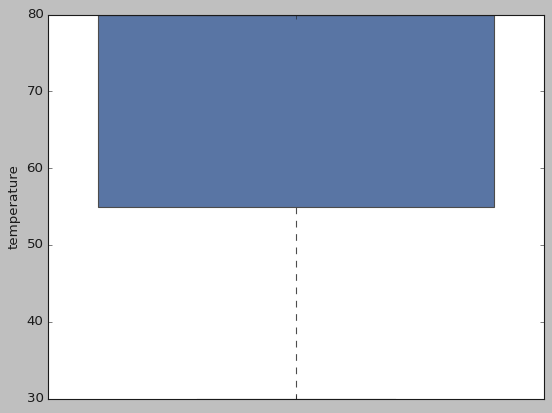

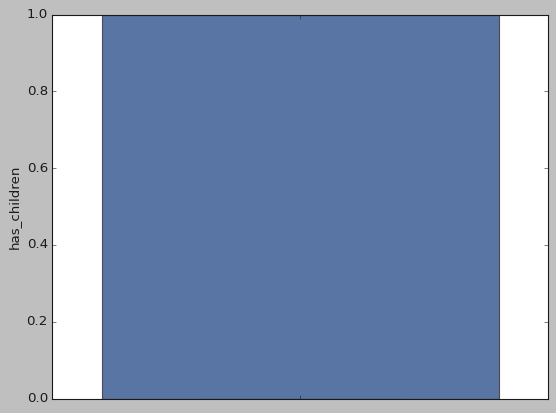

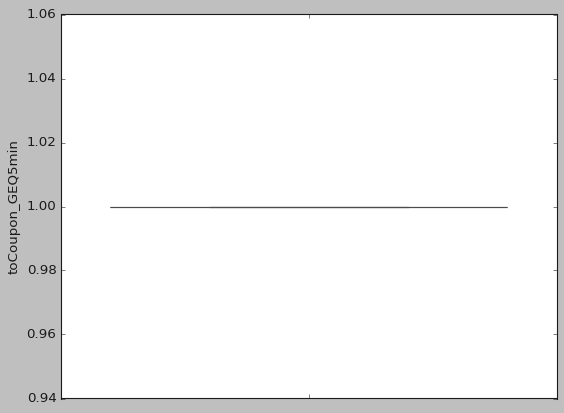

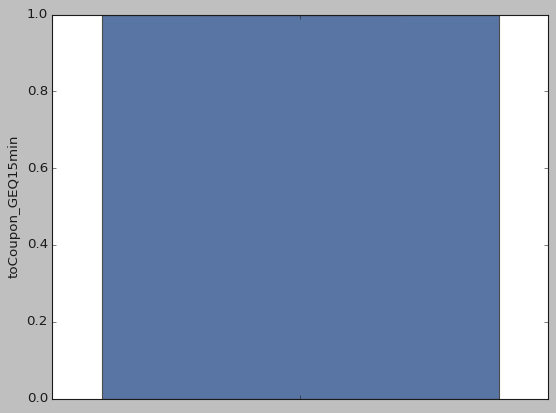

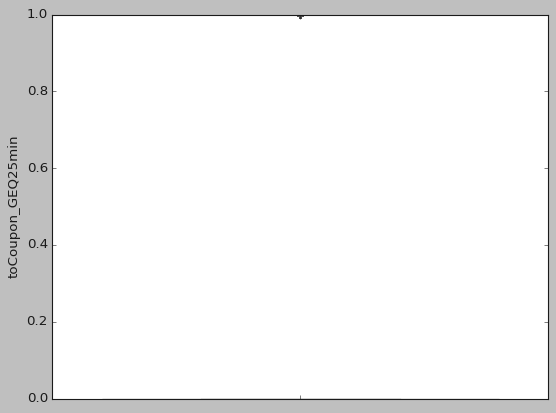

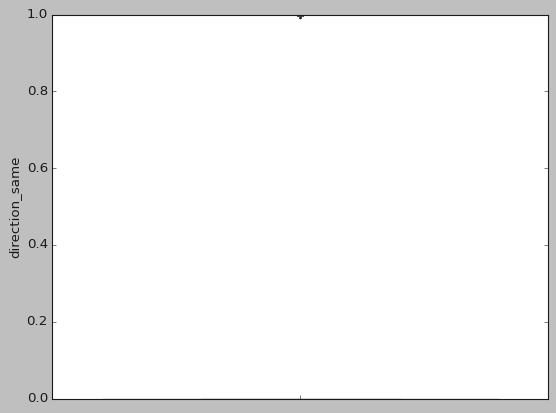

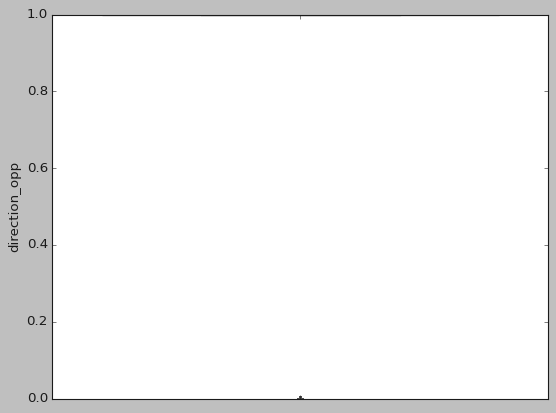

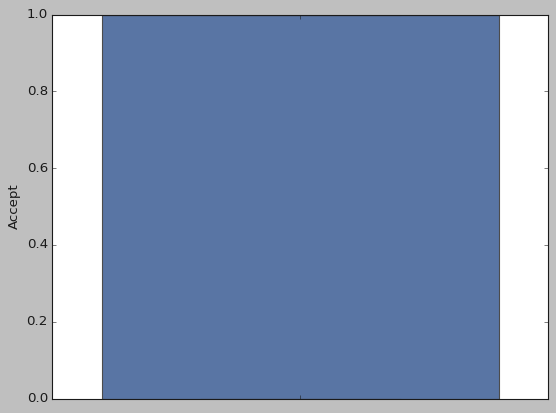

In [343]:
#creating boxplot for all numerical columns checking for outlier
def boxplot(cols):
    sns.boxplot(y=df[cols])
    plt.show()
for i in list(df.select_dtypes(exclude=['object']).columns):
    boxplot(i)

In [344]:
df.drop("toCoupon_GEQ5min",axis=1,inplace =True)

In [345]:
df["toCoupon_GEQ15min"].value_counts()

toCoupon_GEQ15min
1    6779
0    5300
Name: count, dtype: int64

In [346]:
df["toCoupon_GEQ25min"].value_counts()

toCoupon_GEQ25min
0    10637
1     1442
Name: count, dtype: int64

In [347]:
to_coupon=[]
for i in tqdm (range(len(df))):
    if (list(df["toCoupon_GEQ15min"])[i]==0):
        to_coupon.append(0)
    elif (list(df["toCoupon_GEQ15min"])[i]==1)  and (list(df["toCoupon_GEQ25min"])[i]==0):
        to_coupon.append(1)
    else:
        to_coupon.append(2)
df["to_Coupon"]=to_coupon

100%|███████████████████████████████████████████████████████████████████████████| 12079/12079 [00:38<00:00, 311.60it/s]


In [348]:
df.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ15min',
       'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Accept',
       'to_Coupon'],
      dtype='object')

In [349]:
df.head(5)

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept,to_Coupon
22,No Urgent Place,Alone,Sunny,55,Restaurant(<20),24h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,0,0,0,1,1,0
23,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,0,0,0,1,0,0
24,No Urgent Place,Friend(s),Sunny,80,Bar,24h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,0,0,0,1,1,0
25,No Urgent Place,Friend(s),Sunny,80,Carry out & Take away,2h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,1,0,0,1,0,1
26,No Urgent Place,Friend(s),Sunny,80,Coffee House,24h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,0,0,0,1,0,0


In [350]:
df2=df.copy()

In [351]:
df.head(5)

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept,to_Coupon
22,No Urgent Place,Alone,Sunny,55,Restaurant(<20),24h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,0,0,0,1,1,0
23,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,0,0,0,1,0,0
24,No Urgent Place,Friend(s),Sunny,80,Bar,24h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,0,0,0,1,1,0
25,No Urgent Place,Friend(s),Sunny,80,Carry out & Take away,2h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,1,0,0,1,0,1
26,No Urgent Place,Friend(s),Sunny,80,Coffee House,24h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,0,0,0,1,0,0


In [352]:
corr=df2.select_dtypes(include='number').corr()

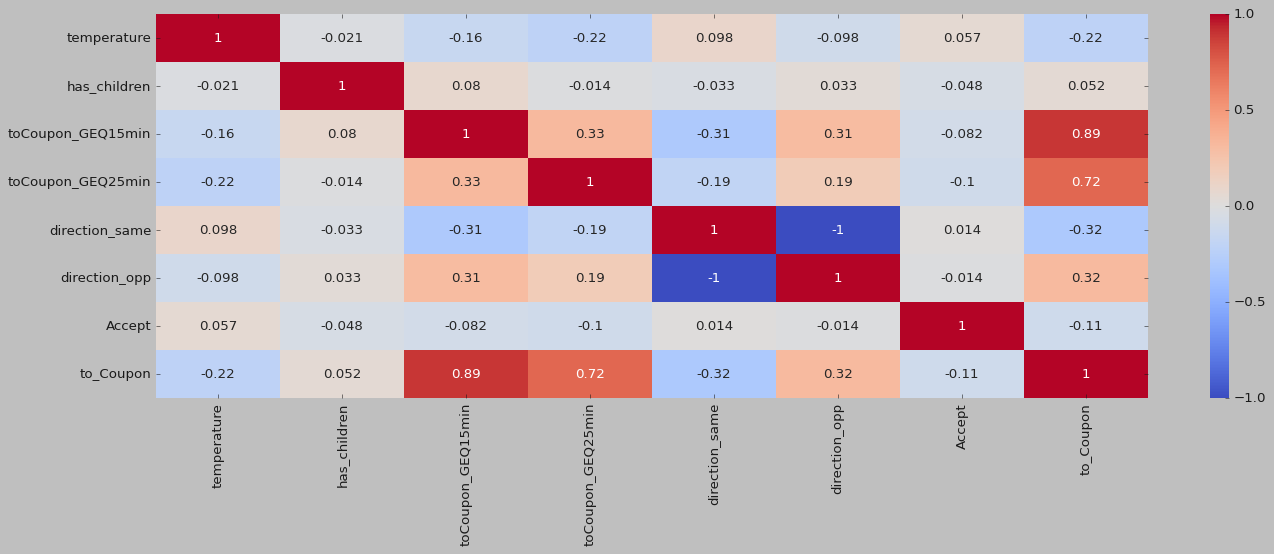

In [353]:
plt.figure(figsize=(20,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [354]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12079 entries, 22 to 12683
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12079 non-null  object
 1   passanger             12079 non-null  object
 2   weather               12079 non-null  object
 3   temperature           12079 non-null  int64 
 4   coupon                12079 non-null  object
 5   expiration            12079 non-null  object
 6   gender                12079 non-null  object
 7   age                   12079 non-null  object
 8   maritalStatus         12079 non-null  object
 9   has_children          12079 non-null  int64 
 10  education             12079 non-null  object
 11  occupation            12079 non-null  object
 12  income                12079 non-null  object
 13  Bar                   12079 non-null  object
 14  CoffeeHouse           12079 non-null  object
 15  CarryAway             12079 non-null  ob

In [355]:
cols=[i for i in df.columns if df2[i].dtype==object]

In [356]:
cols

['destination',
 'passanger',
 'weather',
 'coupon',
 'expiration',
 'gender',
 'age',
 'maritalStatus',
 'education',
 'occupation',
 'income',
 'Bar',
 'CoffeeHouse',
 'CarryAway',
 'RestaurantLessThan20',
 'Restaurant20To50']

In [357]:
df["destination"].value_counts()

destination
No Urgent Place    5970
Home               3085
Work               3024
Name: count, dtype: int64

In [358]:
df2=pd.get_dummies(df2,columns=cols,drop_first=True)

In [359]:
df2.head(10)

,temperature,has_children,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept,to_Coupon,destination_No Urgent Place,destination_Work,...,CarryAway_less1,CarryAway_never,RestaurantLessThan20_4 to 8,RestaurantLessThan20_greater then 8,RestaurantLessThan20_less1,RestaurantLessThan20_never,Restaurant20To50_4 to 8,Restaurant20To50_greater then 8,Restaurant20To50_less1,Restaurant20To50_never
22,55,0,0,0,0,1,1,0,True,False,...,False,False,True,False,False,False,False,False,True,False
23,80,0,0,0,0,1,0,0,True,False,...,False,False,True,False,False,False,False,False,True,False
24,80,0,0,0,0,1,1,0,True,False,...,False,False,True,False,False,False,False,False,True,False
25,80,0,1,0,0,1,0,1,True,False,...,False,False,True,False,False,False,False,False,True,False
26,80,0,0,0,0,1,0,0,True,False,...,False,False,True,False,False,False,False,False,True,False
27,80,0,1,0,0,1,0,1,True,False,...,False,False,True,False,False,False,False,False,True,False
28,80,0,1,0,0,1,0,1,True,False,...,False,False,True,False,False,False,False,False,True,False
29,80,0,1,0,0,1,1,1,True,False,...,False,False,True,False,False,False,False,False,True,False
30,80,0,0,0,0,1,0,0,True,False,...,False,False,True,False,False,False,False,False,True,False
31,80,0,1,0,0,1,1,1,True,False,...,False,False,True,False,False,False,False,False,True,False


In [360]:
df2=df2.astype(int)

In [361]:
df2.head(10)

,temperature,has_children,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept,to_Coupon,destination_No Urgent Place,destination_Work,...,CarryAway_less1,CarryAway_never,RestaurantLessThan20_4 to 8,RestaurantLessThan20_greater then 8,RestaurantLessThan20_less1,RestaurantLessThan20_never,Restaurant20To50_4 to 8,Restaurant20To50_greater then 8,Restaurant20To50_less1,Restaurant20To50_never
22,55,0,0,0,0,1,1,0,1,0,...,0,0,1,0,0,0,0,0,1,0
23,80,0,0,0,0,1,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
24,80,0,0,0,0,1,1,0,1,0,...,0,0,1,0,0,0,0,0,1,0
25,80,0,1,0,0,1,0,1,1,0,...,0,0,1,0,0,0,0,0,1,0
26,80,0,0,0,0,1,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
27,80,0,1,0,0,1,0,1,1,0,...,0,0,1,0,0,0,0,0,1,0
28,80,0,1,0,0,1,0,1,1,0,...,0,0,1,0,0,0,0,0,1,0
29,80,0,1,0,0,1,1,1,1,0,...,0,0,1,0,0,0,0,0,1,0
30,80,0,0,0,0,1,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
31,80,0,1,0,0,1,1,1,1,0,...,0,0,1,0,0,0,0,0,1,0


In [362]:
df3=df.copy()

In [363]:
df3.head(10)

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept,to_Coupon
22,No Urgent Place,Alone,Sunny,55,Restaurant(<20),24h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,0,0,0,1,1,0
23,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,0,0,0,1,0,0
24,No Urgent Place,Friend(s),Sunny,80,Bar,24h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,0,0,0,1,1,0
25,No Urgent Place,Friend(s),Sunny,80,Carry out & Take away,2h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,1,0,0,1,0,1
26,No Urgent Place,Friend(s),Sunny,80,Coffee House,24h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,0,0,0,1,0,0
27,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,1,0,0,1,0,1
28,No Urgent Place,Friend(s),Sunny,80,Coffee House,24h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,1,0,0,1,0,1
29,No Urgent Place,Friend(s),Sunny,80,Restaurant(<20),24h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,1,0,0,1,1,1
30,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,0,0,0,1,0,0
31,No Urgent Place,Friend(s),Sunny,80,Restaurant(<20),2h,Male,21,Single,0,...,less1,4 to 8,4 to 8,less1,1,0,0,1,1,1


In [364]:
cols

['destination',
 'passanger',
 'weather',
 'coupon',
 'expiration',
 'gender',
 'age',
 'maritalStatus',
 'education',
 'occupation',
 'income',
 'Bar',
 'CoffeeHouse',
 'CarryAway',
 'RestaurantLessThan20',
 'Restaurant20To50']

In [365]:
from sklearn.preprocessing import LabelEncoder

In [366]:
le=LabelEncoder()

In [367]:
for col in cols:
    df3[col]=df3[col].astype(str)
    df3[col]=le.fit_transform(df3[col])

In [368]:
df3.head()

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept,to_Coupon
22,1,0,2,55,4,0,1,0,2,0,...,3,1,1,3,0,0,0,1,1,0
23,1,1,2,80,2,1,1,0,2,0,...,3,1,1,3,0,0,0,1,0,0
24,1,1,2,80,0,0,1,0,2,0,...,3,1,1,3,0,0,0,1,1,0
25,1,1,2,80,1,1,1,0,2,0,...,3,1,1,3,1,0,0,1,0,1
26,1,1,2,80,2,0,1,0,2,0,...,3,1,1,3,0,0,0,1,0,0


In [369]:
df3["destination"].value_counts()

destination
1    5970
0    3085
2    3024
Name: count, dtype: int64

In [370]:
df3["education"].value_counts()

education
5    4219
1    4021
2    1808
0    1066
3     877
4      88
Name: count, dtype: int64